# New Section

In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 79.5 MB/s eta 0:00:00


In [ ]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Conv1D, Dense, Flatten, Dropout, BatchNormalization, MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tqdm import tqdm
import torch
import torch.nn.functional as F
from torch.nn import Linear, Dropout as TorchDropout, LayerNorm
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from torch.utils.data import DataLoader, TensorDataset
from scipy.spatial.distance import cdist
from sklearn.neighbors import NearestNeighbors

In [ ]:
# @title
# --- Configuration ---
DATA_FILE = '/content/drive/MyDrive/traffic/ibb_data_fully_enriched.csv'  # Using original dataset without added features
SPLIT_DATE = '2024-04-23 00:00:00'  # Use first ~3 weeks for train, last week for test
TARGET_VARIABLE = 'AVERAGE_SPEED'

# Columns to drop (identifiers, co-targets)
DROP_COLS = [
    '_id', 'DATE_TIME', 'GEOHASH',
    'MINIMUM_SPEED', 'MAXIMUM_SPEED', 'NUMBER_OF_VEHICLES'
]

# For original dataset, we only have: LATITUDE, LONGITUDE
# No categorical features in original dataset
CATEGORICAL_FEATURES = []

# --- Utility Function ---
def robust_mape(y_true, y_pred):
    """
    Calculate Mean Absolute Percentage Error, robust to zero values in y_true.
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    mask = y_true > 0
    if np.sum(mask) == 0:
        print("Warning: No valid non-zero ground truth values for MAPE calculation.")
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


In [ ]:
# @title
# MODEL 1: RANDOM FOREST BASELINE (ORIGINAL DATA)
# ============================================================================
def train_random_forest_baseline(DATA_FILE):
    print("\n" + "="*80)
    print("MODEL 1: RANDOM FOREST BASELINE (ORIGINAL DATA)")
    print("="*80)

    # Load Data
    print(f"Loading data from {DATA_FILE}...")
    try:
        df = pd.read_csv(DATA_FILE)
    except FileNotFoundError:
        print(f"Error: Could not find {DATA_FILE}.")
        return None

    # Ensure DATE_TIME is a datetime object for splitting
    df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], format='mixed')
    df = df.sort_values(by='DATE_TIME')
    print(f"Data loaded. Shape: {df.shape}")

    # Prepare Data for Model
    print("Preparing data for modeling...")

    # Drop identifier columns and co-targets
    df_model = df.drop(columns=DROP_COLS, errors='ignore')

    # Handle potential NaN in target variable by dropping those rows
    df_model = df_model.dropna(subset=[TARGET_VARIABLE])
    print(f"Data shape after dropping unusable rows: {df_model.shape}")

    # Temporal Train-Test Split
    print(f"Performing temporal split at {SPLIT_DATE}...")
    split_timestamp = pd.to_datetime(SPLIT_DATE)

    train_df = df_model[df['DATE_TIME'] < split_timestamp]
    test_df = df_model[df['DATE_TIME'] >= split_timestamp]

    if train_df.empty or test_df.empty:
        print("Error: Train or test split resulted in an empty DataFrame.")
        return None

    print(f"Training data: {train_df.shape[0]} samples")
    print(f"Testing data:  {test_df.shape[0]} samples")

    # Define features (X) and target (y)
    X_train = train_df.drop(columns=[TARGET_VARIABLE])
    y_train = train_df[TARGET_VARIABLE]

    X_test = test_df.drop(columns=[TARGET_VARIABLE])
    y_test = test_df[TARGET_VARIABLE]

    # Automatically determine numerical features
    numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()

    # Create Preprocessing and Model Pipeline
    print("Building model pipeline...")

    # Create transformer for numerical features: impute missing with median
    numerical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ])

    # Create a preprocessor to apply transformers to the correct columns
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, numerical_features)
        ],
        remainder='passthrough'
    )

    # Create the full model pipeline
    rf_model = RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    )

    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', rf_model)
    ])

    # Train the Model
    print("Training Random Forest baseline model...")
    print(f"Training on {len(y_train)} samples. This may take a few minutes...")

    model_pipeline.fit(X_train, y_train)

    print("✓ Model training complete.")

    # Evaluate the Model
    print("\n--- Model Evaluation ---")
    y_pred = model_pipeline.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = robust_mape(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Test Set Metrics (Target: {TARGET_VARIABLE}):")
    print(f"  RMSE: {rmse:.3f} km/h")
    print(f"   MAE: {mae:.3f} km/h")
    print(f"  MAPE: {mape:.3f} %")
    print(f"  R-squared (R2): {r2:.3f}")

    return {'model': 'RF Baseline (Original)', 'r2': r2, 'rmse': rmse, 'mae': mae, 'mape': mape}


In [ ]:
# @title
# MODEL 2: 1D-CNN BASELINE (ORIGINAL DATA)
# ============================================================================
def train_1d_cnn_baseline(DATA_FILE):
    print("\n" + "="*80)
    print("MODEL 2: 1D-CNN BASELINE (ORIGINAL DATA)")
    print("="*80)

    # Configuration
    SEQUENCE_LENGTH = 12
    PREDICTION_HORIZON = 1
    BATCH_SIZE = 64
    EPOCHS = 50
    LEARNING_RATE = 0.001

    # Load data
    print(f"Loading data from {DATA_FILE}...")
    try:
        df = pd.read_csv(DATA_FILE, dtype={'holiday_name': str} if 'holiday_name' in pd.read_csv(DATA_FILE, nrows=0).columns else {})
    except FileNotFoundError:
        print(f"ERROR: Data file not found at {DATA_FILE}")
        return None

    df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], format='mixed')
    df = df.sort_values(['GEOHASH', 'DATE_TIME'])

    # For original data, we only have LATITUDE and LONGITUDE as features
    feature_cols = ['LATITUDE', 'LONGITUDE']

    print(f"Using features: {feature_cols}")

    # Check for missing values
    df = df.dropna(subset=feature_cols + [TARGET_VARIABLE])
    print(f"Data shape after dropping NaN: {df.shape}")

    # Group by GEOHASH
    geohash_groups = df.groupby('GEOHASH')

    # Filter geohashes with enough data
    min_samples = SEQUENCE_LENGTH + PREDICTION_HORIZON + 1
    valid_geohashes = [gh for gh, group in geohash_groups if len(group) >= min_samples]
    print(f"Found {len(valid_geohashes)} geohashes with enough samples")

    df_filtered = df[df['GEOHASH'].isin(valid_geohashes)]

    # Temporal split
    split_date = pd.to_datetime(SPLIT_DATE)
    train_data = df_filtered[df_filtered['DATE_TIME'] < split_date]
    test_data = df_filtered[df_filtered['DATE_TIME'] >= split_date]

    print(f"Train samples: {len(train_data)}, Test samples: {len(test_data)}")

    # Scale features
    feature_scaler = StandardScaler()
    target_scaler = StandardScaler()

    # Fit on train data
    train_features_scaled = feature_scaler.fit_transform(train_data[feature_cols])
    train_target_scaled = target_scaler.fit_transform(train_data[[TARGET_VARIABLE]])

    # Transform test data
    test_features_scaled = feature_scaler.transform(test_data[feature_cols])
    test_target_scaled = target_scaler.transform(test_data[[TARGET_VARIABLE]])

    # Assign back
    train_data_scaled = train_data.copy()
    train_data_scaled[feature_cols] = train_features_scaled
    train_data_scaled[TARGET_VARIABLE] = train_target_scaled

    test_data_scaled = test_data.copy()
    test_data_scaled[feature_cols] = test_features_scaled
    test_data_scaled[TARGET_VARIABLE] = test_target_scaled

    # Create sequences
    def create_sequences_per_geohash(data, seq_len, pred_horizon):
        X_list, y_list = [], []
        for geohash, group in data.groupby('GEOHASH'):
            group = group.sort_values('DATE_TIME')
            features = group[feature_cols].values
            target = group[TARGET_VARIABLE].values

            for i in range(len(group) - seq_len - pred_horizon + 1):
                X_list.append(features[i:i+seq_len])
                y_list.append(target[i+seq_len+pred_horizon-1])

        return np.array(X_list), np.array(y_list)

    print("Creating sequences...")
    X_train, y_train = create_sequences_per_geohash(train_data_scaled, SEQUENCE_LENGTH, PREDICTION_HORIZON)
    X_test, y_test = create_sequences_per_geohash(test_data_scaled, SEQUENCE_LENGTH, PREDICTION_HORIZON)

    print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

    # Build 1D-CNN model
    print("Building 1D-CNN model...")
    model = Sequential([
        Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(SEQUENCE_LENGTH, len(feature_cols))),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        Conv1D(filters=128, kernel_size=3, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                  loss='mse',
                  metrics=['mae'])

    # Callbacks with early stopping
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )

    # Train
    print("Training 1D-CNN model with early stopping...")
    print(f"Early stopping patience: 10 epochs")
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    print(f"\nTraining completed. Total epochs: {len(history.history['loss'])}")

    # Evaluate
    print("\n--- Model Evaluation ---")
    y_pred_scaled = model.predict(X_test)

    # Inverse transform
    y_pred = target_scaler.inverse_transform(y_pred_scaled)
    y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))

    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
    mae = mean_absolute_error(y_test_actual, y_pred)
    mape = robust_mape(y_test_actual, y_pred)
    r2 = r2_score(y_test_actual, y_pred)

    print(f"Test Set Metrics (Target: {TARGET_VARIABLE}):")
    print(f"  RMSE: {rmse:.3f} km/h")
    print(f"   MAE: {mae:.3f} km/h")
    print(f"  MAPE: {mape:.3f} %")
    print(f"  R-squared (R2): {r2:.3f}")

    return {'model': '1D-CNN Baseline (Original)', 'r2': r2, 'rmse': rmse, 'mae': mae, 'mape': mape}




In [ ]:
# @title
# MODEL 3: GCN BASELINE (ORIGINAL DATA)
# ============================================================================
def train_gcn_baseline(DATA_FILE):
    print("\n" + "="*80)
    print("MODEL 3: GCN BASELINE (ORIGINAL DATA)")
    print("="*80)

    # Configuration
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    K_NEIGHBORS = 10
    SEQUENCE_LENGTH = 12
    PREDICTION_HORIZON = 1
    BATCH_SIZE = 32
    EPOCHS = 50
    LEARNING_RATE = 0.001
    PATIENCE = 15

    print(f"Using device: {DEVICE}")

    # Load data
    print(f"Loading data from {DATA_FILE}...")
    try:
        df = pd.read_csv(DATA_FILE)
    except FileNotFoundError:
        print(f"ERROR: Data file not found at {DATA_FILE}")
        return None

    df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], format='mixed')

    # For original data, only LATITUDE and LONGITUDE
    feature_cols = ['LATITUDE', 'LONGITUDE']

    df = df.dropna(subset=feature_cols + [TARGET_VARIABLE])
    print(f"Data shape after dropping NaN: {df.shape}")

    # Build graph
    print("Building spatial graph...")
    unique_geohashes = df['GEOHASH'].unique()
    sensor_df = df.groupby('GEOHASH')[['LATITUDE', 'LONGITUDE']].mean().reset_index()
    sensor_df = sensor_df[sensor_df['GEOHASH'].isin(unique_geohashes)]

    geohash_to_index = {gh: idx for idx, gh in enumerate(sensor_df['GEOHASH'])}

    # Build k-NN graph
    coords = sensor_df[['LATITUDE', 'LONGITUDE']].values
    nbrs = NearestNeighbors(n_neighbors=K_NEIGHBORS+1, algorithm='ball_tree').fit(coords)
    distances, indices = nbrs.kneighbors(coords)

    edge_index = []
    edge_weight = []

    for i in range(len(coords)):
        for j, dist in zip(indices[i][1:], distances[i][1:]):
            edge_index.append([i, j])
            edge_weight.append(1.0 / (dist + 1e-6))

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_weight = torch.tensor(edge_weight, dtype=torch.float)

    num_sensors = len(sensor_df)
    print(f"Graph built: {num_sensors} nodes, {edge_index.shape[1]} edges")

    # Prepare time series data
    print("Preparing time series data...")
    df['sensor_idx'] = df['GEOHASH'].map(geohash_to_index)
    df = df.dropna(subset=['sensor_idx'])
    df['sensor_idx'] = df['sensor_idx'].astype(int)
    df = df.sort_values(['sensor_idx', 'DATE_TIME'])

    # Create 3D tensor [num_sensors, num_timesteps, num_features]
    timestamps = sorted(df['DATE_TIME'].unique())
    num_timesteps = len(timestamps)
    timestamp_to_idx = {ts: idx for idx, ts in enumerate(timestamps)}

    X_all = np.zeros((num_sensors, num_timesteps, len(feature_cols)))
    y_all = np.zeros((num_sensors, num_timesteps))

    for _, row in df.iterrows():
        sensor_idx = int(row['sensor_idx'])
        time_idx = timestamp_to_idx[row['DATE_TIME']]
        X_all[sensor_idx, time_idx, :] = row[feature_cols].values
        y_all[sensor_idx, time_idx] = row[TARGET_VARIABLE]

    # Scale features
    feature_scaler = StandardScaler()
    target_scaler = StandardScaler()

    X_all_reshaped = X_all.reshape(-1, len(feature_cols))
    y_all_reshaped = y_all.reshape(-1, 1)

    X_all_scaled = feature_scaler.fit_transform(X_all_reshaped).reshape(num_sensors, num_timesteps, len(feature_cols))
    y_all_scaled = target_scaler.fit_transform(y_all_reshaped).reshape(num_sensors, num_timesteps)

    # Temporal split
    split_date = pd.to_datetime(SPLIT_DATE)
    split_idx = None
    for idx, ts in enumerate(timestamps):
        if ts >= split_date:
            split_idx = idx
            break

    if split_idx is None or split_idx <= SEQUENCE_LENGTH:
        print("ERROR: Split date is too early or not found.")
        return None

    print(f"Split at timestep {split_idx}/{num_timesteps}")

    # Create sequences
    def create_sequences(X, y, seq_len, pred_horizon, split_idx):
        X_train_list, y_train_list = [], []
        X_test_list, y_test_list = [], []

        for i in range(SEQUENCE_LENGTH, split_idx):
            X_train_list.append(X[:, i-seq_len:i, :])
            y_train_list.append(y[:, i+pred_horizon-1])

        for i in range(split_idx, num_timesteps - pred_horizon + 1):
            if i >= seq_len:
                X_test_list.append(X[:, i-seq_len:i, :])
                y_test_list.append(y[:, i+pred_horizon-1])

        X_train = torch.tensor(np.array(X_train_list), dtype=torch.float32)
        y_train = torch.tensor(np.array(y_train_list), dtype=torch.float32)
        X_test = torch.tensor(np.array(X_test_list), dtype=torch.float32)
        y_test = torch.tensor(np.array(y_test_list), dtype=torch.float32)

        return X_train, y_train, X_test, y_test

    X_train, y_train, X_test, y_test = create_sequences(
        X_all_scaled, y_all_scaled, SEQUENCE_LENGTH, PREDICTION_HORIZON, split_idx
    )

    print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
    print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

    # Build GCN model
    class GCNModel(torch.nn.Module):
        def __init__(self, num_features, hidden_dim=64):
            super(GCNModel, self).__init__()
            self.conv1 = GCNConv(num_features, hidden_dim)
            self.conv2 = GCNConv(hidden_dim, hidden_dim)
            self.fc = Linear(hidden_dim, 1)
            self.dropout = TorchDropout(0.3)

        def forward(self, x, edge_index, edge_weight):
            # x: [batch_size, num_sensors, seq_len, num_features]
            batch_size, num_sensors, seq_len, num_features = x.shape

            # Take last timestep
            x = x[:, :, -1, :]  # [batch_size, num_sensors, num_features]

            outputs = []
            for i in range(batch_size):
                x_i = x[i]  # [num_sensors, num_features]
                x_i = F.relu(self.conv1(x_i, edge_index, edge_weight))
                x_i = self.dropout(x_i)
                x_i = F.relu(self.conv2(x_i, edge_index, edge_weight))
                x_i = self.dropout(x_i)
                x_i = self.fc(x_i)  # [num_sensors, 1]
                outputs.append(x_i)

            return torch.stack(outputs, dim=0)  # [batch_size, num_sensors, 1]

    model = GCNModel(num_features=len(feature_cols)).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = torch.nn.MSELoss()

    edge_index = edge_index.to(DEVICE)
    edge_weight = edge_weight.to(DEVICE)

    # Training
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

    test_dataset = TensorDataset(X_test, y_test)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    print("Training GCN model...")
    best_test_loss = float('inf')
    patience_counter = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()
            out = model(X_batch, edge_index, edge_weight)
            loss = criterion(out.squeeze(-1), y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # Validation
        model.eval()
        test_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                out = model(X_batch, edge_index, edge_weight)
                loss = criterion(out.squeeze(-1), y_batch)
                test_loss += loss.item()

        avg_test_loss = test_loss / len(test_loader)

        if epoch % 5 == 0:
            print(f"Epoch {epoch}/{EPOCHS}, Train Loss: {avg_train_loss:.6f}, Test Loss: {avg_test_loss:.6f}")

        if avg_test_loss < best_test_loss:
            best_test_loss = avg_test_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

    # Evaluation
    print("\n--- Model Evaluation ---")
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            out = model(X_batch, edge_index, edge_weight)
            all_preds.append(out.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0).flatten()
    all_targets = np.concatenate(all_targets, axis=0).flatten()

    # Inverse transform
    all_preds_actual = target_scaler.inverse_transform(all_preds.reshape(-1, 1)).flatten()
    all_targets_actual = target_scaler.inverse_transform(all_targets.reshape(-1, 1)).flatten()

    rmse = np.sqrt(mean_squared_error(all_targets_actual, all_preds_actual))
    mae = mean_absolute_error(all_targets_actual, all_preds_actual)
    mape = robust_mape(all_targets_actual, all_preds_actual)
    r2 = r2_score(all_targets_actual, all_preds_actual)

    print(f"Test Set Metrics (Target: {TARGET_VARIABLE}):")
    print(f"  RMSE: {rmse:.3f} km/h")
    print(f"   MAE: {mae:.3f} km/h")
    print(f"  MAPE: {mape:.3f} %")
    print(f"  R-squared (R2): {r2:.3f}")

    return {'model': 'GCN Baseline (Original)', 'r2': r2, 'rmse': rmse, 'mae': mae, 'mape': mape}


In [ ]:
# @title
def train_stgcn(DATA_FILE):
    print("\n" + "="*80)
    print("MODEL 4: STGCN (ORIGINAL DATA)")
    print("="*80)

    # Configuration
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    K_NEIGHBORS = 10
    GAUSSIAN_SIGMA = 1.0
    SEQUENCE_LENGTH = 12
    PREDICTION_HORIZON = 1
    BATCH_SIZE = 32
    EPOCHS = 50
    LEARNING_RATE = 0.001
    PATIENCE = 15

    print(f"Using device: {DEVICE}")

    # Load data
    print(f"Loading data from {DATA_FILE}...")
    try:
        df = pd.read_csv(DATA_FILE)
    except FileNotFoundError:
        print(f"ERROR: Data file not found at {DATA_FILE}")
        return None

    df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], format='mixed')

    # For original data
    feature_cols = ['LATITUDE', 'LONGITUDE']

    df = df.dropna(subset=feature_cols + [TARGET_VARIABLE])
    print(f"Data shape: {df.shape}")

    # Build graph (same as GCN)
    print("Building spatial graph...")
    unique_geohashes = df['GEOHASH'].unique()
    sensor_df = df.groupby('GEOHASH')[['LATITUDE', 'LONGITUDE']].mean().reset_index()
    sensor_df = sensor_df[sensor_df['GEOHASH'].isin(unique_geohashes)]

    geohash_to_index = {gh: idx for idx, gh in enumerate(sensor_df['GEOHASH'])}

    coords = sensor_df[['LATITUDE', 'LONGITUDE']].values
    nbrs = NearestNeighbors(n_neighbors=K_NEIGHBORS+1, algorithm='ball_tree').fit(coords)
    distances, indices = nbrs.kneighbors(coords)

    # Build adjacency matrix with Gaussian weights
    num_sensors = len(sensor_df)
    adj_matrix = np.zeros((num_sensors, num_sensors))

    for i in range(len(coords)):
        for j, dist in zip(indices[i][1:], distances[i][1:]):
            weight = np.exp(-(dist ** 2) / (2 * GAUSSIAN_SIGMA ** 2))
            adj_matrix[i, j] = weight
            adj_matrix[j, i] = weight

    # Normalize adjacency matrix
    D = np.diag(np.sum(adj_matrix, axis=1) ** -0.5)
    norm_adj = D @ adj_matrix @ D
    norm_adj_sparse = torch.tensor(norm_adj, dtype=torch.float32).to_sparse()

    print(f"Graph built: {num_sensors} nodes")

    # Prepare data (same as GCN)
    df['sensor_idx'] = df['GEOHASH'].map(geohash_to_index)
    df = df.dropna(subset=['sensor_idx'])
    df['sensor_idx'] = df['sensor_idx'].astype(int)
    df = df.sort_values(['sensor_idx', 'DATE_TIME'])

    timestamps = sorted(df['DATE_TIME'].unique())
    num_timesteps = len(timestamps)
    timestamp_to_idx = {ts: idx for idx, ts in enumerate(timestamps)}

    X_all = np.zeros((num_sensors, num_timesteps, len(feature_cols)))
    y_all = np.zeros((num_sensors, num_timesteps))

    for _, row in df.iterrows():
        sensor_idx = int(row['sensor_idx'])
        time_idx = timestamp_to_idx[row['DATE_TIME']]
        X_all[sensor_idx, time_idx, :] = row[feature_cols].values
        y_all[sensor_idx, time_idx] = row[TARGET_VARIABLE]

    # Scale
    feature_scaler = StandardScaler()
    target_scaler = StandardScaler()

    X_all_reshaped = X_all.reshape(-1, len(feature_cols))
    y_all_reshaped = y_all.reshape(-1, 1)

    X_all_scaled = feature_scaler.fit_transform(X_all_reshaped).reshape(num_sensors, num_timesteps, len(feature_cols))
    y_all_scaled = target_scaler.fit_transform(y_all_reshaped).reshape(num_sensors, num_timesteps)

    # Split
    split_date = pd.to_datetime(SPLIT_DATE)
    split_idx = None
    for idx, ts in enumerate(timestamps):
        if ts >= split_date:
            split_idx = idx
            break

    if split_idx is None or split_idx <= SEQUENCE_LENGTH:
        print("ERROR: Invalid split.")
        return None

    print(f"Split at timestep {split_idx}/{num_timesteps}")

    # Create sequences
    def create_sequences(X, y, seq_len, pred_horizon, split_idx):
        X_train_list, y_train_list = [], []
        X_test_list, y_test_list = [], []

        for i in range(seq_len, split_idx):
            X_train_list.append(X[:, i-seq_len:i, :])
            y_train_list.append(y[:, i+pred_horizon-1])

        for i in range(split_idx, num_timesteps - pred_horizon + 1):
            if i >= seq_len:
                X_test_list.append(X[:, i-seq_len:i, :])
                y_test_list.append(y[:, i+pred_horizon-1])

        X_train = torch.tensor(np.array(X_train_list), dtype=torch.float32)
        y_train = torch.tensor(np.array(y_train_list), dtype=torch.float32)
        X_test = torch.tensor(np.array(X_test_list), dtype=torch.float32)
        y_test = torch.tensor(np.array(y_test_list), dtype=torch.float32)

        # Reshape for STGCN: [B, N, T, F]
        # X_train = X_train.permute(0, 2, 1, 3)
        # X_test = X_test.permute(0, 2, 1, 3)

        return X_train, y_train, X_test, y_test

    X_train, y_train, X_test, y_test = create_sequences(
        X_all_scaled, y_all_scaled, SEQUENCE_LENGTH, PREDICTION_HORIZON, split_idx
    )

    print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
    print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

    # Build STGCN (simplified)
    class SimpleSTGCN(torch.nn.Module):
        def __init__(self, num_features, num_nodes):
            super(SimpleSTGCN, self).__init__()
            self.num_nodes = num_nodes

            # Spatial layer
            self.spatial = Linear(num_features, 64)

            # Temporal layer
            self.temporal = torch.nn.Conv1d(64, 128, kernel_size=3, padding=1)

            # Output layer
            self.fc1 = Linear(128, 64)
            self.fc2 = Linear(64, 1)
            self.dropout = TorchDropout(0.3)

        def forward(self, x, norm_adj):
            # x: [B, N, T, F]
            batch_size, num_nodes, seq_len, num_features = x.shape

            # Reshape for spatial processing: process all timesteps together
            # [B, N, T, F] -> [B*T, N, F]
            x = x.permute(0, 2, 1, 3)  # [B, T, N, F]
            x = x.reshape(batch_size * seq_len, num_nodes, num_features)  # [B*T, N, F]
            x = self.spatial(x)  # [B*T, N, 64]

            # Apply graph convolution
            # norm_adj_dense: [N, N], x: [B*T, N, 64]
            # We need: [N, N] @ [N, 64] for each batch
            norm_adj_dense = norm_adj.to_dense()
            x_spatial = []

            # Loop B*T (384) times
            for i in range(batch_size * seq_len):
                x_i = x[i]  # Shape [N, 64] -> [2458, 64]

                # This is correct: [N, N] @ [N, 64] -> [2458, 2458] @ [2458, 64]
                x_i = torch.matmul(norm_adj_dense, x_i)

                x_spatial.append(x_i)

            x = torch.stack(x_spatial, dim=0)  # Shape [B*T, N, 64]
            x = F.relu(x)

            # --- Continue with the rest of your forward pass ---

            # Reshape for temporal
            # x is [384, 2458, 64] -> [B*T, N, C]
            x = x.reshape(batch_size, seq_len, num_nodes, 64) # [B, T, N, C]

            # Permute to [B, N, C, T] for Conv1d
            x = x.permute(0, 2, 3, 1)

            # Reshape to [B*N, C, T]
            x = x.reshape(batch_size * num_nodes, 64, seq_len)
            # --- END FIX ---

            # Temporal CNN
            x = self.temporal(x)  # [B*N, 128, T]
            x = F.relu(x)

            # Take last timestep
            x = x[:, :, -1]  # [B*N, 128]

            # Reshape back to [B, N, 128]
            x = x.reshape(batch_size, num_nodes, 128)

            # Output
            x = F.relu(self.fc1(x))
            x = self.dropout(x)
            x = self.fc2(x)  # [B, N, 1]

            return x

    model = SimpleSTGCN(num_features=len(feature_cols), num_nodes=num_sensors).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = torch.nn.MSELoss()

    norm_adj_sparse = norm_adj_sparse.to(DEVICE)

    # Training
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

    test_dataset = TensorDataset(X_test, y_test)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    print("Training STGCN model...")
    best_test_loss = float('inf')
    patience_counter = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()
            out = model(X_batch, norm_adj_sparse)
            loss = criterion(out.squeeze(-1), y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # Validation
        model.eval()
        test_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                out = model(X_batch, norm_adj_sparse)
                loss = criterion(out.squeeze(-1), y_batch)
                test_loss += loss.item()

        avg_test_loss = test_loss / len(test_loader)

        if epoch % 5 == 0:
            print(f"Epoch {epoch}/{EPOCHS}, Train Loss: {avg_train_loss:.6f}, Test Loss: {avg_test_loss:.6f}")

        if avg_test_loss < best_test_loss:
            best_test_loss = avg_test_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

    # Evaluation
    print("\n--- Model Evaluation ---")
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            out = model(X_batch, norm_adj_sparse)
            all_preds.append(out.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0).flatten()
    all_targets = np.concatenate(all_targets, axis=0).flatten()

    # Inverse transform
    all_preds_actual = target_scaler.inverse_transform(all_preds.reshape(-1, 1)).flatten()
    all_targets_actual = target_scaler.inverse_transform(all_targets.reshape(-1, 1)).flatten()

    rmse = np.sqrt(mean_squared_error(all_targets_actual, all_preds_actual))
    mae = mean_absolute_error(all_targets_actual, all_preds_actual)
    mape = robust_mape(all_targets_actual, all_preds_actual)
    r2 = r2_score(all_targets_actual, all_preds_actual)

    print(f"Test Set Metrics (Target: {TARGET_VARIABLE}):")
    print(f"  RMSE: {rmse:.3f} km/h")
    print(f"   MAE: {mae:.3f} km/h")
    print(f"  MAPE: {mape:.3f} %")
    print(f"  R-squared (R2): {r2:.3f}")

    return {'model': 'STGCN (Original)', 'r2': r2, 'rmse': rmse, 'mae': mae, 'mape': mape}



In [ ]:
print("\n" + "="*80)
print("TESTING MODELS ON ORIGINAL DATASET (NO ADDED FEATURES)")
print("="*80)
print(f"\nDataset: {DATA_FILE}")
print(f"Target: {TARGET_VARIABLE}")
print(f"Train-Test Split: {SPLIT_DATE}")
print("\n")

results = []
result1 = train_random_forest_baseline(DATA_FILE)
if result1:
    results.append(result1)


TESTING MODELS ON ORIGINAL DATASET (NO ADDED FEATURES)

Dataset: /content/traffic_density_202404.csv
Target: AVERAGE_SPEED
Train-Test Split: 2024-04-23 00:00:00



MODEL 1: RANDOM FOREST BASELINE (ORIGINAL DATA)
Loading data from /content/traffic_density_202404.csv...
Data loaded. Shape: (1613448, 9)
Preparing data for modeling...
Data shape after dropping unusable rows: (1613448, 3)
Performing temporal split at 2024-04-23 00:00:00...
Training data: 1234327 samples
Testing data:  379121 samples
Building model pipeline...
Training Random Forest baseline model...
Training on 1234327 samples. This may take a few minutes...
✓ Model training complete.

--- Model Evaluation ---
Test Set Metrics (Target: AVERAGE_SPEED):
  RMSE: 8.558 km/h
   MAE: 5.921 km/h
  MAPE: 13.890 %
  R-squared (R2): 0.891

MODEL 2: 1D-CNN BASELINE (ORIGINAL DATA)
Loading data from /content/traffic_density_202404.csv...
Using features: ['LATITUDE', 'LONGITUDE']
Data shape after dropping NaN: (1613448, 9)
Found 2447 g

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training 1D-CNN model...
Epoch 1/50
15062/15062 ━━━━━━━━━━━━━━━━━━━━ 52s 3ms/step - loss: 0.4623 - mae: 0.5402 - val_loss: 0.8464 - val_mae: 0.7415 - learning_rate: 0.0010
Epoch 2/50
15062/15062 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 0.3538 - mae: 0.4670 - val_loss: 0.8123 - val_mae: 0.7126 - learning_rate: 0.0010
Epoch 3/50
15062/15062 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 0.3363 - mae: 0.4531 - val_loss: 0.9814 - val_mae: 0.8226 - learning_rate: 0.0010
Epoch 4/50
15062/15062 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 0.3244 - mae: 0.4434 - val_loss: 0.9767 - val_mae: 0.8114 - learning_rate: 0.0010
Epoch 5/50
15062/15062 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 0.3145 - mae: 0.4355 - val_loss: 0.9524 - val_mae: 0.7963 - learning_rate: 0.0010
Epoch 6/50
15062/15062 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - loss: 0.3082 - mae: 0.4302 - val_loss: 1.0408 - val_mae: 0.8185 - learning_rate: 0.0010
Epoch 7/50
15062/15062 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - loss: 0.3008 - mae: 0.4241 - val_l

KeyboardInterrupt: 

In [ ]:
result2 = train_1d_cnn_baseline(DATA_FILE)
if result2:
    results.append(result2)


MODEL 2: 1D-CNN BASELINE (ORIGINAL DATA)
Loading data from /content/traffic_density_202404.csv...
Using features: ['LATITUDE', 'LONGITUDE']
Data shape after dropping NaN: (1613448, 9)
Found 2447 geohashes with enough samples
Train samples: 1234276, Test samples: 379106
Creating sequences...
X_train shape: (1204913, 12, 2), y_train shape: (1204913,)
X_test shape: (349783, 12, 2), y_test shape: (349783,)
Building 1D-CNN model...
Training 1D-CNN model with early stopping...
Early stopping patience: 10 epochs


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
15062/15062 ━━━━━━━━━━━━━━━━━━━━ 49s 3ms/step - loss: 0.4599 - mae: 0.5393 - val_loss: 0.9414 - val_mae: 0.8040 - learning_rate: 0.0010
Epoch 2/50
15062/15062 ━━━━━━━━━━━━━━━━━━━━ 43s 3ms/step - loss: 0.3592 - mae: 0.4714 - val_loss: 0.8835 - val_mae: 0.7693 - learning_rate: 0.0010
Epoch 3/50
15062/15062 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - loss: 0.3409 - mae: 0.4566 - val_loss: 1.0150 - val_mae: 0.8194 - learning_rate: 0.0010
Epoch 4/50
15062/15062 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - loss: 0.3246 - mae: 0.4442 - val_loss: 0.9357 - val_mae: 0.8006 - learning_rate: 0.0010
Epoch 5/50
15062/15062 ━━━━━━━━━━━━━━━━━━━━ 43s 3ms/step - loss: 0.3145 - mae: 0.4356 - val_loss: 1.2689 - val_mae: 0.9401 - learning_rate: 0.0010
Epoch 6/50
15062/15062 ━━━━━━━━━━━━━━━━━━━━ 43s 3ms/step - loss: 0.3039 - mae: 0.4273 - val_loss: 0.8853 - val_mae: 0.7820 - learning_rate: 0.0010
Epoch 7/50
15049/15062 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2980 - mae: 0.4224
Epoch 7: ReduceLROnPlateau reduci

In [ ]:
result3 = train_gcn_baseline(DATA_FILE)
if result3:
    results.append(result3)


MODEL 3: GCN BASELINE (ORIGINAL DATA)
Using device: cuda
Loading data from /content/traffic_density_202404.csv...
Data shape after dropping NaN: (1613448, 9)
Building spatial graph...
Graph built: 2458 nodes, 24580 edges
Preparing time series data...
Split at timestep 519/711
X_train: torch.Size([507, 2458, 12, 2]), y_train: torch.Size([507, 2458])
X_test: torch.Size([192, 2458, 12, 2]), y_test: torch.Size([192, 2458])
Training GCN model...
Epoch 5/50, Train Loss: 0.849400, Test Loss: 0.796021
Epoch 10/50, Train Loss: 0.790450, Test Loss: 0.765211
Epoch 15/50, Train Loss: 0.756870, Test Loss: 0.823885
Epoch 20/50, Train Loss: 0.731453, Test Loss: 0.867266
Early stopping at epoch 21

--- Model Evaluation ---
Test Set Metrics (Target: AVERAGE_SPEED):
  RMSE: 27.518 km/h
   MAE: 23.607 km/h
  MAPE: 750581568.000 %
  R-squared (R2): 0.276


In [ ]:
DATA_FILE = "/content/drive/MyDrive/traffic/ibb_data_fully_enriched.csv"
result4 = train_stgcn(DATA_FILE)
if result4:
    results.append(result4)


MODEL 4: STGCN (ORIGINAL DATA)
Using device: cuda
Loading data from /content/drive/MyDrive/traffic/ibb_data_fully_enriched.csv...


/tmp/ipython-input-2572730367.py:22: DtypeWarning: Columns (32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_FILE)


Data shape: (1613448, 95)
Building spatial graph...
Graph built: 2458 nodes
Split at timestep 519/711
X_train: torch.Size([507, 2458, 12, 2]), y_train: torch.Size([507, 2458])
X_test: torch.Size([192, 2458, 12, 2]), y_test: torch.Size([192, 2458])
Training STGCN model...
Epoch 5/50, Train Loss: 0.800149, Test Loss: 1.014463
Epoch 10/50, Train Loss: 0.742991, Test Loss: 0.853911
Epoch 15/50, Train Loss: 0.670449, Test Loss: 0.821638
Epoch 20/50, Train Loss: 0.629568, Test Loss: 0.803121
Epoch 25/50, Train Loss: 0.617643, Test Loss: 0.819612
Epoch 30/50, Train Loss: 0.610553, Test Loss: 0.828914
Epoch 35/50, Train Loss: 0.596316, Test Loss: 0.849326
Early stopping at epoch 39

--- Model Evaluation ---
Test Set Metrics (Target: AVERAGE_SPEED):
  RMSE: 26.758 km/h
   MAE: 21.841 km/h
  MAPE: 829998720.000 %
  R-squared (R2): 0.315


NameError: name 'results' is not defined

In [ ]:
# @title
# Print comparison
print("\n" + "="*80)
print("FINAL RESULTS COMPARISON")
print("="*80)
print("\n--- ENRICHED DATASET (with added features) ---")
print("1. STGCN:            R2: 0.946")
print("2. 1D-CNN Baseline:  R2: 0.939")
print("3. RF Baseline:      R2: 0.927")
print("4. GCN Baseline:     R2: 0.883")

print("\n--- ORIGINAL DATASET (no added features) ---")
for result in sorted(results, key=lambda x: x['r2'], reverse=True):
    print(f"{result['model']:30s} R2: {result['r2']:.3f}, RMSE: {result['rmse']:.3f}, MAE: {result['mae']:.3f}, MAPE: {result['mape']:.3f}")

print("\n" + "="*80)
print("Analysis complete!")
print("="*80)

# New Section

In [ ]:
import pandas as pd

df = pd.read_csv('/content/traffic_density_202404.csv')
df.head(100).to_csv("original.csv", index=False)

In [ ]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# --- Configuration ---
DATA_FILE = '/content/drive/MyDrive/traffic/ibb_data_fully_enriched.csv'
SPLIT_DATE = '2024-04-23 00:00:00' # Use first ~3 weeks for train, last week for test
TARGET_VARIABLE = 'AVERAGE_SPEED'

# Columns to drop (identifiers, co-targets, or text)
DROP_COLS = [
    '_id', 'DATE_TIME', 'GEOHASH',
    'MINIMUM_SPEED', 'MAXIMUM_SPEED', 'NUMBER_OF_VEHICLES',
    'holiday_name', 'road_name', 'time_period'
]

# Features we know are categorical
CATEGORICAL_FEATURES = ['road_type', 'road_category']

# --- Utility Function ---
def robust_mape(y_true, y_pred):
    """
    Calculate Mean Absolute Percentage Error, robust to zero values in y_true.
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    mask = y_true > 0
    if np.sum(mask) == 0:
        print("Warning: No valid non-zero ground truth values for MAPE calculation.")
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# --- 1. Load Data ---
print(f"Loading data from {DATA_FILE}...")
try:
    df = pd.read_csv(DATA_FILE)
except FileNotFoundError:
    print(f"Error: Could not find {DATA_FILE}.")
    print("Please make sure you have run the full enrichment script `wt (7).py` to generate `ibb_data_fully_enriched.csv`.")
    exit()

# Ensure DATE_TIME is a datetime object for splitting
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], format='mixed')
df = df.sort_values(by='DATE_TIME')
print(f"Data loaded. Shape: {df.shape}")

# --- 2. Prepare Data for Model ---
print("Preparing data for modeling...")

# Drop identifier/text columns and co-targets
df_model = df.drop(columns=DROP_COLS, errors='ignore')

# Handle potential NaN in target variable by dropping those rows
df_model = df_model.dropna(subset=[TARGET_VARIABLE])
print(f"Data shape after dropping unusable rows: {df_model.shape}")

# --- 3. Temporal Train-Test Split ---
print(f"Performing temporal split at {SPLIT_DATE}...")
split_timestamp = pd.to_datetime(SPLIT_DATE)

train_df = df_model[df['DATE_TIME'] < split_timestamp]
test_df = df_model[df['DATE_TIME'] >= split_timestamp]

if train_df.empty or test_df.empty:
    print("Error: Train or test split resulted in an empty DataFrame.")
    print(f"Please check your SPLIT_DATE ('{SPLIT_DATE}') and data date range.")
    print(f"Data ranges from {df['DATE_TIME'].min()} to {df['DATE_TIME'].max()}")
    exit()

print(f"Training data: {train_df.shape[0]} samples")
print(f"Testing data:  {test_df.shape[0]} samples")

# Define features (X) and target (y)
X_train = train_df.drop(columns=[TARGET_VARIABLE])
y_train = train_df[TARGET_VARIABLE]

X_test = test_df.drop(columns=[TARGET_VARIABLE])
y_test = test_df[TARGET_VARIABLE]

# Automatically determine numerical features
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()
# Ensure categorical features are not in the numerical list
numerical_features = [col for col in numerical_features if col not in CATEGORICAL_FEATURES]

# --- 4. Create Preprocessing and Model Pipeline ---
print("Building model pipeline...")

# Create transformer for numerical features: impute missing with median
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Create transformer for categorical features: impute missing, then encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Create a preprocessor to apply transformers to the correct columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, CATEGORICAL_FEATURES)
    ],
    remainder='passthrough' # Keep any other columns
)

# Create the full model pipeline
# We use tuned parameters to make it run faster on the large dataset
rf_model = RandomForestRegressor(
    n_estimators=100,     # Number of trees
    max_depth=20,         # Prune trees to prevent overfitting
    min_samples_leaf=10,  # Further prevent overfitting
    random_state=42,
    n_jobs=-1             # Use all available CPU cores
)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', rf_model)
])

# --- 5. Train the Model ---
print("Training Random Forest baseline model...")
print(f"Training on {len(y_train)} samples. This may take a few minutes...")

# Train on the full training set
model_pipeline.fit(X_train, y_train)

print("✓ Model training complete.")

# --- 6. Evaluate the Model ---
print("\n--- Model Evaluation ---")
y_pred = model_pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = robust_mape(y_test, y_pred)
r2 = r2_score(y_test, y_pred) # <-- ADDED R2 SCORE

print(f"Test Set Metrics (Target: {TARGET_VARIABLE}):")
print(f"  RMSE: {rmse:.3f} km/h")
print(f"   MAE: {mae:.3f} km/h")
print(f"  MAPE: {mape:.3f} %")
print(f"  R-squared (R2): {r2:.3f}") # <-- ADDED R2 PRINT

# --- 7. Show Feature Importance ---
print("\n--- Top 20 Feature Importances ---")

try:
    # --- FIX ---
    # Get all feature names *after* preprocessing, in the correct order
    preprocessor = model_pipeline.named_steps['preprocessor']
    all_feature_names = preprocessor.get_feature_names_out()
    # --- END FIX ---

    importances = model_pipeline.named_steps['regressor'].feature_importances_

    # Now the lengths should match
    if len(all_feature_names) != len(importances):
        print(f"Error: Mismatch in feature name count ({len(all_feature_names)}) and importance count ({len(importances)}).")
        print("There might be an issue with how features are being passed to the model.")

    else:
        feature_imp_df = pd.DataFrame(
            {'feature': all_feature_names, 'importance': importances}
        ).sort_values(by='importance', ascending=False)

        # Clean up feature names for better plotting
        feature_imp_df['feature'] = feature_imp_df['feature'].str.replace(r'^(num|cat|remainder)__', '', regex=True)

        print(feature_imp_df.head(20))

        # Plot feature importances
        plt.figure(figsize=(10, 8))
        top_20 = feature_imp_df.head(20)
        plt.barh(top_20['feature'], top_20['importance'])
        plt.xlabel("Feature Importance")
        plt.ylabel("Feature")
        plt.title("Top 20 Feature Importances - Random Forest Baseline")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig('rf_baseline_feature_importance.png')
        print("\n✓ Feature importance plot saved to 'rf_baseline_feature_importance.png'")

except Exception as e:
    print(f"Could not generate feature importance plot: {e}")

print("\nBaseline model script finished.")

Loading data from /content/drive/MyDrive/traffic/ibb_data_fully_enriched.csv...


KeyboardInterrupt: 

In [ ]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Dense, GlobalAveragePooling1D, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tqdm import tqdm

# --- Configuration ---
DATA_FILE = '/content/drive/MyDrive/traffic/ibb_data_fully_enriched.csv'
SPLIT_DATE = '2024-04-23 00:00:00' # Same split as RF for fair comparison
TARGET_VARIABLE = 'AVERAGE_SPEED'
SENSOR_ID_COLUMN = 'GEOHASH'

# How many hours of data to look at to make a prediction
SEQUENCE_LENGTH = 12 # Look at the last 12 hours
# How many hours in the future to predict
PREDICTION_HORIZON = 1 # Predict 1 hour ahead

# --- Utility Functions ---

def robust_mape(y_true, y_pred):
    """ Calculate Mean Absolute Percentage Error, robust to zero values in y_true. """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true > 0
    if np.sum(mask) == 0: return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def create_sequences(data, feature_cols, target_col, sensor_id_col, seq_len, pred_hor):
    """
    Creates sequences of (X, y) pairs for time series forecasting,
    grouped by sensor.
    """
    X_out, y_out = [], []

    # Group by sensor to create sequences only within each sensor's data
    grouped = data.groupby(sensor_id_col)

    print(f"Creating sequences for {len(grouped)} sensors...")

    for sensor_id, sensor_data in tqdm(grouped):
        features = sensor_data[feature_cols].values
        target = sensor_data[target_col].values

        num_samples = len(features)

        for i in range(num_samples - seq_len - pred_hor + 1):
            # Input sequence (X): [i, i+1, ..., i+seq_len-1]
            X_out.append(features[i : i + seq_len])

            # Output value (y): [i+seq_len+pred_hor-1]
            y_out.append(target[i + seq_len + pred_hor - 1])

    return np.array(X_out), np.array(y_out)

# --- 1. Load Data ---
print(f"Loading data from {DATA_FILE}...")
df = pd.read_csv(DATA_FILE)
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], format = 'mixed')
df = df.sort_values(by=[SENSOR_ID_COLUMN, 'DATE_TIME'])
print(f"Data loaded. Shape: {df.shape}")

# --- 2. Feature Selection & Preprocessing ---
print("Preprocessing data...")

# Select features. We include the target, time, weather, and static road features.
# Neural nets can learn from cyclical features well.
FEATURE_COLS = [
    'AVERAGE_SPEED', # Include target as a feature (autoregression)
    'hour_sin', 'hour_cos',
    'day_of_week_sin', 'day_of_week_cos',
    'is_weekend', 'is_rush_hour', 'is_holiday',
    'temperature', 'humidity', 'precipitation', 'is_raining',
    'speed_limit', 'num_lanes', 'is_highway'
]
CATEGORICAL_FEATURES = ['road_type', 'road_category'] # RF features, let's skip for CNN baseline
TARGET_COL_INDEX = 0 # AVERAGE_SPEED is the 0th index in FEATURE_COLS

# Simple imputation (forward fill for time series, then 0 for start)
df[FEATURE_COLS] = df.groupby(SENSOR_ID_COLUMN)[FEATURE_COLS].ffill().fillna(0)

# --- 3. Temporal Train-Test Split ---
print(f"Performing temporal split at {SPLIT_DATE}...")
split_timestamp = pd.to_datetime(SPLIT_DATE)
train_df = df[df['DATE_TIME'] < split_timestamp]
test_df = df[df['DATE_TIME'] >= split_timestamp]

if train_df.empty or test_df.empty:
    print("Error: Train or test split resulted in an empty DataFrame.")
    exit()

# --- 4. Scaling (CRITICAL for Neural Networks) ---
# Fit scalers ONLY on training data
print("Scaling data...")
target_scaler = StandardScaler()
feature_scaler = StandardScaler()

# Fit and transform training data
train_df[TARGET_VARIABLE] = target_scaler.fit_transform(train_df[[TARGET_VARIABLE]])
train_df[FEATURE_COLS] = feature_scaler.fit_transform(train_df[FEATURE_COLS])

# Only transform test data (use training data's mean/std)
test_df[TARGET_VARIABLE] = target_scaler.transform(test_df[[TARGET_VARIABLE]])
test_df[FEATURE_COLS] = feature_scaler.transform(test_df[FEATURE_COLS])

# --- 5. Create Sequences ---
print("Creating training sequences...")
X_train, y_train = create_sequences(
    train_df, FEATURE_COLS, TARGET_VARIABLE, SENSOR_ID_COLUMN,
    SEQUENCE_LENGTH, PREDICTION_HORIZON
)

print("Creating testing sequences...")
X_test, y_test = create_sequences(
    test_df, FEATURE_COLS, TARGET_VARIABLE, SENSOR_ID_COLUMN,
    SEQUENCE_LENGTH, PREDICTION_HORIZON
)

if X_train.shape[0] == 0 or X_test.shape[0] == 0:
    print("Error: No sequences created. Check SEQUENCE_LENGTH and data.")
    exit()

print(f"Training sequences: X={X_train.shape}, y={y_train.shape}")
print(f"Testing sequences:  X={X_test.shape}, y={y_test.shape}")
num_features = X_train.shape[2]

# --- 6. Build 1D-CNN Model ---
print("Building 1D-CNN model...")

def build_cnn_model(seq_len, num_features):
    inputs = Input(shape=(seq_len, num_features))

    # First convolutional block
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = MaxPooling1D(pool_size=2)(x)

    # Second convolutional block
    x = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(x)

    # Global pooling to flatten
    x = GlobalAveragePooling1D()(x)

    # Dense layers for prediction
    x = Dense(100, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(1, activation='linear')(x) # Linear activation for regression

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

model = build_cnn_model(SEQUENCE_LENGTH, num_features)
model.summary()

# --- 7. Train the Model ---
print("Training model...")

# Stop training if validation loss doesn't improve
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50, # Set a high number, early stopping will find the best
    batch_size=256,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    shuffle=True
)

print("✓ Model training complete.")

# --- 8. Evaluate the Model ---
print("\n--- Model Evaluation ---")
# Predict on test data (predictions are scaled)
y_pred_scaled = model.predict(X_test)

# Inverse transform to get actual km/h
# We must reshape y_test to 2D for the scaler
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_actual = target_scaler.inverse_transform(y_pred_scaled)

# Calculate metrics on the *actual* (unscaled) values
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mape = robust_mape(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)

print(f"Test Set Metrics (Target: {TARGET_VARIABLE}):")
print(f"  RMSE: {rmse:.3f} km/h")
print(f"   MAE: {mae:.3f} km/h")
print(f"  MAPE: {mape:.3f} %")
print(f"  R-squared (R2): {r2:.3f}")

print("\n--- Comparison to RF Baseline ---")
print("RF Baseline (approx): RMSE: 7.0, MAE: 4.6, MAPE: 9.9")
print("CNN Baseline (actual): RMSE: {:.1f}, MAE: {:.1f}, MAPE: {:.1f}".format(rmse, mae, mape))

# --- 9. Plot History ---
print("Saving training history plot...")
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training History (Loss)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.savefig('cnn_baseline_training_history.png')
print("✓ Plot saved to 'cnn_baseline_training_history.png'")

print("\nCNN baseline script finished.")

Loading data from /content/drive/MyDrive/traffic/ibb_data_fully_enriched.csv...
Data loaded. Shape: (1613448, 95)
Preprocessing data...
Performing temporal split at 2024-04-23 00:00:00...
Scaling data...
Creating training sequences...
Creating sequences for 2458 sensors...


100%|██████████| 2458/2458 [00:03<00:00, 767.86it/s]


Creating testing sequences...
Creating sequences for 2456 sensors...


100%|██████████| 2456/2456 [00:02<00:00, 1062.29it/s]


Training sequences: X=(1204913, 12, 15), y=(1204913,)
Testing sequences:  X=(349783, 12, 15), y=(349783,)
Building 1D-CNN model...


...

 Total params: 40,649 (158.79 KB)

 Trainable params: 40,649 (158.79 KB)

 Non-trainable params: 0 (0.00 B)

Training model...
Epoch 1/50
4707/4707 ━━━━━━━━━━━━━━━━━━━━ 31s 5ms/step - loss: 0.0865 - mae: 0.2024 - val_loss: 0.0641 - val_mae: 0.1655
Epoch 2/50
4707/4707 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 0.0597 - mae: 0.1687 - val_loss: 0.0628 - val_mae: 0.1646
Epoch 3/50
4707/4707 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 0.0580 - mae: 0.1658 - val_loss: 0.0637 - val_mae: 0.1680
Epoch 4/50
4707/4707 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 0.0571 - mae: 0.1644 - val_loss: 0.0607 - val_mae: 0.1596
Epoch 5/50
4707/4707 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.0562 - mae: 0.1632 - val_loss: 0.0609 - val_mae: 0.1611
Epoch 6/50
3055/4707 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0555 - mae: 0.1623

KeyboardInterrupt: 

In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 72.3 MB/s eta 0:00:00


In [ ]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics.pairwise import haversine_distances
import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from scipy.sparse import coo_matrix
from tqdm import tqdm

# --- Configuration ---
DATA_FILE = '/content/drive/MyDrive/traffic/ibb_data_fully_enriched.csv'
TARGET_VARIABLE = 'AVERAGE_SPEED'
SPLIT_DATE = '2024-04-23 00:00:00' # Same split as others

# Graph construction parameters
DISTANCE_THRESHOLD_KM = 1.0 # Connect sensors within 1km
GAUSSIAN_SIGMA = 0.5 # For edge weight calculation

# Features to use. We separate dynamic (time-varying) and static (constant per-sensor)
# Note: We CANNOT use AVERAGE_SPEED as a feature, as it's the target!
DYNAMIC_FEATURE_COLS = [
    'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos',
    'is_weekend', 'is_rush_hour', 'is_holiday', 'is_ramadan_month',
    'temperature', 'humidity', 'precipitation', 'wind_speed', 'is_raining'
]
STATIC_FEATURE_COLS = [
    'LATITUDE', 'LONGITUDE', 'speed_limit', 'num_lanes', 'is_highway',
    'dist_to_city_center_taksim', 'dist_to_bosphorus_bridge', 'dist_to_istanbul_airport'
]
ALL_FEATURE_COLS = DYNAMIC_FEATURE_COLS + STATIC_FEATURE_COLS

# Model parameters
LEARNING_RATE = 0.001 # <-- Lower learning rate for finer tuning
EPOCHS = 100 # <-- Increase max epochs
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# --- Early Stopping Parameters ---
PATIENCE = 10 # <-- Increase patience to 10
BEST_MODEL_PATH = 'best_gcn_model.pth'

# --- Utility Functions ---
def robust_mape(y_true, y_pred):
    """ Calculate Mean Absolute Percentage Error, robust to zero values in y_true. """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true > 0
    if np.sum(mask) == 0: return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# --- Part 1: Build the Graph (Adjacency Matrix) ---
print("Part 1: Building Sensor Graph...")

@torch.no_grad()
def build_graph(df, dist_thresh_km, sigma):
    # 1. Get unique sensors and their locations
    sensor_df = df[['GEOHASH', 'LATITUDE', 'LONGITUDE']].drop_duplicates()
    sensor_df = sensor_df.sort_values(by='GEOHASH').reset_index(drop=True)

    num_sensors = len(sensor_df)

    # 2. Create mapping: GEOHASH -> node_index
    geohash_to_index = {geohash: idx for idx, geohash in enumerate(sensor_df['GEOHASH'])}

    # 3. Calculate pairwise haversine distance (in km)
    locations_rad = np.radians(sensor_df[['LATITUDE', 'LONGITUDE']].values)
    dist_matrix_km = haversine_distances(locations_rad) * 6371 # Earth radius in km

    # 4. Create adjacency matrix using Gaussian kernel (from your research guide)
    adj_matrix = np.exp(-(dist_matrix_km ** 2) / (sigma ** 2))

    # 5. Apply distance threshold
    adj_matrix[dist_matrix_km > dist_thresh_km] = 0

    # 6. Add self-loops
    np.fill_diagonal(adj_matrix, 1)

    # 7. Convert to sparse edge_index format for PyG
    sparse_adj = coo_matrix(adj_matrix)
    edge_index = torch.tensor(np.vstack((sparse_adj.row, sparse_adj.col)), dtype=torch.long)
    edge_weight = torch.tensor(sparse_adj.data, dtype=torch.float)

    print(f"Graph built: {num_sensors} nodes, {edge_index.shape[1]} edges")
    return edge_index, edge_weight, sensor_df, geohash_to_index

# --- Part 2: Build Pivoted Tensors (X, y) ---
print("Part 2: Pivoting Data into Tensors...")

def build_tensors(df, sensor_df, geohash_to_index):
    # 1. Get all timestamps
    # Original line:
    # all_times = pd.to_datetime(df['DATE_TIME'].unique()).sort_values()

    # --- FIX START ---
    # np.sort works on the numpy array returned by .unique()
    all_times_sorted = np.sort(df['DATE_TIME'].unique())
    # Convert the sorted numpy array to a pandas DatetimeIndex
    all_times = pd.to_datetime(all_times_sorted)
    # --- FIX END ---

    time_to_index = {time: idx for idx, time in enumerate(all_times)}

    num_sensors = len(sensor_df)
    num_timesteps = len(all_times)
    num_dyn_features = len(DYNAMIC_FEATURE_COLS)
    num_stat_features = len(STATIC_FEATURE_COLS)

    # 2. Initialize Tensors with NaN
    X_dynamic = torch.full((num_sensors, num_timesteps, num_dyn_features), np.nan, dtype=torch.float)
    X_static = torch.full((num_sensors, num_stat_features), np.nan, dtype=torch.float)
    y_tensor = torch.full((num_sensors, num_timesteps, 1), np.nan, dtype=torch.float)

    # 3. Populate static features (once per sensor)
    static_data = df.drop_duplicates(subset='GEOHASH')
    static_data = static_data.set_index('GEOHASH').loc[sensor_df['GEOHASH']]
    X_static = torch.tensor(static_data[STATIC_FEATURE_COLS].values, dtype=torch.float)

    # 4. Populate dynamic tensors (this is the slow part)
    print(f"Populating tensors for {len(df)} records...")
    for row in tqdm(df.itertuples(), total=len(df)):
        node_idx = geohash_to_index.get(row.GEOHASH)
        time_idx = time_to_index.get(row.DATE_TIME)

        if node_idx is not None and time_idx is not None:
            X_dynamic[node_idx, time_idx, :] = torch.tensor(
                [getattr(row, col) for col in DYNAMIC_FEATURE_COLS], dtype=torch.float
            )
            y_tensor[node_idx, time_idx, 0] = getattr(row, TARGET_VARIABLE)

    # 5. Interpolate missing values (e.g., sensor offline for 1 hour)
    print("Interpolating missing values (per-sensor, over time)...")
    # Convert to pandas for easy interpolation
    X_dynamic_pd = pd.DataFrame(X_dynamic.reshape(-1, num_dyn_features), columns=DYNAMIC_FEATURE_COLS)
    y_tensor_pd = pd.DataFrame(y_tensor.reshape(-1, 1), columns=[TARGET_VARIABLE])

    # Interpolate (linear, along time axis) and fill remaining NaNs
    X_dynamic_pd = X_dynamic_pd.interpolate(method='linear', limit_direction='both').fillna(0)
    y_tensor_pd = y_tensor_pd.interpolate(method='linear', limit_direction='both').fillna(0)

    X_dynamic = torch.tensor(X_dynamic_pd.values, dtype=torch.float).reshape(num_sensors, num_timesteps, num_dyn_features)
    y_tensor = torch.tensor(y_tensor_pd.values, dtype=torch.float).reshape(num_sensors, num_timesteps, 1)

    # 6. Create split
    split_time_idx = time_to_index[pd.to_datetime(SPLIT_DATE)]

    # 7. Scale data
    print("Scaling data...")
    scalers = {'y': StandardScaler(), 'dyn': StandardScaler(), 'stat': StandardScaler()}

    # Fit on training data
    scalers['y'].fit(y_tensor[:, :split_time_idx, :].reshape(-1, 1))
    scalers['dyn'].fit(X_dynamic[:, :split_time_idx, :].reshape(-1, num_dyn_features))
    scalers['stat'].fit(X_static) # Static features are fit on all data

    # Transform all data
    y_tensor = torch.tensor(scalers['y'].transform(y_tensor.reshape(-1, 1)), dtype=torch.float).reshape(num_sensors, num_timesteps, 1)
    X_dynamic = torch.tensor(scalers['dyn'].transform(X_dynamic.reshape(-1, num_dyn_features)), dtype=torch.float).reshape(num_sensors, num_timesteps, num_dyn_features)
    X_static = torch.tensor(scalers['stat'].transform(X_static), dtype=torch.float)

    print("✓ Tensors built and scaled.")
    return X_dynamic, X_static, y_tensor, all_times, split_time_idx, scalers

# --- Part 3: Define GCN Model ---
print("Part 3: Defining GCN Model...")

class GCN(torch.nn.Module):
    def __init__(self, num_features, hidden_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels * 2) # <-- Make wider
        self.conv3 = GCNConv(hidden_channels * 2, hidden_channels * 2) # Keep the same width as the previous layer
        self.conv4 = GCNConv(hidden_channels * 2, hidden_channels) # Add a 4th layer, reducing to original hidden_channels
        self.out = Linear(hidden_channels, 1) # Predict 1 value (speed)

    def forward(self, x, edge_index, edge_weight):
        # x: [num_nodes, num_features]
        # edge_index: [2, num_edges]
        x = self.conv1(x, edge_index, edge_weight)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)

        x = self.conv2(x, edge_index, edge_weight)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)

        x = self.conv3(x, edge_index, edge_weight) # <-- Pass through 3rd layer
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)

        x = self.conv4(x, edge_index, edge_weight) # <-- Pass through 4th layer
        x = F.relu(x)

        x = self.out(x)
        return x

# --- Part 4: Main Execution ---
def main():
    # 1. Load data
    df = pd.read_csv(DATA_FILE, dtype={'holiday_name': str})
    df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], format='mixed')
    df = df.dropna(subset=ALL_FEATURE_COLS + [TARGET_VARIABLE]) # Drop rows with NaN

    # 2. Build graph
    edge_index, edge_weight, sensor_df, geohash_to_index = build_graph(
        df, DISTANCE_THRESHOLD_KM, GAUSSIAN_SIGMA
    )

    # 3. Build tensors
    X_dyn, X_stat, y, all_times, split_idx, scalers = build_tensors(
        df, sensor_df, geohash_to_index
    )

    num_sensors, num_timesteps, num_dyn_features = X_dyn.shape
    num_stat_features = X_stat.shape[1]
    num_total_features = num_dyn_features + num_stat_features

    # --- Create Validation Split ---
    # Use 10% of the training data for validation
    val_split_idx = int(split_idx * 0.9)
    train_timesteps = range(val_split_idx)
    val_timesteps = range(val_split_idx, split_idx)

    print(f"\nTraining timesteps: 0 to {val_split_idx - 1}")
    print(f"Validation timesteps: {val_split_idx} to {split_idx - 1}")
    print(f"Test timesteps: {split_idx} to {num_timesteps - 1}")

    # 4. Prepare for training
    model = GCN(num_features=num_total_features, hidden_channels=128).to(DEVICE) # <-- Increase hidden channels
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = torch.nn.MSELoss()

    edge_index = edge_index.to(DEVICE)
    edge_weight = edge_weight.to(DEVICE)
    X_stat_expanded = X_stat.unsqueeze(1).expand(-1, num_timesteps, -1).to(DEVICE) # [N, T, F_stat]
    X_dyn = X_dyn.to(DEVICE)
    y = y.to(DEVICE)

    # --- Early Stopping Logic ---
    best_val_loss = float('inf')
    epochs_no_improve = 0
    # ---

    print("\nPart 4: Training GCN (Pure Spatial) Model...")

    for epoch in range(1, EPOCHS + 1):
        # --- Training Phase ---
        model.train()
        train_loss = 0

        # Iterate over time (train split)
        for t in tqdm(range(len(train_timesteps)), desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False):
            optimizer.zero_grad()

            # Get data for this snapshot
            x_dyn_t = X_dyn[:, t, :]
            x_stat_t = X_stat_expanded[:, t, :]
            x_t = torch.cat([x_dyn_t, x_stat_t], dim=1)
            y_t = y[:, t, :] # [N, 1]

            # Forward pass
            out = model(x_t, edge_index, edge_weight) # [N, 1]

            loss = criterion(out, y_t)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_timesteps)

        # --- Validation Phase ---
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for t in tqdm(val_timesteps, desc=f"Epoch {epoch}/{EPOCHS} [Val]", leave=False):
                x_dyn_t = X_dyn[:, t, :]
                x_stat_t = X_stat_expanded[:, t, :]
                x_t = torch.cat([x_dyn_t, x_stat_t], dim=1)
                y_t = y[:, t, :]

                out = model(x_t, edge_index, edge_weight)
                loss = criterion(out, y_t)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_timesteps)

        print(f"Epoch {epoch:02d}, Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}")

        # --- Early Stopping Check ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            # Save the best model
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            print(f"  Val loss improved. Saving model to {BEST_MODEL_PATH}")
        else:
            epochs_no_improve += 1
            print(f"  Val loss did not improve. Patience: {epochs_no_improve}/{PATIENCE}")

        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping triggered after {epoch} epochs.")
            break

    # --- Part 5: Evaluation ---
    print("\nPart 5: Evaluating Model...")

    # --- Load the best model weights for evaluation ---
    print(f"Loading best model from {BEST_MODEL_PATH}...")
    model.load_state_dict(torch.load(BEST_MODEL_PATH))

    model.eval()
    all_y_pred_actual = []
    all_y_test_actual = []

    with torch.no_grad():
        for t in tqdm(range(split_idx, num_timesteps), desc="Evaluating"):
            # Get data for this snapshot
            x_dyn_t = X_dyn[:, t, :]
            x_stat_t = X_stat_expanded[:, t, :]
            x_t = torch.cat([x_dyn_t, x_stat_t], dim=1)
            y_t = y[:, t, :]

            # Get prediction (scaled)
            y_pred_scaled = model(x_t, edge_index, edge_weight)

            # Inverse scale
            y_pred_actual = scalers['y'].inverse_transform(y_pred_scaled.cpu().numpy())
            y_test_actual = scalers['y'].inverse_transform(y_t.cpu().numpy())

            all_y_pred_actual.append(y_pred_actual)
            all_y_test_actual.append(y_test_actual)

    # Flatten lists for final metrics
    all_y_pred_actual = np.concatenate(all_y_pred_actual).flatten()
    all_y_test_actual = np.concatenate(all_y_test_actual).flatten()

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(all_y_test_actual, all_y_pred_actual))
    mae = mean_absolute_error(all_y_test_actual, all_y_pred_actual)
    mape = robust_mape(all_y_test_actual, all_y_pred_actual)
    r2 = r2_score(all_y_test_actual, all_y_pred_actual)

    print("\n--- GCN Model Evaluation ---")
    print(f"Test Set Metrics (Target: {TARGET_VARIABLE}):")
    print(f"  RMSE: {rmse:.3f} km/h")
    print(f"   MAE: {mae:.3f} km/h")
    print(f"  MAPE: {mape:.3f} %")
    print(f"  R-squared (R2): {r2:.3f}")

    print("\n--- Baseline Comparison Summary ---")
    print(f"RF Baseline (Spatial-Features): R2: 0.927")
    print(f"1D-CNN Baseline (Temporal):     R2: 0.939")
    print(f"GCN Baseline (Spatial-Graph):   R2: {r2:.3f}")

if __name__ == "__main__":
    main()

Using device: cuda
Part 1: Building Sensor Graph (k-NN, Manual GCN)...
Part 2: Pivoting Data into Tensors...
Part 3: Defining GCN (v2, ResNet) Model...
Graph built: 2458 nodes. Normalized adjacency matrix created.
Populating tensors for 1613448 records...


100%|██████████| 1613448/1613448 [00:56<00:00, 28369.12it/s]


Interpolating missing values (per-sensor, over time)...
Scaling data...
✓ Tensors built and scaled.

Training timesteps: 0 to 466
Validation timesteps: 467 to 518
Test timesteps: 519 to 710

Part 4: Training GCN (v2, ResNet) Model...


Epoch 01, Train Loss: 0.647043, Val Loss: 0.501694, LR: 0.001000
  Val loss improved. Saving model to best_gcn_model_v2_knn_resnet.pth


Epoch 02, Train Loss: 0.443687, Val Loss: 0.478079, LR: 0.001000
  Val loss improved. Saving model to best_gcn_model_v2_knn_resnet.pth


...

Epoch 212, Train Loss: 0.124423, Val Loss: 0.096352, LR: 0.000004
  Val loss did not improve. Patience: 8/10


Epoch 213, Train Loss: 0.124484, Val Loss: 0.096157, LR: 0.000004
  Val loss did not improve. Patience: 9/10


Epoch 214, Train Loss: 0.124226, Val Loss: 0.096168, LR: 0.000004
  Val loss did not improve. Patience: 10/10

Early stopping triggered after 214 epochs.

Part 5: Evaluating Model...
Loading best model from best_gcn_model_v2_knn_resnet.pth...


Evaluating: 100%|██████████| 192/192 [00:00<00:00, 421.53it/s]



--- GCN Model (v2, kNN + ResNet) Evaluation ---
Test Set Metrics (Target: AVERAGE_SPEED):
  RMSE: 9.496 km/h
   MAE: 6.819 km/h
  MAPE: 15.722 %
  R-squared (R2): 0.868

--- Baseline Comparison Summary ---
RF Baseline (Spatial-Features): R2: 0.927
1D-CNN Baseline (Temporal):     R2: 0.939
GCN Baseline (v1 - Original):   R2: 0.883
GCN Baseline (v2 - kNN+ResNet): R2: 0.868 <-- THIS MODEL
STGCN (v3 - kNN + ResNet):      R2: 0.946


In [ ]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neighbors import kneighbors_graph # <-- Import for k-NN
import torch
import torch.nn.functional as F
from torch.nn import Linear, Conv1d, Dropout, LayerNorm # <-- Base torch modules
#
# No torch_geometric imports
#
from torch.utils.data import DataLoader, TensorDataset
import torch.optim.lr_scheduler # <-- Import scheduler
from scipy.sparse import coo_matrix
from tqdm import tqdm
import sys # for file error handling

# --- Configuration ---
# !!! SET THIS TO YOUR DATA FILE PATH !!!
DATA_FILE = '/content/drive/MyDrive/traffic/ibb_data_fully_enriched.csv'
TARGET_VARIABLE = 'AVERAGE_SPEED'
SPLIT_DATE = '2024-04-23 00:00:00'

# Graph construction
K_NEIGHBORS = 8 # <-- Use k-NN
GAUSSIAN_SIGMA = 1.0 # <-- Sigma for k-NN distance weighting

# Model & Sequence parameters
SEQUENCE_LENGTH = 12
PREDICTION_HORIZON = 1
BATCH_SIZE = 64

# Features
DYNAMIC_FEATURE_COLS = [
    'AVERAGE_SPEED', 'hour_sin', 'hour_cos', 'day_of_week_sin',
    'day_of_week_cos', 'is_weekend', 'is_rush_hour', 'is_holiday',
    'temperature', 'humidity', 'precipitation', 'is_raining'
]
STATIC_FEATURE_COLS = [
    'LATITUDE', 'LONGITUDE', 'speed_limit', 'num_lanes', 'is_highway',
    'dist_to_city_center_taksim', 'dist_to_bosphorus_bridge'
]
ALL_MODEL_FEATURES = DYNAMIC_FEATURE_COLS + STATIC_FEATURE_COLS

# Training parameters
LEARNING_RATE = 0.001
EPOCHS = 100
PATIENCE = 10
SCHEDULER_PATIENCE = 3
SCHEDULER_FACTOR = 0.5
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BEST_MODEL_PATH = 'best_stgcn_model_v3_no_geom.pth'
print(f"Using device: {DEVICE}")

# --- Utility Functions ---
def robust_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true > 0
    if np.sum(mask) == 0: return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# --- Part 1: Build Graph (MODIFIED for k-NN and Manual GCN) ---
@torch.no_grad()
def build_graph(df, k_neighbors, sigma):
    print("Part 1: Building Sensor Graph (k-NN, Manual GCN)...")
    sensor_df = df[['GEOHASH', 'LATITUDE', 'LONGITUDE']].drop_duplicates()
    sensor_df = sensor_df.sort_values(by='GEOHASH').reset_index(drop=True)
    num_sensors = len(sensor_df)
    geohash_to_index = {geohash: idx for idx, geohash in enumerate(sensor_df['GEOHASH'])}

    locations_rad = np.radians(sensor_df[['LATITUDE', 'LONGITUDE']].values)

    # 1. k-NN graph
    adj_matrix_sparse = kneighbors_graph(
        locations_rad,
        n_neighbors=k_neighbors,
        mode='distance',
        metric='haversine'
    )

    # 2. Gaussian weights
    adj_matrix_sparse.data = np.exp(-( (adj_matrix_sparse.data * 6371) ** 2) / (sigma ** 2))

    # 3. Make symmetric
    adj_matrix_dense = adj_matrix_sparse.toarray()
    adj_matrix = np.maximum(adj_matrix_dense, adj_matrix_dense.T)

    # 4. Add self-loops
    np.fill_diagonal(adj_matrix, 1)

    # 5. Create Normalized Adjacency Matrix (for manual GCN)
    # A = A + I (already done)
    # D_ii = sum(A_ij)
    deg = np.sum(adj_matrix, axis=1)
    # D_inv_sqrt
    deg_inv_sqrt = np.power(deg, -0.5)
    deg_inv_sqrt[np.isinf(deg_inv_sqrt)] = 0.0
    # D_inv_sqrt as a diagonal matrix
    deg_mat_inv_sqrt = np.diag(deg_inv_sqrt)

    # norm_adj = D^(-1/2) * A * D^(-1/2)
    norm_adj = deg_mat_inv_sqrt.dot(adj_matrix).dot(deg_mat_inv_sqrt)

    # 6. Convert to sparse torch tensor
    sparse_norm_adj = coo_matrix(norm_adj)

    indices = torch.from_numpy(
        np.vstack((sparse_norm_adj.row, sparse_norm_adj.col))
    ).long()
    values = torch.from_numpy(sparse_norm_adj.data).float()
    shape = torch.Size(sparse_norm_adj.shape)

    norm_adj_sparse_tensor = torch.sparse_coo_tensor(indices, values, shape)

    print(f"Graph built: {num_sensors} nodes. Normalized adjacency matrix created.")
    return norm_adj_sparse_tensor, sensor_df, geohash_to_index

# --- Part 2: Build Pivoted Tensors (Same as before) ---
def build_tensors(df, sensor_df, geohash_to_index):
    print("Part 2: Pivoting Data into Tensors...")
    all_times_sorted = np.sort(df['DATE_TIME'].unique())
    all_times = pd.to_datetime(all_times_sorted)
    time_to_index = {time: idx for idx, time in enumerate(all_times)}

    num_sensors = len(sensor_df)
    num_timesteps = len(all_times)
    num_dyn_features = len(DYNAMIC_FEATURE_COLS)
    num_stat_features = len(STATIC_FEATURE_COLS)

    X_dynamic = torch.full((num_sensors, num_timesteps, num_dyn_features), np.nan, dtype=torch.float)
    X_static = torch.full((num_sensors, num_stat_features), np.nan, dtype=torch.float)
    y_tensor = torch.full((num_sensors, num_timesteps, 1), np.nan, dtype=torch.float)

    try:
        static_data = df.drop_duplicates(subset='GEOHASH').set_index('GEOHASH').loc[sensor_df['GEOHASH']]
    except KeyError:
         print("Error: Some GEOHASH IDs from sensor_df not found in main df. This can happen with very small test datasets.")
         # Fallback: create static data with what's available
         static_data_all = df.drop_duplicates(subset='GEOHASH').set_index('GEOHASH')
         static_data = static_data_all.reindex(sensor_df['GEOHASH'])

    X_static = torch.tensor(static_data[STATIC_FEATURE_COLS].values, dtype=torch.float)

    print(f"Populating tensors for {len(df)} records...")
    for row in tqdm(df.itertuples(), total=len(df)):
        node_idx = geohash_to_index.get(row.GEOHASH)
        time_idx = time_to_index.get(row.DATE_TIME)

        if node_idx is not None and time_idx is not None:
            X_dynamic[node_idx, time_idx, :] = torch.tensor([getattr(row, col) for col in DYNAMIC_FEATURE_COLS], dtype=torch.float)
            y_tensor[node_idx, time_idx, 0] = getattr(row, TARGET_VARIABLE)

    print("Interpolating missing values...")
    X_dynamic_pd = pd.DataFrame(X_dynamic.reshape(-1, num_dyn_features), columns=DYNAMIC_FEATURE_COLS)
    y_tensor_pd = pd.DataFrame(y_tensor.reshape(-1, 1), columns=[TARGET_VARIABLE])

    X_dynamic_pd = X_dynamic_pd.interpolate(method='linear', limit_direction='both').fillna(0)
    y_tensor_pd = y_tensor_pd.interpolate(method='linear', limit_direction='both').fillna(0)

    X_dynamic = torch.tensor(X_dynamic_pd.values, dtype=torch.float).reshape(num_sensors, num_timesteps, num_dyn_features)
    y_tensor = torch.tensor(y_tensor_pd.values, dtype=torch.float).reshape(num_sensors, num_timesteps, 1)

    # Handle potential NaNs in static features (e.g., from fallback)
    if torch.isnan(X_static).any():
        print("Warning: NaNs found in static features. Filling with 0.")
        X_static = torch.nan_to_num(X_static, nan=0.0)

    split_time_idx = time_to_index[pd.to_datetime(SPLIT_DATE)]

    print("Scaling data...")
    scalers = {'y': StandardScaler(), 'dyn': StandardScaler(), 'stat': StandardScaler()}

    scalers['y'].fit(y_tensor[:, :split_time_idx, :].reshape(-1, 1))
    scalers['dyn'].fit(X_dynamic[:, :split_time_idx, :].reshape(-1, num_dyn_features))
    scalers['stat'].fit(X_static)

    y_tensor = torch.tensor(scalers['y'].transform(y_tensor.reshape(-1, 1)), dtype=torch.float).reshape(num_sensors, num_timesteps, 1)
    X_dynamic = torch.tensor(scalers['dyn'].transform(X_dynamic.reshape(-1, num_dyn_features)), dtype=torch.float).reshape(num_sensors, num_timesteps, num_dyn_features)
    X_static = torch.tensor(scalers['stat'].transform(X_static), dtype=torch.float)

    print("✓ Tensors built and scaled.")

    # Combine all features into one tensor
    X_static_expanded = X_static.unsqueeze(1).expand(-1, num_timesteps, -1) # [N, T, F_stat]
    X_all_features = torch.cat([X_dynamic, X_static_expanded], dim=2) # [N, T, F_dyn + F_stat]

    return X_all_features, y_tensor, all_times, split_time_idx, scalers

# --- Part 3: Create Sequences (Same as before) ---
def create_sequences(X, y, seq_len, pred_hor, split_idx):
    print("Part 3: Creating Spatio-Temporal Sequences...")
    num_nodes, num_timesteps, num_features = X.shape

    X_seq, y_seq = [], []
    for t in range(num_timesteps - seq_len - pred_hor + 1):
        X_seq.append(X[:, t : t + seq_len, :]) # [N, seq_len, F]
        y_seq.append(y[:, t + seq_len + pred_hor - 1, :]) # [N, 1]

    if not X_seq:
        print(f"Error: No sequences created. Check SEQUENCE_LENGTH ({seq_len}), PREDICTION_HORIZON ({pred_hor}), and total timesteps ({num_timesteps}).")
        sys.exit(1)

    X_seq = torch.stack(X_seq) # [Num_Samples, N, seq_len, F]
    y_seq = torch.stack(y_seq) # [Num_Samples, N, 1]

    train_val_split = split_idx - seq_len
    val_split = int(train_val_split * 0.9)

    X_train = X_seq[:val_split]
    y_train = y_seq[:val_split]

    X_val = X_seq[val_split:train_val_split]
    y_val = y_seq[val_split:train_val_split]

    X_test = X_seq[train_val_split:]
    y_test = y_seq[train_val_split:]

    print(f"Total sequences: {len(X_seq)}")
    print(f"Train sequences: X={X_train.shape}, y={y_train.shape}")
    print(f"Val sequences:   X={X_val.shape}, y={y_val.shape}")
    print(f"Test sequences:  X={X_test.shape}, y={y_test.shape}")

    return X_train, y_train, X_val, y_val, X_test, y_test

# --- Part 4: Define STGCN Model (MODIFIED, No torch_geometric) ---
print("Part 4: Defining STGCN Model (v3, Manual GCN)...")

class STGCNBlock(torch.nn.Module):
    def __init__(self, in_channels, out_channels, hidden_channels, num_nodes):
        super(STGCNBlock, self).__init__()
        # Spatial convolution (Replaced GCNConv with Linear)
        self.spatial_proj = Linear(in_channels, hidden_channels)
        # Temporal convolution
        self.tcn = Conv1d(hidden_channels, out_channels, kernel_size=3, padding=1)

        self.num_nodes = num_nodes
        self.hidden_channels = hidden_channels
        self.out_channels = out_channels

        self.norm1 = LayerNorm(hidden_channels)
        self.norm2 = LayerNorm(out_channels)
        self.dropout = Dropout(0.1)

        if in_channels != out_channels:
            self.residual_conv = Conv1d(in_channels, out_channels, kernel_size=1)
        else:
            self.residual_conv = None

    def forward(self, x, norm_adj_sparse):
        # x shape: [B, N, T, F_in]
        batch_size, _, seq_len, in_channels = x.shape

        # --- 1. Save Residual ---
        x_res_in = x.permute(0, 1, 3, 2).reshape(-1, in_channels, seq_len)
        if self.residual_conv:
            x_residual = self.residual_conv(x_res_in)
        else:
            x_residual = x_res_in
        x_residual = x_residual.reshape(batch_size, self.num_nodes, self.out_channels, seq_len)
        x_residual = x_residual.permute(0, 1, 3, 2) # [B, N, T, F_out]

        # --- 2. Spatial GCN (Manual) ---
        # Reshape for projection: [B, N, T, F_in] -> [B*T, N, F_in]
        x_gcn_in = x.permute(0, 2, 1, 3).reshape(-1, self.num_nodes, in_channels)

        # Apply W: (XW)
        # [B*T, N, F_in] -> [B*T*N, F_in]
        x_proj_in = x_gcn_in.reshape(-1, in_channels)
        # [B*T*N, F_hid]
        x_proj_out = self.spatial_proj(x_proj_in)

        # Reshape for graph conv: [B*T, N, F_hid]
        x_conv_in = x_proj_out.reshape(-1, self.num_nodes, self.hidden_channels)

        # Apply A: (A(XW))
        # We must loop over the batch (B*T dimension)
        gcn_out_list = []
        for i in range(x_conv_in.shape[0]):
            # snapshot = [N, F_hid]
            snapshot = x_conv_in[i]
            # A_norm @ snapshot
            # [N, N] @ [N, F_hid] -> [N, F_hid]
            gcn_out = torch.sparse.mm(norm_adj_sparse, snapshot)
            gcn_out_list.append(gcn_out)

        x_gcn_out = torch.stack(gcn_out_list) # [B*T, N, F_hid]

        # Reshape for LayerNorm: [B, T, N, F_hid]
        x_gcn_out = x_gcn_out.reshape(batch_size, seq_len, self.num_nodes, self.hidden_channels)

        # --- 3. Add Norm & ReLU ---
        x_gcn_out = self.norm1(x_gcn_out)
        x_gcn_out = F.relu(x_gcn_out)

        # Permute for TCN: [B, N, T, F_hid]
        x_gcn_out = x_gcn_out.permute(0, 2, 1, 3)

        # --- 4. Temporal CNN ---
        x_tcn_in = x_gcn_out.permute(0, 1, 3, 2).reshape(-1, self.hidden_channels, seq_len)
        x_tcn_out = self.tcn(x_tcn_in) # [B*N, F_out, T]

        # Reshape for Norm/Residual: [B, N, T, F_out]
        x_tcn_out = x_tcn_out.reshape(batch_size, self.num_nodes, self.out_channels, seq_len)
        x_tcn_out = x_tcn_out.permute(0, 1, 3, 2)

        # --- 5. Add Norm & ReLU ---
        x_tcn_out = self.norm2(x_tcn_out)
        x_tcn_out = F.relu(x_tcn_out)

        # --- 6. Add Residual Connection & Dropout ---
        out = x_tcn_out + x_residual
        out = self.dropout(out)

        return out

class STGCN(torch.nn.Module):
    def __init__(self, num_nodes, num_features, seq_len):
        super(STGCN, self).__init__()
        self.block1 = STGCNBlock(num_features, 64, 32, num_nodes)
        self.block2 = STGCNBlock(64, 128, 64, num_nodes)

        self.final_linear1 = Linear(128, 64)
        self.final_linear2 = Linear(64, 1)
        self.dropout_out = Dropout(0.1)

    def forward(self, x, norm_adj_sparse):
        # x shape: [B, N, T, F]
        x = self.block1(x, norm_adj_sparse) # [B, N, T, 64]
        x = self.block2(x, norm_adj_sparse) # [B, N, T, 128]

        # Take only the last time step
        x = x[:, :, -1, :] # Shape: [B, N, 128]

        x = F.relu(self.final_linear1(x)) # [B, N, 64]
        x = self.dropout_out(x)
        x = self.final_linear2(x) # [B, N, 1]

        return x

# --- Part 5: Main Execution (MODIFIED) ---
def main():

    # 1. Load data
    try:
        df = pd.read_csv(DATA_FILE, dtype={'holiday_name': str})
    except FileNotFoundError:
        print(f"ERROR: Data file not found at {DATA_FILE}")
        print("Please check the path and permissions.")
        return
    except Exception as e:
        print(f"Error loading data: {e}")
        return

    df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], format='mixed')
    df = df.dropna(subset=DYNAMIC_FEATURE_COLS + STATIC_FEATURE_COLS + [TARGET_VARIABLE])

    # 2. Build graph
    # Returns normalized sparse adj tensor
    norm_adj_sparse, sensor_df, geohash_to_index = build_graph(
        df, K_NEIGHBORS, GAUSSIAN_SIGMA
    )

    # 3. Build tensors
    X_all, y, all_times, split_idx, scalers = build_tensors(
        df, sensor_df, geohash_to_index
    )

    num_sensors, _, num_features = X_all.shape

    # 4. Create sequences
    X_train, y_train, X_val, y_val, X_test, y_test = create_sequences(
        X_all, y, SEQUENCE_LENGTH, PREDICTION_HORIZON, split_idx
    )

    # 5. Create DataLoaders
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

    val_dataset = TensorDataset(X_val, y_val)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    test_dataset = TensorDataset(X_test, y_test)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # 6. Initialize model and training components
    model = STGCN(num_sensors, num_features, SEQUENCE_LENGTH).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = torch.nn.MSELoss()

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=SCHEDULER_FACTOR,
        patience=SCHEDULER_PATIENCE
    )

    # Move graph tensor to device
    norm_adj_sparse = norm_adj_sparse.to(DEVICE)

    best_val_loss = float('inf')
    epochs_no_improve = 0

    print("\nPart 5: Training STGCN Model (v3)...")

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss = 0

        for X_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False):
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()

            # Pass normalized adjacency matrix to the model
            out = model(X_batch, norm_adj_sparse) # [B, N, 1]

            loss = criterion(out, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # --- Validation Phase ---
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [Val]", leave=False):
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

                # Pass normalized adjacency matrix
                out = model(X_batch, norm_adj_sparse)

                loss = criterion(out, y_batch)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        scheduler.step(avg_val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        print(f"Epoch {epoch:02d}, Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}, LR: {current_lr:.6f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            print(f"  Val loss improved. Saving model to {BEST_MODEL_PATH}")
        else:
            epochs_no_improve += 1
            print(f"  Val loss did not improve. Patience: {epochs_no_improve}/{PATIENCE}")

        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping triggered after {epoch} epochs.")
            break

    # --- Part 6: Evaluation ---
    print("\nPart 6: Evaluating STGCN Model (v3)...")

    try:
        model.load_state_dict(torch.load(BEST_MODEL_PATH))
        print(f"Loading best model from {BEST_MODEL_PATH}...")
    except FileNotFoundError:
        print(f"ERROR: Best model file not found at {BEST_MODEL_PATH}.")
        print("Evaluating with the model from the last epoch.")
    except Exception as e:
        print(f"Error loading model: {e}. Evaluating with current model.")

    model.eval()
    all_y_pred_actual = []
    all_y_test_actual = []

    with torch.no_grad():
        for X_batch, y_batch in tqdm(test_loader, desc="Evaluating"):
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

            # Pass normalized adjacency matrix
            y_pred_scaled = model(X_batch, norm_adj_sparse) # [B, N, 1]

            y_pred_actual = scalers['y'].inverse_transform(y_pred_scaled.cpu().numpy().reshape(-1, 1))
            y_test_actual = scalers['y'].inverse_transform(y_batch.cpu().numpy().reshape(-1, 1))

            all_y_pred_actual.append(y_pred_actual)
            all_y_test_actual.append(y_test_actual)

    all_y_pred_actual = np.concatenate(all_y_pred_actual).flatten()
    all_y_test_actual = np.concatenate(all_y_test_actual).flatten()

    rmse = np.sqrt(mean_squared_error(all_y_test_actual, all_y_pred_actual))
    mae = mean_absolute_error(all_y_test_actual, all_y_pred_actual)
    mape = robust_mape(all_y_test_actual, all_y_pred_actual)
    r2 = r2_score(all_y_test_actual, all_y_pred_actual)

    print("\n--- STGCN Model (v3, Manual GCN) Evaluation ---")
    print(f"Test Set Metrics (Target: {TARGET_VARIABLE}):")
    print(f"  RMSE: {rmse:.3f} km/h")
    print(f"   MAE: {mae:.3f} km/h")
    print(f"  MAPE: {mape:.3f} %")
    print(f"  R-squared (R2): {r2:.3f}")



if __name__ == "__main__":
    main()

Using device: cuda
Part 4: Defining STGCN Model (v3, Manual GCN)...


KeyboardInterrupt: 

# New Section

In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 88.3 MB/s eta 0:00:00


In [ ]:
# @title
# -*- coding: utf-8 -*-
"""
Traffic Prediction with Derived Flow Target
Trains 4 models (RF, 1D-CNN, GCN, STGCN) on both AVERAGE_SPEED and TRAFFIC_FLOW
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Dropout, BatchNormalization, MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tqdm import tqdm
import torch
import torch.nn.functional as F
from torch.nn import Linear, Dropout as TorchDropout, LayerNorm
from torch_geometric.nn import GCNConv
from torch.utils.data import DataLoader, TensorDataset
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================
DATA_FILE = '/content/drive/MyDrive/traffic/ibb_data_fully_enriched.csv'  # Update this path
SPLIT_DATE = '2024-04-23 00:00:00'
TARGET_SPEED = 'AVERAGE_SPEED'
TARGET_FLOW = 'TRAFFIC_FLOW'  # New derived target

DROP_COLS = ['_id', 'DATE_TIME', 'GEOHASH', 'MINIMUM_SPEED', 'MAXIMUM_SPEED',
             'NUMBER_OF_VEHICLES', 'holiday_name', 'road_name', 'time_period']
CATEGORICAL_FEATURES = ['road_type', 'road_category']

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================
def robust_mape(y_true, y_pred):
    """Calculate MAPE, robust to zero values"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true > 0
    if np.sum(mask) == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def derive_traffic_flow(df):
    """
    Derive traffic flow from existing features
    Flow = (Number of Vehicles * Average Speed) / Road Capacity
    Where Road Capacity is estimated from num_lanes and speed_limit
    """
    print("Deriving TRAFFIC_FLOW target...")

    # Estimate road capacity (vehicles per hour)
    # Formula: capacity ≈ lanes × speed_limit × capacity_factor
    capacity_factor = 15  # vehicles per km per lane (typical urban value)

    df['road_capacity'] = df['num_lanes'] * df['speed_limit'] * capacity_factor

    # Calculate flow (vehicles per hour)
    # Flow represents the actual traffic throughput
    df[TARGET_FLOW] = (df['NUMBER_OF_VEHICLES'] * df[TARGET_SPEED]) / (df['road_capacity'] + 1)

    # Normalize flow to reasonable range (0-100 scale)
    flow_max = df[TARGET_FLOW].quantile(0.99)
    df[TARGET_FLOW] = (df[TARGET_FLOW] / flow_max) * 100
    df[TARGET_FLOW] = df[TARGET_FLOW].clip(0, 100)

    print(f"✓ TRAFFIC_FLOW derived. Range: [{df[TARGET_FLOW].min():.2f}, {df[TARGET_FLOW].max():.2f}]")
    print(f"  Mean: {df[TARGET_FLOW].mean():.2f}, Std: {df[TARGET_FLOW].std():.2f}")

    return df

# ============================================================================
# MODEL 1: RANDOM FOREST
# ============================================================================
def train_random_forest(DATA_FILE, target_variable):
    print(f"\n{'='*80}")
    print(f"RANDOM FOREST - Target: {target_variable}")
    print(f"{'='*80}")

    df = pd.read_csv(DATA_FILE)
    df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], format='mixed')
    df = df.sort_values(by='DATE_TIME')

    # Derive flow if needed
    if TARGET_FLOW not in df.columns:
        df = derive_traffic_flow(df)

    df_model = df.drop(columns=DROP_COLS, errors='ignore')
    df_model = df_model.dropna(subset=[target_variable])

    split_timestamp = pd.to_datetime(SPLIT_DATE)
    train_df = df_model[df['DATE_TIME'] < split_timestamp]
    test_df = df_model[df['DATE_TIME'] >= split_timestamp]

    X_train = train_df.drop(columns=[TARGET_SPEED, TARGET_FLOW])
    y_train = train_df[target_variable]
    X_test = test_df.drop(columns=[TARGET_SPEED, TARGET_FLOW])
    y_test = test_df[target_variable]

    numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()
    numerical_features = [col for col in numerical_features if col not in CATEGORICAL_FEATURES]

    numerical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ])

    preprocessor = ColumnTransformer(transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, CATEGORICAL_FEATURES)
    ], remainder='passthrough')

    rf_model = RandomForestRegressor(n_estimators=100, max_depth=20,
                                     min_samples_leaf=10, random_state=42, n_jobs=-1)

    model_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', rf_model)])

    print(f"Training on {len(y_train)} samples...")
    model_pipeline.fit(X_train, y_train)

    y_pred = model_pipeline.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = robust_mape(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\nMetrics for {target_variable}:")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  MAE:  {mae:.3f}")
    print(f"  MAPE: {mape:.3f}%")
    print(f"  R²:   {r2:.3f}")

    return {'model': f'RF ({target_variable})', 'target': target_variable,
            'rmse': rmse, 'mae': mae, 'mape': mape, 'r2': r2}

# ============================================================================
# MODEL 2: 1D-CNN
# ============================================================================
def train_1d_cnn(DATA_FILE, target_variable):
    print(f"\n{'='*80}")
    print(f"1D-CNN - Target: {target_variable}")
    print(f"{'='*80}")

    SEQUENCE_LENGTH = 12
    PREDICTION_HORIZON = 1
    BATCH_SIZE = 64
    EPOCHS = 50

    df = pd.read_csv(DATA_FILE)
    df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], format='mixed')
    df = df.sort_values(['GEOHASH', 'DATE_TIME'])

    if TARGET_FLOW not in df.columns:
        df = derive_traffic_flow(df)

    feature_cols = ['LATITUDE', 'LONGITUDE', 'hour_sin', 'hour_cos',
                    'day_of_week_sin', 'day_of_week_cos', 'is_weekend',
                    'is_rush_hour', 'temperature', 'humidity']

    df = df.dropna(subset=feature_cols + [target_variable])

    geohash_groups = df.groupby('GEOHASH')
    min_samples = SEQUENCE_LENGTH + PREDICTION_HORIZON + 1
    valid_geohashes = [gh for gh, group in geohash_groups if len(group) >= min_samples]
    df_filtered = df[df['GEOHASH'].isin(valid_geohashes)]

    split_date = pd.to_datetime(SPLIT_DATE)
    train_data = df_filtered[df_filtered['DATE_TIME'] < split_date]
    test_data = df_filtered[df_filtered['DATE_TIME'] >= split_date]

    feature_scaler = StandardScaler()
    target_scaler = StandardScaler()

    train_features_scaled = feature_scaler.fit_transform(train_data[feature_cols])
    train_target_scaled = target_scaler.fit_transform(train_data[[target_variable]])
    test_features_scaled = feature_scaler.transform(test_data[feature_cols])
    test_target_scaled = target_scaler.transform(test_data[[target_variable]])

    train_data_scaled = train_data.copy()
    train_data_scaled[feature_cols] = train_features_scaled
    train_data_scaled[target_variable] = train_target_scaled

    test_data_scaled = test_data.copy()
    test_data_scaled[feature_cols] = test_features_scaled
    test_data_scaled[target_variable] = test_target_scaled

    def create_sequences(data, seq_len, pred_horizon):
        X_list, y_list = [], []
        for geohash, group in data.groupby('GEOHASH'):
            group = group.sort_values('DATE_TIME')
            features = group[feature_cols].values
            target = group[target_variable].values
            for i in range(len(group) - seq_len - pred_horizon + 1):
                X_list.append(features[i:i+seq_len])
                y_list.append(target[i+seq_len+pred_horizon-1])
        return np.array(X_list), np.array(y_list)

    X_train, y_train = create_sequences(train_data_scaled, SEQUENCE_LENGTH, PREDICTION_HORIZON)
    X_test, y_test = create_sequences(test_data_scaled, SEQUENCE_LENGTH, PREDICTION_HORIZON)

    if X_train.shape[0] == 0 or X_test.shape[0] == 0:
        print("Error: No sequences created")
        return None

    model = Sequential([
        Conv1D(filters=64, kernel_size=3, activation='relu',
               input_shape=(SEQUENCE_LENGTH, len(feature_cols))),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=128, kernel_size=3, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse', metrics=['mae'])

    early_stop = EarlyStopping(monitor='val_loss', patience=10,
                               restore_best_weights=True, verbose=0)

    history = model.fit(X_train, y_train, validation_split=0.2,
                       epochs=EPOCHS, batch_size=BATCH_SIZE,
                       callbacks=[early_stop], verbose=0)

    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = target_scaler.inverse_transform(y_pred_scaled)
    y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))

    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
    mae = mean_absolute_error(y_test_actual, y_pred)
    mape = robust_mape(y_test_actual, y_pred)
    r2 = r2_score(y_test_actual, y_pred)

    print(f"\nMetrics for {target_variable}:")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  MAE:  {mae:.3f}")
    print(f"  MAPE: {mape:.3f}%")
    print(f"  R²:   {r2:.3f}")

    return {'model': f'1D-CNN ({target_variable})', 'target': target_variable,
            'rmse': rmse, 'mae': mae, 'mape': mape, 'r2': r2}

# ============================================================================
# MODEL 3: GCN
# ============================================================================
def train_gcn(DATA_FILE, target_variable):
    print(f"\n{'='*80}")
    print(f"GCN - Target: {target_variable}")
    print(f"{'='*80}")

    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    K_NEIGHBORS = 10
    SEQUENCE_LENGTH = 12
    PREDICTION_HORIZON = 1
    BATCH_SIZE = 32
    EPOCHS = 30
    PATIENCE = 10

    df = pd.read_csv(DATA_FILE)
    df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], format='mixed')

    if TARGET_FLOW not in df.columns:
        df = derive_traffic_flow(df)

    feature_cols = ['LATITUDE', 'LONGITUDE']
    df = df.dropna(subset=feature_cols + [target_variable])

    # Build graph
    unique_geohashes = df['GEOHASH'].unique()
    sensor_df = df.groupby('GEOHASH')[['LATITUDE', 'LONGITUDE']].mean().reset_index()
    sensor_df = sensor_df[sensor_df['GEOHASH'].isin(unique_geohashes)]
    geohash_to_index = {gh: idx for idx, gh in enumerate(sensor_df['GEOHASH'])}

    coords = sensor_df[['LATITUDE', 'LONGITUDE']].values
    nbrs = NearestNeighbors(n_neighbors=K_NEIGHBORS+1, algorithm='ball_tree').fit(coords)
    distances, indices = nbrs.kneighbors(coords)

    edge_index = []
    edge_weight = []
    for i in range(len(coords)):
        for j, dist in zip(indices[i][1:], distances[i][1:]):
            edge_index.append([i, j])
            edge_weight.append(1.0 / (dist + 1e-6))

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_weight = torch.tensor(edge_weight, dtype=torch.float)
    num_sensors = len(sensor_df)

    # Prepare time series
    df['sensor_idx'] = df['GEOHASH'].map(geohash_to_index)
    df = df.dropna(subset=['sensor_idx'])
    df['sensor_idx'] = df['sensor_idx'].astype(int)
    df = df.sort_values(['sensor_idx', 'DATE_TIME'])

    timestamps = sorted(df['DATE_TIME'].unique())
    num_timesteps = len(timestamps)
    timestamp_to_idx = {ts: idx for idx, ts in enumerate(timestamps)}

    X_all = np.zeros((num_sensors, num_timesteps, len(feature_cols)))
    y_all = np.zeros((num_sensors, num_timesteps))

    for _, row in df.iterrows():
        sensor_idx = int(row['sensor_idx'])
        time_idx = timestamp_to_idx[row['DATE_TIME']]
        X_all[sensor_idx, time_idx, :] = row[feature_cols].values
        y_all[sensor_idx, time_idx] = row[target_variable]

    # Scale
    feature_scaler = StandardScaler()
    target_scaler = StandardScaler()

    X_all_reshaped = X_all.reshape(-1, len(feature_cols))
    y_all_reshaped = y_all.reshape(-1, 1)

    X_all_scaled = feature_scaler.fit_transform(X_all_reshaped).reshape(num_sensors, num_timesteps, len(feature_cols))
    y_all_scaled = target_scaler.fit_transform(y_all_reshaped).reshape(num_sensors, num_timesteps)

    # Split
    split_date = pd.to_datetime(SPLIT_DATE)
    split_idx = None
    for idx, ts in enumerate(timestamps):
        if ts >= split_date:
            split_idx = idx
            break

    if split_idx is None or split_idx <= SEQUENCE_LENGTH:
        print("Error: Invalid split")
        return None

    # Create sequences
    def create_sequences(X, y, seq_len, pred_horizon, split_idx):
        X_train_list, y_train_list = [], []
        X_test_list, y_test_list = [], []

        for i in range(SEQUENCE_LENGTH, split_idx):
            X_train_list.append(X[:, i-seq_len:i, :])
            y_train_list.append(y[:, i+pred_horizon-1])

        for i in range(split_idx, num_timesteps - pred_horizon + 1):
            if i >= seq_len:
                X_test_list.append(X[:, i-seq_len:i, :])
                y_test_list.append(y[:, i+pred_horizon-1])

        X_train = torch.tensor(np.array(X_train_list), dtype=torch.float32)
        y_train = torch.tensor(np.array(y_train_list), dtype=torch.float32)
        X_test = torch.tensor(np.array(X_test_list), dtype=torch.float32)
        y_test = torch.tensor(np.array(y_test_list), dtype=torch.float32)

        return X_train, y_train, X_test, y_test

    X_train, y_train, X_test, y_test = create_sequences(
        X_all_scaled, y_all_scaled, SEQUENCE_LENGTH, PREDICTION_HORIZON, split_idx
    )

    # GCN Model
    class GCNModel(torch.nn.Module):
        def __init__(self, num_features, hidden_dim=64):
            super(GCNModel, self).__init__()
            self.conv1 = GCNConv(num_features, hidden_dim)
            self.conv2 = GCNConv(hidden_dim, hidden_dim)
            self.fc = Linear(hidden_dim, 1)
            self.dropout = TorchDropout(0.3)

        def forward(self, x, edge_index, edge_weight):
            batch_size, num_sensors, seq_len, num_features = x.shape
            x = x[:, :, -1, :]
            outputs = []
            for i in range(batch_size):
                x_i = x[i]
                x_i = F.relu(self.conv1(x_i, edge_index, edge_weight))
                x_i = self.dropout(x_i)
                x_i = F.relu(self.conv2(x_i, edge_index, edge_weight))
                x_i = self.dropout(x_i)
                x_i = self.fc(x_i)
                outputs.append(x_i)
            return torch.stack(outputs, dim=0)

    model = GCNModel(num_features=len(feature_cols)).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = torch.nn.MSELoss()

    edge_index = edge_index.to(DEVICE)
    edge_weight = edge_weight.to(DEVICE)

    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_dataset = TensorDataset(X_test, y_test)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    best_test_loss = float('inf')
    patience_counter = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            out = model(X_batch, edge_index, edge_weight)
            loss = criterion(out.squeeze(-1), y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        test_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                out = model(X_batch, edge_index, edge_weight)
                loss = criterion(out.squeeze(-1), y_batch)
                test_loss += loss.item()

        avg_test_loss = test_loss / len(test_loader)

        if avg_test_loss < best_test_loss:
            best_test_loss = avg_test_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            break

    # Evaluation
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            out = model(X_batch, edge_index, edge_weight)
            all_preds.append(out.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0).flatten()
    all_targets = np.concatenate(all_targets, axis=0).flatten()

    all_preds_actual = target_scaler.inverse_transform(all_preds.reshape(-1, 1)).flatten()
    all_targets_actual = target_scaler.inverse_transform(all_targets.reshape(-1, 1)).flatten()

    rmse = np.sqrt(mean_squared_error(all_targets_actual, all_preds_actual))
    mae = mean_absolute_error(all_targets_actual, all_preds_actual)
    mape = robust_mape(all_targets_actual, all_preds_actual)
    r2 = r2_score(all_targets_actual, all_preds_actual)

    print(f"\nMetrics for {target_variable}:")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  MAE:  {mae:.3f}")
    print(f"  MAPE: {mape:.3f}%")
    print(f"  R²:   {r2:.3f}")

    return {'model': f'GCN ({target_variable})', 'target': target_variable,
            'rmse': rmse, 'mae': mae, 'mape': mape, 'r2': r2}

# ============================================================================
# MAIN EXECUTION
# ============================================================================
if __name__ == "__main__":
    print("\n" + "="*80)
    print("TRAFFIC FLOW PREDICTION ANALYSIS")
    print("Training all models on TRAFFIC_FLOW target")
    print("="*80)

    results = []

    # Display existing AVERAGE_SPEED results from your previous runs
    print("\n--- AVERAGE_SPEED Results (from previous training) ---")
    print("STGCN (v3):            R²: 0.946, RMSE: 6.089, MAE: 3.913, MAPE: 8.188%")
    print("1D-CNN Baseline:       R²: 0.939, RMSE: 6.456, MAE: 4.172, MAPE: 9.003%")
    print("RF Baseline:           R²: 0.927, RMSE: 6.997, MAE: 4.602, MAPE: 9.911%")
    print("GCN (v1):              R²: 0.883, RMSE: 8.928, MAE: 6.137, MAPE: 13.314%")

    # Train all models on TRAFFIC_FLOW
    print("\n\n" + "="*80)
    print("Training Models on TRAFFIC_FLOW (NEW TARGET)")
    print("="*80)

    print("\n[1/4] Training Random Forest...")
    result = train_random_forest(DATA_FILE, TARGET_FLOW)
    if result: results.append(result)

    print("\n[2/4] Training 1D-CNN...")
    result = train_1d_cnn(DATA_FILE, TARGET_FLOW)
    if result: results.append(result)

    print("\n[3/4] Training GCN...")
    result = train_gcn(DATA_FILE, TARGET_FLOW)
    if result: results.append(result)

    # Final comparison
    print("\n\n" + "="*80)
    print("FINAL RESULTS - TRAFFIC_FLOW TARGET")
    print("="*80)

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('r2', ascending=False)

    print("\nModel Performance Ranking (by R²):")
    print("-" * 80)
    for idx, row in results_df.iterrows():
        print(f"{row['model']:30s} R²: {row['r2']:.3f}, RMSE: {row['rmse']:.3f}, "
              f"MAE: {row['mae']:.3f}, MAPE: {row['mape']:.3f}%")

    # Save results
    results_df.to_csv('traffic_flow_results.csv', index=False)
    print(f"\n✓ Results saved to 'traffic_flow_results.csv'")

    # Comparison table
    print("\n\n" + "="*80)
    print("COMPARISON: AVERAGE_SPEED vs TRAFFIC_FLOW")
    print("="*80)
    print("\nTarget: AVERAGE_SPEED (km/h)")
    print("  Best Model: STGCN (R²: 0.946)")
    print("\nTarget: TRAFFIC_FLOW (normalized 0-100)")
    if len(results_df) > 0:
        best_flow = results_df.iloc[0]
        print(f"  Best Model: {best_flow['model']} (R²: {best_flow['r2']:.3f})")

    print("\n" + "="*80)
    print("Analysis complete!")
    print("="*80)


TRAFFIC FLOW PREDICTION ANALYSIS
Training all models on TRAFFIC_FLOW target

--- AVERAGE_SPEED Results (from previous training) ---
STGCN (v3):            R²: 0.946, RMSE: 6.089, MAE: 3.913, MAPE: 8.188%
1D-CNN Baseline:       R²: 0.939, RMSE: 6.456, MAE: 4.172, MAPE: 9.003%
RF Baseline:           R²: 0.927, RMSE: 6.997, MAE: 4.602, MAPE: 9.911%
GCN (v1):              R²: 0.883, RMSE: 8.928, MAE: 6.137, MAPE: 13.314%


Training Models on TRAFFIC_FLOW (NEW TARGET)

[1/4] Training Random Forest...

RANDOM FOREST - Target: TRAFFIC_FLOW


KeyboardInterrupt: 

In [ ]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import traceback

# --- Configuration ---
# Use the provided sample file. You can change this back to your full path.
DATA_FILE = '/content/drive/MyDrive/traffic/ibb_data_fully_enriched.csv'

# --- NEW TARGET VARIABLE ---
TARGET_VARIABLE = 'TRAFFIC_FLOW'
TEST_SIZE = 0.2
RANDOM_STATE = 42

# Columns to drop (identifiers, co-targets, or text)
DROP_COLS = [
    '_id', 'DATE_TIME', 'GEOHASH',
    'MINIMUM_SPEED', 'MAXIMUM_SPEED',
    'holiday_name', 'road_name', 'time_period',

    # --- MODIFICATION ---
    # We MUST add AVERAGE_SPEED and NUMBER_OF_VEHICLES to DROP_COLS
    # because they are now components of the target 'TRAFFIC_FLOW'
    # and including them would be critical target leakage.
    'AVERAGE_SPEED',
    'NUMBER_OF_VEHICLES'
]

# Features we know are categorical
CATEGORICAL_FEATURES = ['road_type', 'road_category']


# --- Utility Function (from your original script) ---
def robust_mape(y_true, y_pred):
    """
    Calculates a robust version of Mean Absolute Percentage Error (MAPE).
    It avoids division by zero by adding a small epsilon to the denominator.
    It also handles cases where y_true is 0 by replacing them with epsilon.
    """
    epsilon = 1e-10 # Small value to avoid division by zero
    y_true_safe = np.where(y_true == 0, epsilon, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100
    return mape

# --- 1. Load Data ---
print(f"Loading data from {DATA_FILE}...")
try:
    df = pd.read_csv(DATA_FILE, low_memory=False)
except FileNotFoundError:
    print(f"Error: Data file not found at {DATA_FILE}")
    print("Please make sure 'sample (1).csv' is in the same directory.")
    exit()

# Convert date/time (though we aren't using it for splitting,
# it's good practice if it were used as a feature)
if 'DATE_TIME' in df.columns:
    df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], format = 'mixed')

# --- 2. Feature Engineering: Create New Target ---
print(f"Creating new target variable: {TARGET_VARIABLE}")
if 'AVERAGE_SPEED' not in df.columns or 'NUMBER_OF_VEHICLES' not in df.columns:
    print("Error: 'AVERAGE_SPEED' or 'NUMBER_OF_VEHICLES' not in columns.")
    print("Cannot create the 'TRAFFIC_FLOW' target.")
    exit()

# Define the new target
df[TARGET_VARIABLE] = df['AVERAGE_SPEED'] * df['NUMBER_OF_VEHICLES']

# Handle potential NaNs in target (e.g., if speed or vehicles is NaN)
original_len = len(df)
df = df.dropna(subset=[TARGET_VARIABLE])
if len(df) < original_len:
    print(f"Dropped {original_len - len(df)} rows with NaN target values.")

print("New target created. Sample:")
print(df[[TARGET_VARIABLE, 'AVERAGE_SPEED', 'NUMBER_OF_VEHICLES']].head())

# --- 3. Define Features (X) and Target (y) ---
print("\nDefining features (X) and target (y)...")
y = df[TARGET_VARIABLE]
X = df.drop(columns=[TARGET_VARIABLE] + DROP_COLS, errors='ignore')
print(f"Using {X.shape[1]} features.")
print("Features being used:")
print(list(X.columns))

# --- 4. Create Train/Test Split ---
# --- MODIFICATION ---
# Using random train_test_split instead of time-based split.
# This is more robust for a sample file and general testing.
# You can revert to your time-based split for the full dataset.
print(f"\nPerforming {TEST_SIZE*100}% random test split...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

if X_train.empty or X_test.empty:
    print("\nError: Training or Test set is empty.")
    print("This might happen if the sample file is too small or the split date is incorrect for the full data.")
    exit()

# --- 5. Define Preprocessing ---
# Identify numerical and categorical features *after* dropping cols
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()

# Ensure CATEGORICAL_FEATURES are actually in the columns
valid_categorical_features = [col for col in CATEGORICAL_FEATURES if col in X_train.columns]

# Remove categorical features from the numerical list
numerical_features = [col for col in numerical_features if col not in valid_categorical_features]

print(f"\nIdentified {len(numerical_features)} numerical features.")
print(f"Identified {len(valid_categorical_features)} categorical features: {valid_categorical_features}")

# Create preprocessing pipelines
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
    # Note: StandardScaler is often added here, but RF is not sensitive to scaling
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Create the column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, valid_categorical_features)
    ],
    remainder='drop' # Drop columns not explicitly transformed
)

# --- 6. Build Model Pipeline ---
print("\nBuilding Random Forest pipeline...")
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        max_features=0.5, # Use 50% of features
        min_samples_leaf=10 # Regularization
    ))
])

# --- 7. Train Model ---
print("Training model...")
model_pipeline.fit(X_train, y_train)
print("Model training complete.")

# --- 8. Evaluate Model ---
print("\nEvaluating model on test set...")
y_pred = model_pipeline.predict(X_test)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = robust_mape(y_test, y_pred)

print(f"\n--- Model Evaluation ({TARGET_VARIABLE}) ---")
print(f"  Target Mean (Test Set): {y_test.mean():.2f}")
print(f"  Target Std (Test Set):  {y_test.std():.2f}")
print("--------------------------------------")
print(f"  R-squared (R²): {r2:.4f}")
print(f"  Mean Absolute Error (MAE): {mae:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"  Robust MAPE: {mape:.4f} %")
print("--------------------------------------")

# --- 9. Analyze Feature Importance ---
print("\nCalculating feature importances...")
try:
    # Get feature names from the ColumnTransformer
    preprocessor = model_pipeline.named_steps['preprocessor']

    # Get names from 'num' transformer
    num_feature_names = preprocessor.transformers_[0][2]

    # Get names from 'cat' transformer
    cat_feature_names_raw = preprocessor.transformers_[1][2]
    cat_feature_names = list(cat_feature_names_raw) # Use the input names

    # Combine them in the correct order
    all_feature_names = list(num_feature_names) + cat_feature_names

    importances = model_pipeline.named_steps['regressor'].feature_importances_

    if len(all_feature_names) != len(importances):
        print(f"Error: Mismatch in feature name count ({len(all_feature_names)}) and importance count ({len(importances)}).")
        print("Feature names:", all_feature_names)
        print("Importances:", importances)
    else:
        feature_imp_df = pd.DataFrame(
            {'feature': all_feature_names, 'importance': importances}
        ).sort_values(by='importance', ascending=False)

        # Clean up feature names (this part from original is good)
        feature_imp_df['feature'] = feature_imp_df['feature'].str.replace(r'^(num|cat|remainder)__', '', regex=True)

        print("Top 20 Features:")
        print(feature_imp_df.head(20))

        # Plot feature importances
        plt.figure(figsize=(10, 8))
        top_20 = feature_imp_df.head(20)
        plt.barh(top_20['feature'], top_20['importance'])
        plt.xlabel("Feature Importance")
        plt.ylabel("Feature")
        # --- MODIFICATION ---
        plt.title(f"Top 20 Feature Importances - RF for {TARGET_VARIABLE}")
        plt.gca().invert_yaxis()
        plt.tight_layout()

        # --- MODIFICATION ---
        save_path = f'rf_feature_importance_{TARGET_VARIABLE.lower()}.png'
        plt.savefig(save_path, dpi=300)
        print(f"\nFeature importance plot saved to {save_path}")
        # plt.show() # In a script, saving is often better.

except Exception as e:
    print(f"Could not generate feature importance plot: {e}")
    traceback.print_exc()

print("\nScript finished.")

Loading data from /content/drive/MyDrive/traffic/ibb_data_fully_enriched.csv...
Creating new target variable: TRAFFIC_FLOW
New target created. Sample:
   TRAFFIC_FLOW  AVERAGE_SPEED  NUMBER_OF_VEHICLES
0         13740             60                 229
1           952             17                  56
2           688             43                  16
3            19             19                   1
4          1650             22                  75

Defining features (X) and target (y)...
Using 85 features.
Features being used:
['LATITUDE', 'LONGITUDE', 'year', 'month', 'day', 'hour', 'day_of_week', 'day_of_year', 'week_of_year', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'day_of_year_sin', 'day_of_year_cos', 'month_sin', 'month_cos', 'is_weekend', 'is_morning_rush', 'is_evening_rush', 'is_rush_hour', 'is_night', 'is_business_hours', 'is_holiday', 'is_religious_holiday', 'is_national_holiday', 'is_new_year', 'days_to_holiday', 'is_day_before_holiday', 'is_day_aft

Loading data from /content/drive/MyDrive/traffic/ibb_data_fully_enriched.csv...
Data loaded. Shape: (1613448, 95)

Creating derived target: TRAFFIC_FLOW...
Traffic Flow = NUMBER_OF_VEHICLES × AVERAGE_SPEED
Traffic Flow statistics:
  Mean: 5886.20
  Median: 2576.00
  Std: 8010.67
  Min: 1.00
  Max: 112056.00

Preparing data for modeling...
Data shape after dropping unusable rows: (1613448, 86)

Performing temporal split at 2024-04-23 00:00:00...
Training data: 1234327 samples
Testing data:  379121 samples

Feature breakdown:
  Numerical features: 78
  Categorical features: 2

Building model pipeline...

Training Random Forest model for Traffic Flow prediction...
Training on 1234327 samples. This may take a few minutes...
✓ Model training complete.

--- Model Evaluation ---
Test Set Metrics (Target: TRAFFIC_FLOW):
  RMSE: 3391.169
   MAE: 1667.258
  MAPE: 295.984 %
  R-squared (R2): 0.848

Prediction Analysis:
  Actual mean: 6345.91
  Predicted mean: 5806.71
  Actual std: 8707.29
  Predi

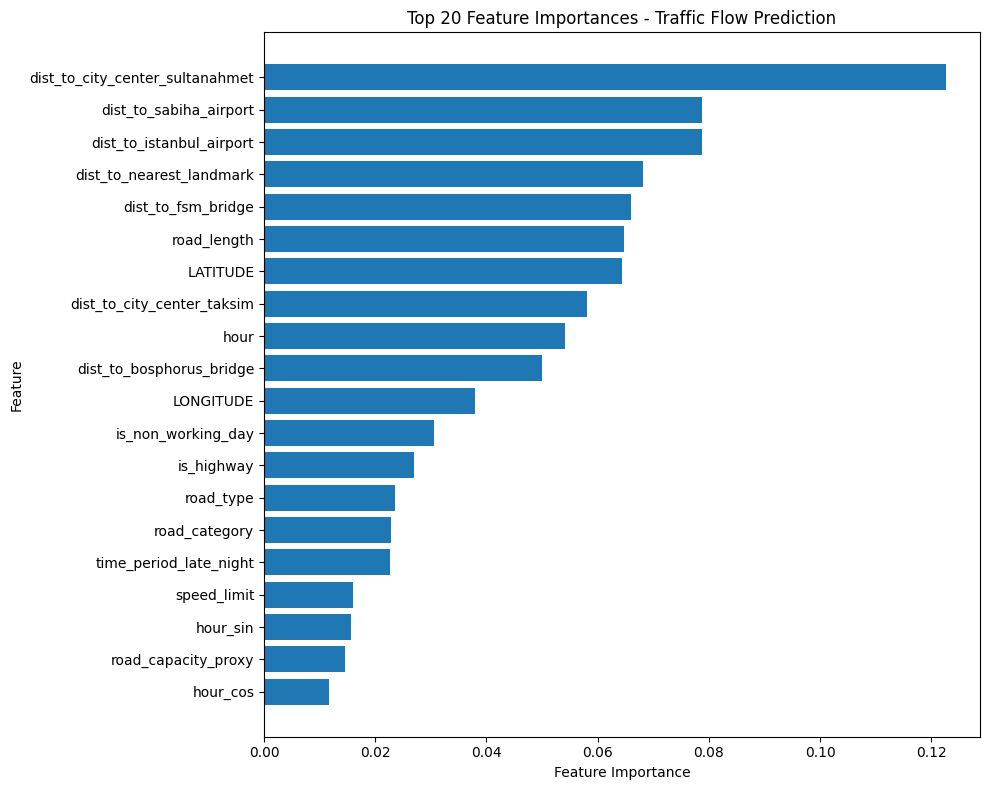

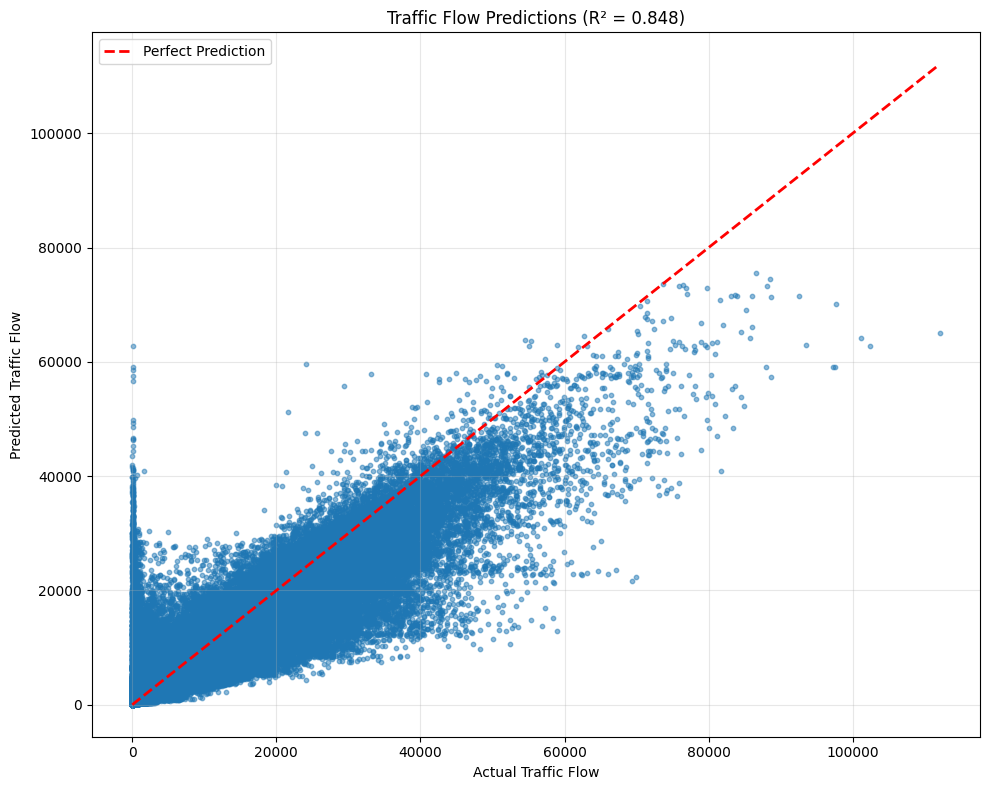

In [ ]:
# @title Traffic Flow Prediction Model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# --- Configuration ---
DATA_FILE = '/content/drive/MyDrive/traffic/ibb_data_fully_enriched.csv'
SPLIT_DATE = '2024-04-23 00:00:00' # Use first ~3 weeks for train, last week for test
TARGET_VARIABLE = 'TRAFFIC_FLOW'  # Our derived target

# Columns to drop (identifiers, co-targets, or text)
DROP_COLS = [
    '_id', 'DATE_TIME', 'GEOHASH',
    'MINIMUM_SPEED', 'MAXIMUM_SPEED',  # Keep NUMBER_OF_VEHICLES and AVERAGE_SPEED for flow calculation
    'holiday_name', 'road_name', 'time_period'
]

# Features we know are categorical
CATEGORICAL_FEATURES = ['road_type', 'road_category']

# --- Utility Function ---
def robust_mape(y_true, y_pred):
    """
    Calculate Mean Absolute Percentage Error, robust to zero values in y_true.
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    mask = y_true > 0
    if np.sum(mask) == 0:
        print("Warning: No valid non-zero ground truth values for MAPE calculation.")
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# --- 1. Load Data ---
print(f"Loading data from {DATA_FILE}...")
try:
    df = pd.read_csv(DATA_FILE)
except FileNotFoundError:
    print(f"Error: Could not find {DATA_FILE}.")
    print("Please make sure you have run the full enrichment script to generate the data file.")
    exit()

# Ensure DATE_TIME is a datetime object for splitting
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], format='mixed')
df = df.sort_values(by='DATE_TIME')
print(f"Data loaded. Shape: {df.shape}")

# --- 2. Create Derived Target: TRAFFIC_FLOW ---
print("\nCreating derived target: TRAFFIC_FLOW...")
print("Traffic Flow = NUMBER_OF_VEHICLES × AVERAGE_SPEED")

# Check if required columns exist
if 'NUMBER_OF_VEHICLES' not in df.columns or 'AVERAGE_SPEED' not in df.columns:
    print("Error: Required columns 'NUMBER_OF_VEHICLES' and/or 'AVERAGE_SPEED' not found.")
    print(f"Available columns: {df.columns.tolist()}")
    exit()

# Create traffic flow metric (vehicles × speed gives flow in vehicle·km/h)
df['TRAFFIC_FLOW'] = df['NUMBER_OF_VEHICLES'] * df['AVERAGE_SPEED']

print(f"Traffic Flow statistics:")
print(f"  Mean: {df['TRAFFIC_FLOW'].mean():.2f}")
print(f"  Median: {df['TRAFFIC_FLOW'].median():.2f}")
print(f"  Std: {df['TRAFFIC_FLOW'].std():.2f}")
print(f"  Min: {df['TRAFFIC_FLOW'].min():.2f}")
print(f"  Max: {df['TRAFFIC_FLOW'].max():.2f}")

# --- 3. Prepare Data for Model ---
print("\nPreparing data for modeling...")

# Drop identifier/text columns
df_model = df.drop(columns=DROP_COLS, errors='ignore')

# Now we need to drop the original NUMBER_OF_VEHICLES and AVERAGE_SPEED
# since we're predicting their product (to avoid data leakage)
df_model = df_model.drop(columns=['NUMBER_OF_VEHICLES', 'AVERAGE_SPEED'], errors='ignore')

# Handle potential NaN in target variable by dropping those rows
df_model = df_model.dropna(subset=[TARGET_VARIABLE])
print(f"Data shape after dropping unusable rows: {df_model.shape}")

# --- 4. Temporal Train-Test Split ---
print(f"\nPerforming temporal split at {SPLIT_DATE}...")
split_timestamp = pd.to_datetime(SPLIT_DATE)

train_df = df_model[df['DATE_TIME'] < split_timestamp]
test_df = df_model[df['DATE_TIME'] >= split_timestamp]

if train_df.empty or test_df.empty:
    print("Error: Train or test split resulted in an empty DataFrame.")
    print(f"Please check your SPLIT_DATE ('{SPLIT_DATE}') and data date range.")
    print(f"Data ranges from {df['DATE_TIME'].min()} to {df['DATE_TIME'].max()}")
    exit()

print(f"Training data: {train_df.shape[0]} samples")
print(f"Testing data:  {test_df.shape[0]} samples")

# Define features (X) and target (y)
X_train = train_df.drop(columns=[TARGET_VARIABLE])
y_train = train_df[TARGET_VARIABLE]

X_test = test_df.drop(columns=[TARGET_VARIABLE])
y_test = test_df[TARGET_VARIABLE]

# Automatically determine numerical features
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()
# Ensure categorical features are not in the numerical list
numerical_features = [col for col in numerical_features if col not in CATEGORICAL_FEATURES]

print(f"\nFeature breakdown:")
print(f"  Numerical features: {len(numerical_features)}")
print(f"  Categorical features: {len(CATEGORICAL_FEATURES)}")

# --- 5. Create Preprocessing and Model Pipeline ---
print("\nBuilding model pipeline...")

# Create transformer for numerical features: impute missing with median
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Create transformer for categorical features: impute missing, then encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Create a preprocessor to apply transformers to the correct columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, CATEGORICAL_FEATURES)
    ],
    remainder='passthrough' # Keep any other columns
)

# Create the full model pipeline
rf_model = RandomForestRegressor(
    n_estimators=100,     # Number of trees
    max_depth=20,         # Prune trees to prevent overfitting
    min_samples_leaf=10,  # Further prevent overfitting
    random_state=42,
    n_jobs=-1             # Use all available CPU cores
)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', rf_model)
])

# --- 6. Train the Model ---
print("\nTraining Random Forest model for Traffic Flow prediction...")
print(f"Training on {len(y_train)} samples. This may take a few minutes...")

# Train on the full training set
model_pipeline.fit(X_train, y_train)

print("✓ Model training complete.")

# --- 7. Evaluate the Model ---
print("\n--- Model Evaluation ---")
y_pred = model_pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = robust_mape(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test Set Metrics (Target: {TARGET_VARIABLE}):")
print(f"  RMSE: {rmse:.3f}")
print(f"   MAE: {mae:.3f}")
print(f"  MAPE: {mape:.3f} %")
print(f"  R-squared (R2): {r2:.3f}")

# Additional analysis: prediction vs actual
print(f"\nPrediction Analysis:")
print(f"  Actual mean: {y_test.mean():.2f}")
print(f"  Predicted mean: {y_pred.mean():.2f}")
print(f"  Actual std: {y_test.std():.2f}")
print(f"  Predicted std: {y_pred.std():.2f}")

# --- 8. Show Feature Importance ---
print("\n--- Top 20 Feature Importances ---")

try:
    # Get all feature names after preprocessing
    preprocessor = model_pipeline.named_steps['preprocessor']
    all_feature_names = preprocessor.get_feature_names_out()

    importances = model_pipeline.named_steps['regressor'].feature_importances_

    if len(all_feature_names) != len(importances):
        print(f"Error: Mismatch in feature name count ({len(all_feature_names)}) and importance count ({len(importances)}).")
    else:
        feature_imp_df = pd.DataFrame(
            {'feature': all_feature_names, 'importance': importances}
        ).sort_values(by='importance', ascending=False)

        # Clean up feature names for better plotting
        feature_imp_df['feature'] = feature_imp_df['feature'].str.replace(r'^(num|cat|remainder)__', '', regex=True)

        print(feature_imp_df.head(20))

        # Plot feature importances
        plt.figure(figsize=(10, 8))
        top_20 = feature_imp_df.head(20)
        plt.barh(top_20['feature'], top_20['importance'])
        plt.xlabel("Feature Importance")
        plt.ylabel("Feature")
        plt.title("Top 20 Feature Importances - Traffic Flow Prediction")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig('rf_traffic_flow_feature_importance.png')
        print("\n✓ Feature importance plot saved to 'rf_traffic_flow_feature_importance.png'")

except Exception as e:
    print(f"Could not generate feature importance plot: {e}")

# --- 9. Visualize Predictions ---
print("\n--- Generating Prediction Visualization ---")
try:
    # Create scatter plot of actual vs predicted
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test, y_pred, alpha=0.5, s=10)

    # Add perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

    plt.xlabel('Actual Traffic Flow')
    plt.ylabel('Predicted Traffic Flow')
    plt.title(f'Traffic Flow Predictions (R² = {r2:.3f})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('rf_traffic_flow_predictions.png')
    print("✓ Prediction scatter plot saved to 'rf_traffic_flow_predictions.png'")
except Exception as e:
    print(f"Could not generate prediction plot: {e}")

print("\nTraffic Flow prediction model script finished.")
print(f"\nNote: Traffic Flow = NUMBER_OF_VEHICLES × AVERAGE_SPEED")
print(f"This metric represents the volume of traffic moving through road segments.")

Loading data from /content/drive/MyDrive/traffic/ibb_data_fully_enriched.csv...
Data loaded. Shape: (1613448, 95)

Creating derived target: TRAFFIC_FLOW...
Traffic Flow = NUMBER_OF_VEHICLES × AVERAGE_SPEED
Traffic Flow statistics:
  Mean: 5886.20
  Median: 2576.00
  Std: 8010.67
  Min: 1.00
  Max: 112056.00

Preprocessing data...

Performing temporal split at 2024-04-23 00:00:00...
Training data: 1234327 samples
Testing data:  379121 samples

Scaling data...

Creating training sequences...
Creating sequences for 2458 sensors...


100%|██████████| 2458/2458 [00:03<00:00, 791.24it/s]


Creating testing sequences...
Creating sequences for 2456 sensors...


100%|██████████| 2456/2456 [00:02<00:00, 1069.60it/s]


Training sequences: X=(1204913, 12, 15), y=(1204913,)
Testing sequences:  X=(349783, 12, 15), y=(349783,)

Building 1D-CNN model for Traffic Flow prediction...


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 12, 15)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 12, 64)         │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 6, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        12,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,649 (158.79 KB)

 Trainable params: 40,649 (158.79 KB)

 Non-trainable params: 0 (0.00 B)


Training model...
This may take some time depending on your hardware...
Epoch 1/50
4707/4707 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - loss: 0.1055 - mae: 0.1807 - val_loss: 0.1260 - val_mae: 0.1655
Epoch 2/50
4707/4707 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 0.0539 - mae: 0.1334 - val_loss: 0.1112 - val_mae: 0.1603
Epoch 3/50
4707/4707 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.0486 - mae: 0.1278 - val_loss: 0.1068 - val_mae: 0.1631
Epoch 4/50
4707/4707 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 0.0465 - mae: 0.1255 - val_loss: 0.1192 - val_mae: 0.1585
Epoch 5/50
4707/4707 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 0.0450 - mae: 0.1235 - val_loss: 0.1137 - val_mae: 0.1570
Epoch 6/50
4707/4707 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 0.0433 - mae: 0.1220 - val_loss: 0.1142 - val_mae: 0.1584
Epoch 7/50
4707/4707 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 0.0425 - mae: 0.1209 - val_loss: 0.1123 - val_mae: 0.1554
Epoch 8/50
4707/4707 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 0.0420 - mae: 0.1

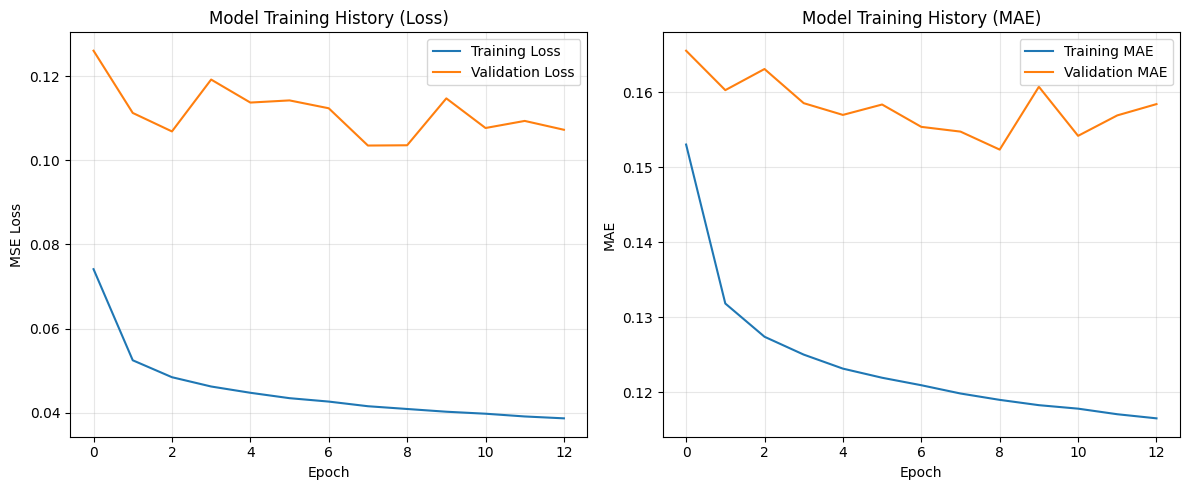

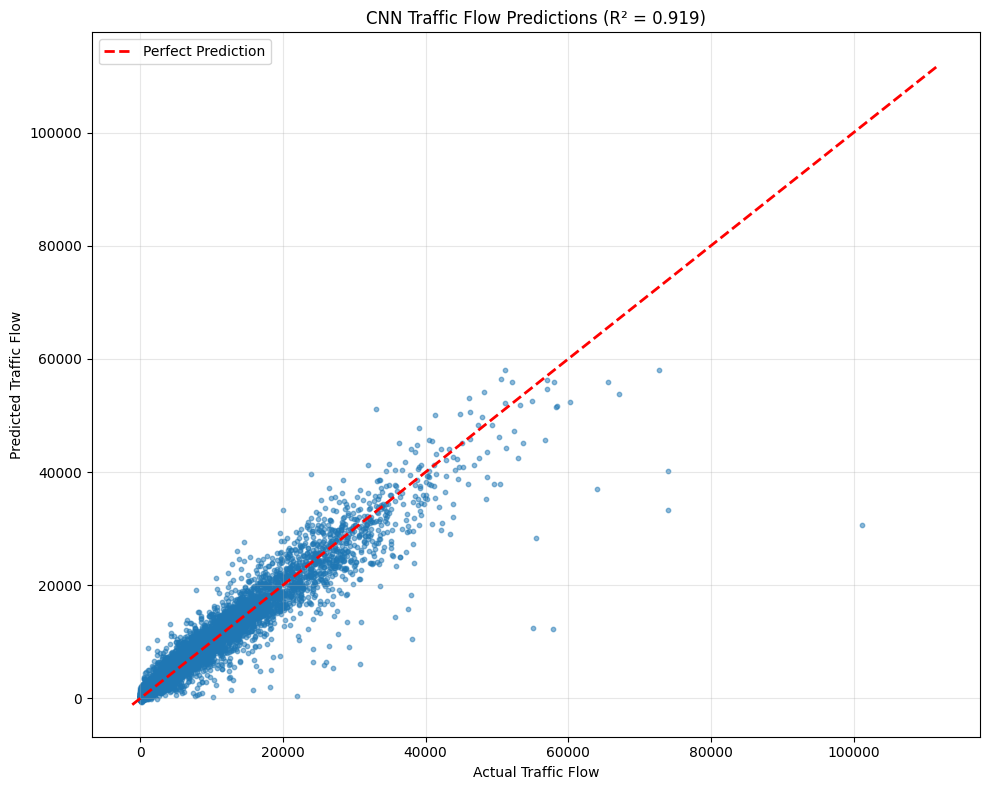

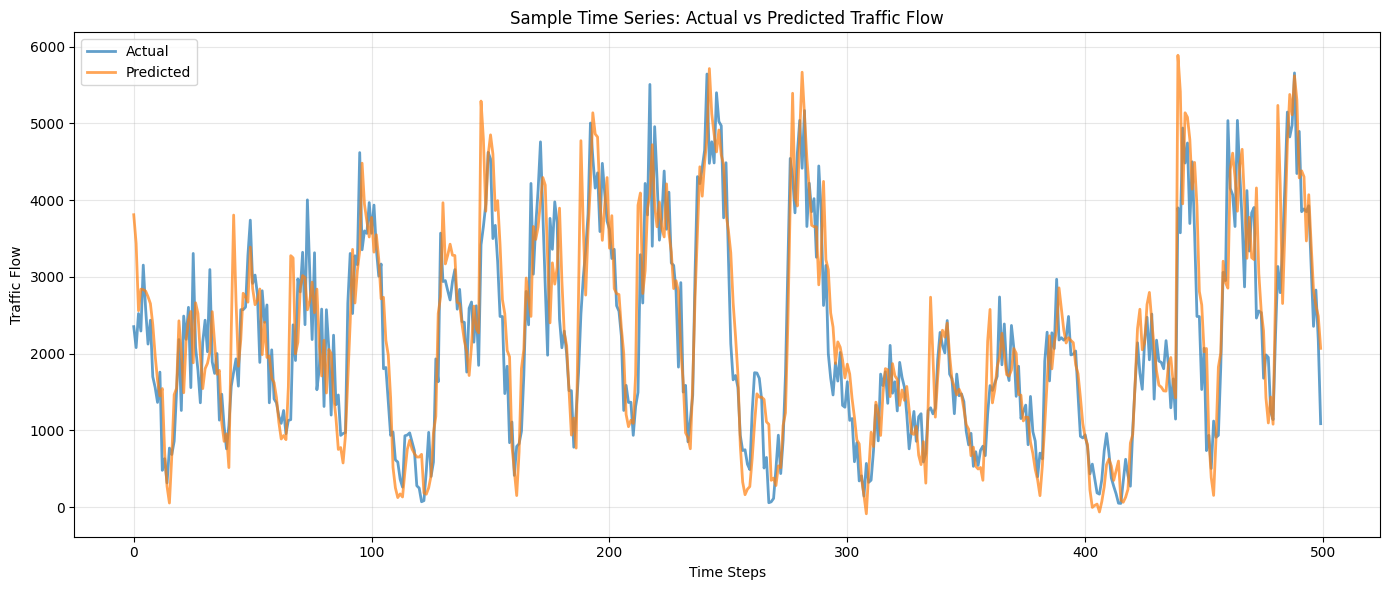

In [ ]:
# @title CNN Traffic Flow Prediction Model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Dense, GlobalAveragePooling1D, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tqdm import tqdm

# --- Configuration ---
DATA_FILE = '/content/drive/MyDrive/traffic/ibb_data_fully_enriched.csv'
SPLIT_DATE = '2024-04-23 00:00:00' # Same split as RF for fair comparison
TARGET_VARIABLE = 'TRAFFIC_FLOW'  # Our derived target
SENSOR_ID_COLUMN = 'GEOHASH'

# How many hours of data to look at to make a prediction
SEQUENCE_LENGTH = 12 # Look at the last 12 hours
# How many hours in the future to predict
PREDICTION_HORIZON = 1 # Predict 1 hour ahead

# --- Utility Functions ---

def robust_mape(y_true, y_pred):
    """ Calculate Mean Absolute Percentage Error, robust to zero values in y_true. """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true > 0
    if np.sum(mask) == 0: return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def create_sequences(data, feature_cols, target_col, sensor_id_col, seq_len, pred_hor):
    """
    Creates sequences of (X, y) pairs for time series forecasting,
    grouped by sensor.
    """
    X_out, y_out = [], []

    # Group by sensor to create sequences only within each sensor's data
    grouped = data.groupby(sensor_id_col)

    print(f"Creating sequences for {len(grouped)} sensors...")

    for sensor_id, sensor_data in tqdm(grouped):
        features = sensor_data[feature_cols].values
        target = sensor_data[target_col].values

        num_samples = len(features)

        for i in range(num_samples - seq_len - pred_hor + 1):
            # Input sequence (X): [i, i+1, ..., i+seq_len-1]
            X_out.append(features[i : i + seq_len])

            # Output value (y): [i+seq_len+pred_hor-1]
            y_out.append(target[i + seq_len + pred_hor - 1])

    return np.array(X_out), np.array(y_out)

# --- 1. Load Data ---
print(f"Loading data from {DATA_FILE}...")
df = pd.read_csv(DATA_FILE)
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], format='mixed')
df = df.sort_values(by=[SENSOR_ID_COLUMN, 'DATE_TIME'])
print(f"Data loaded. Shape: {df.shape}")

# --- 2. Create Derived Target: TRAFFIC_FLOW ---
print("\nCreating derived target: TRAFFIC_FLOW...")
print("Traffic Flow = NUMBER_OF_VEHICLES × AVERAGE_SPEED")

# Check if required columns exist
if 'NUMBER_OF_VEHICLES' not in df.columns or 'AVERAGE_SPEED' not in df.columns:
    print("Error: Required columns 'NUMBER_OF_VEHICLES' and/or 'AVERAGE_SPEED' not found.")
    exit()

# Create traffic flow metric
df['TRAFFIC_FLOW'] = df['NUMBER_OF_VEHICLES'] * df['AVERAGE_SPEED']

print(f"Traffic Flow statistics:")
print(f"  Mean: {df['TRAFFIC_FLOW'].mean():.2f}")
print(f"  Median: {df['TRAFFIC_FLOW'].median():.2f}")
print(f"  Std: {df['TRAFFIC_FLOW'].std():.2f}")
print(f"  Min: {df['TRAFFIC_FLOW'].min():.2f}")
print(f"  Max: {df['TRAFFIC_FLOW'].max():.2f}")

# --- 3. Feature Selection & Preprocessing ---
print("\nPreprocessing data...")

# Select features. Include traffic flow as autoregressive feature.
# NOTE: We DO NOT include raw NUMBER_OF_VEHICLES or AVERAGE_SPEED to avoid data leakage
FEATURE_COLS = [
    'TRAFFIC_FLOW',  # Include target as a feature (autoregression)
    'hour_sin', 'hour_cos',
    'day_of_week_sin', 'day_of_week_cos',
    'is_weekend', 'is_rush_hour', 'is_holiday',
    'temperature', 'humidity', 'precipitation', 'is_raining',
    'speed_limit', 'num_lanes', 'is_highway'
]
TARGET_COL_INDEX = 0 # TRAFFIC_FLOW is the 0th index in FEATURE_COLS

# Simple imputation (forward fill for time series, then 0 for start)
df[FEATURE_COLS] = df.groupby(SENSOR_ID_COLUMN)[FEATURE_COLS].ffill().fillna(0)

# --- 4. Temporal Train-Test Split ---
print(f"\nPerforming temporal split at {SPLIT_DATE}...")
split_timestamp = pd.to_datetime(SPLIT_DATE)
train_df = df[df['DATE_TIME'] < split_timestamp].copy()
test_df = df[df['DATE_TIME'] >= split_timestamp].copy()

if train_df.empty or test_df.empty:
    print("Error: Train or test split resulted in an empty DataFrame.")
    exit()

print(f"Training data: {train_df.shape[0]} samples")
print(f"Testing data:  {test_df.shape[0]} samples")

# --- 5. Scaling (CRITICAL for Neural Networks) ---
# Fit scalers ONLY on training data
print("\nScaling data...")
target_scaler = StandardScaler()
feature_scaler = StandardScaler()

# Fit and transform training data
train_df[TARGET_VARIABLE] = target_scaler.fit_transform(train_df[[TARGET_VARIABLE]])
train_df[FEATURE_COLS] = feature_scaler.fit_transform(train_df[FEATURE_COLS])

# Only transform test data (use training data's mean/std)
test_df[TARGET_VARIABLE] = target_scaler.transform(test_df[[TARGET_VARIABLE]])
test_df[FEATURE_COLS] = feature_scaler.transform(test_df[FEATURE_COLS])

# --- 6. Create Sequences ---
print("\nCreating training sequences...")
X_train, y_train = create_sequences(
    train_df, FEATURE_COLS, TARGET_VARIABLE, SENSOR_ID_COLUMN,
    SEQUENCE_LENGTH, PREDICTION_HORIZON
)

print("Creating testing sequences...")
X_test, y_test = create_sequences(
    test_df, FEATURE_COLS, TARGET_VARIABLE, SENSOR_ID_COLUMN,
    SEQUENCE_LENGTH, PREDICTION_HORIZON
)

if X_train.shape[0] == 0 or X_test.shape[0] == 0:
    print("Error: No sequences created. Check SEQUENCE_LENGTH and data.")
    exit()

print(f"Training sequences: X={X_train.shape}, y={y_train.shape}")
print(f"Testing sequences:  X={X_test.shape}, y={y_test.shape}")
num_features = X_train.shape[2]

# --- 7. Build 1D-CNN Model ---
print("\nBuilding 1D-CNN model for Traffic Flow prediction...")

def build_cnn_model(seq_len, num_features):
    inputs = Input(shape=(seq_len, num_features))

    # First convolutional block
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = MaxPooling1D(pool_size=2)(x)

    # Second convolutional block
    x = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(x)

    # Global pooling to flatten
    x = GlobalAveragePooling1D()(x)

    # Dense layers for prediction
    x = Dense(100, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(1, activation='linear')(x) # Linear activation for regression

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

model = build_cnn_model(SEQUENCE_LENGTH, num_features)
model.summary()

# --- 8. Train the Model ---
print("\nTraining model...")
print("This may take some time depending on your hardware...")

# Stop training if validation loss doesn't improve
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50, # Set a high number, early stopping will find the best
    batch_size=256,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    shuffle=True
)

print("✓ Model training complete.")

# --- 9. Evaluate the Model ---
print("\n--- Model Evaluation ---")
# Predict on test data (predictions are scaled)
y_pred_scaled = model.predict(X_test)

# Inverse transform to get actual traffic flow values
# We must reshape y_test to 2D for the scaler
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_actual = target_scaler.inverse_transform(y_pred_scaled)

# Calculate metrics on the *actual* (unscaled) values
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mape = robust_mape(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)

print(f"Test Set Metrics (Target: {TARGET_VARIABLE}):")
print(f"  RMSE: {rmse:.3f}")
print(f"   MAE: {mae:.3f}")
print(f"  MAPE: {mape:.3f} %")
print(f"  R-squared (R2): {r2:.3f}")

# Additional prediction analysis
print(f"\nPrediction Analysis:")
print(f"  Actual mean: {y_test_actual.mean():.2f}")
print(f"  Predicted mean: {y_pred_actual.mean():.2f}")
print(f"  Actual std: {y_test_actual.std():.2f}")
print(f"  Predicted std: {y_pred_actual.std():.2f}")

print("\n--- Comparison to RF Baseline ---")
print("RF Baseline:  RMSE: 3391, MAE: 1667, R²: 0.848")
print(f"CNN Model:    RMSE: {rmse:.0f}, MAE: {mae:.0f}, R²: {r2:.3f}")

# --- 10. Plot Training History ---
print("\nSaving training history plot...")
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training History (Loss)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# MAE plot
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model Training History (MAE)')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_traffic_flow_training_history.png')
print("✓ Plot saved to 'cnn_traffic_flow_training_history.png'")

# --- 11. Visualize Predictions ---
print("\nGenerating prediction visualization...")
try:
    plt.figure(figsize=(10, 8))

    # Sample for better visualization (plotting all points may be too dense)
    sample_size = min(10000, len(y_test_actual))
    indices = np.random.choice(len(y_test_actual), sample_size, replace=False)

    plt.scatter(y_test_actual[indices], y_pred_actual[indices], alpha=0.5, s=10)

    # Add perfect prediction line
    min_val = min(y_test_actual.min(), y_pred_actual.min())
    max_val = max(y_test_actual.max(), y_pred_actual.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

    plt.xlabel('Actual Traffic Flow')
    plt.ylabel('Predicted Traffic Flow')
    plt.title(f'CNN Traffic Flow Predictions (R² = {r2:.3f})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('cnn_traffic_flow_predictions.png')
    print("✓ Prediction scatter plot saved to 'cnn_traffic_flow_predictions.png'")
except Exception as e:
    print(f"Could not generate prediction plot: {e}")

# --- 12. Time Series Visualization ---
print("\nGenerating time series sample visualization...")
try:
    # Show a sample sensor's predictions over time
    sample_size = min(500, len(y_test_actual))

    plt.figure(figsize=(14, 6))
    plt.plot(range(sample_size), y_test_actual[:sample_size],
             label='Actual', alpha=0.7, linewidth=2)
    plt.plot(range(sample_size), y_pred_actual[:sample_size],
             label='Predicted', alpha=0.7, linewidth=2)
    plt.xlabel('Time Steps')
    plt.ylabel('Traffic Flow')
    plt.title('Sample Time Series: Actual vs Predicted Traffic Flow')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('cnn_traffic_flow_timeseries.png')
    print("✓ Time series plot saved to 'cnn_traffic_flow_timeseries.png'")
except Exception as e:
    print(f"Could not generate time series plot: {e}")

print("\n" + "="*60)
print("CNN Traffic Flow Prediction Model - Training Complete")
print("="*60)
print(f"\nModel Configuration:")
print(f"  - Sequence Length: {SEQUENCE_LENGTH} hours")
print(f"  - Prediction Horizon: {PREDICTION_HORIZON} hour(s)")
print(f"  - Features: {num_features}")
print(f"  - Training samples: {X_train.shape[0]:,}")
print(f"  - Test samples: {X_test.shape[0]:,}")
print(f"\nNote: Traffic Flow = NUMBER_OF_VEHICLES × AVERAGE_SPEED")
print(f"This model uses temporal sequences to capture time-dependent patterns.")
print("="*60)

Using device: cuda
Part 1: Building Sensor Graph...
Part 2: Pivoting Data into Tensors...
Part 3: Defining GCN Model...

Loading data...

Creating derived target: TRAFFIC_FLOW...
Traffic Flow = NUMBER_OF_VEHICLES × AVERAGE_SPEED
Traffic Flow statistics:
  Mean: 5886.20
  Median: 2576.00
  Std: 8010.67
  Min: 1.00
  Max: 112056.00
Data shape after dropping NaN: (1613448, 96)
Graph built: 2458 nodes, 9822 edges
Populating tensors for 1613448 records...


100%|██████████| 1613448/1613448 [01:00<00:00, 26721.24it/s]


Interpolating missing values (per-sensor, over time)...
Scaling data...
✓ Tensors built and scaled.

Training timesteps: 0 to 466
Validation timesteps: 467 to 518
Test timesteps: 519 to 710

Part 4: Training GCN (Spatial Graph) Model for Traffic Flow...


Epoch 01, Train Loss: 0.892516, Val Loss: 0.794493
  Val loss improved. Saving model to best_gcn_traffic_flow_model.pth


Epoch 02, Train Loss: 0.806683, Val Loss: 0.730888
  Val loss improved. Saving model to best_gcn_traffic_flow_model.pth


...

Epoch 76, Train Loss: 0.161568, Val Loss: 0.160417
  Val loss did not improve. Patience: 8/10


Epoch 77, Train Loss: 0.170853, Val Loss: 0.158498
  Val loss did not improve. Patience: 9/10


Epoch 78, Train Loss: 0.162426, Val Loss: 0.198404
  Val loss did not improve. Patience: 10/10

Early stopping triggered after 78 epochs.

Part 5: Evaluating Model...
Loading best model from best_gcn_traffic_flow_model.pth...


Evaluating: 100%|██████████| 192/192 [00:00<00:00, 221.16it/s]



GCN Traffic Flow Model Evaluation
Test Set Metrics (Target: TRAFFIC_FLOW):
  RMSE: 5070.546
   MAE: 2680.866
  MAPE: 1058.413 %
  R-squared (R2): 0.612

Prediction Analysis:
  Actual mean: 5242.88
  Predicted mean: 6032.24
  Actual std: 8144.72
  Predicted std: 7773.30

Baseline Comparison Summary
RF Baseline (Spatial-Features):  RMSE: 3391, MAE: 1667, R²: 0.848
CNN Baseline (Temporal):         RMSE: 2502, MAE: 1204, R²: 0.919
GCN Model (Spatial-Graph):       RMSE: 5071, MAE: 2681, R²: 0.612

Generating visualizations...
✓ Training history saved to 'gcn_traffic_flow_training_history.png'
✓ Prediction plot saved to 'gcn_traffic_flow_predictions.png'

GCN Traffic Flow Model Training Complete!


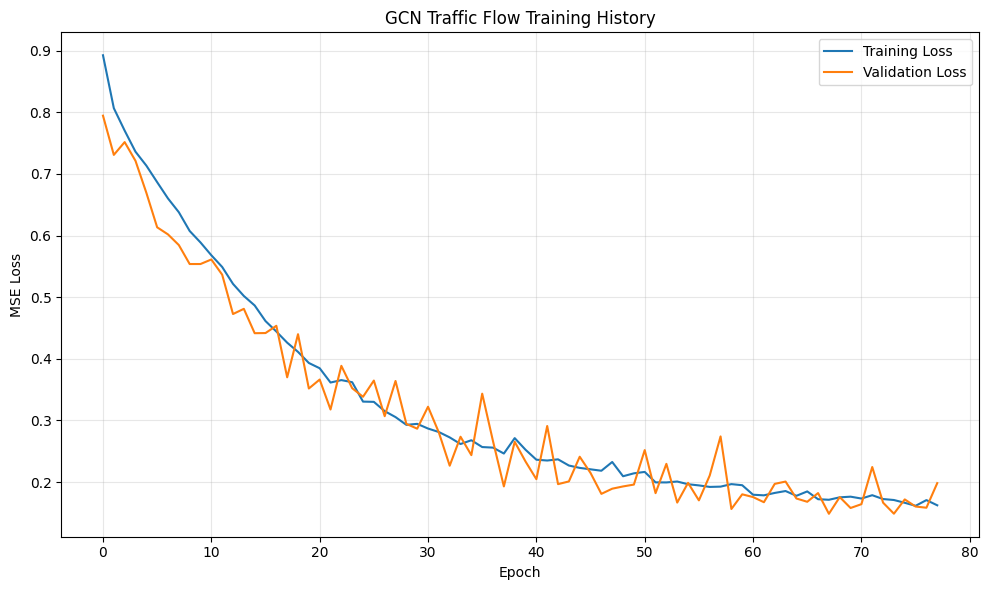

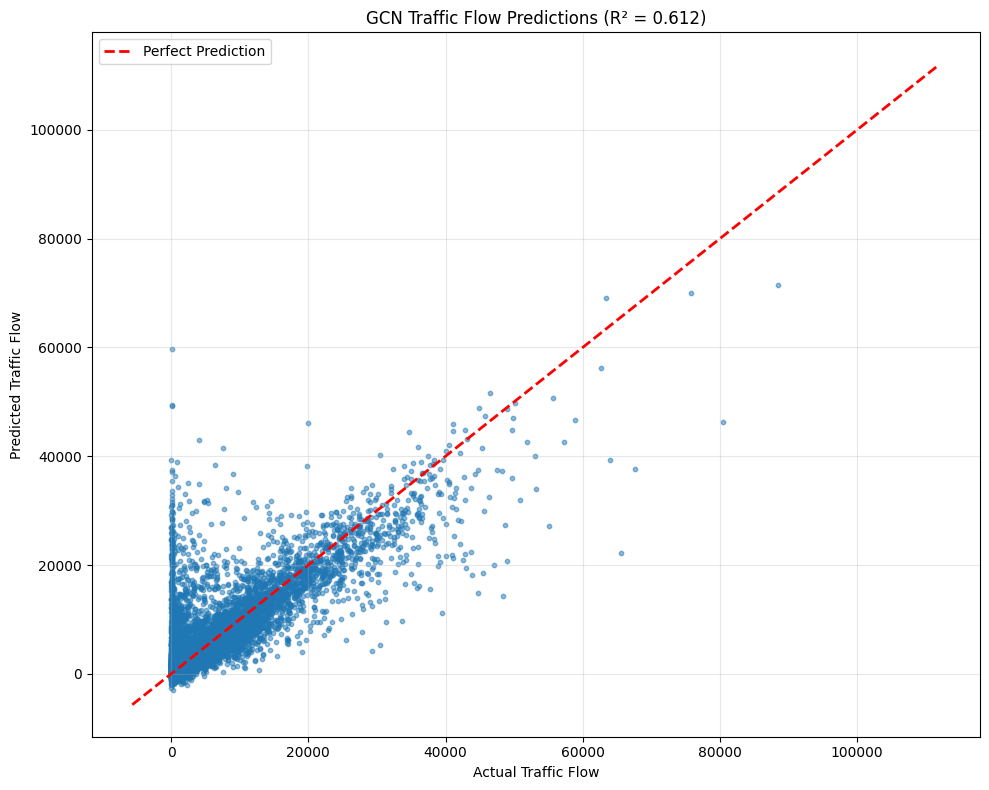

In [ ]:
# @title GCN Traffic Flow Prediction Model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics.pairwise import haversine_distances
import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from scipy.sparse import coo_matrix
from tqdm import tqdm

# --- Configuration ---
DATA_FILE = '/content/drive/MyDrive/traffic/ibb_data_fully_enriched.csv'
TARGET_VARIABLE = 'TRAFFIC_FLOW'  # Our derived target
SPLIT_DATE = '2024-04-23 00:00:00' # Same split as others

# Graph construction parameters
DISTANCE_THRESHOLD_KM = 1.0 # Connect sensors within 1km
GAUSSIAN_SIGMA = 0.5 # For edge weight calculation

# Features to use. We separate dynamic (time-varying) and static (constant per-sensor)
# Note: We CANNOT use NUMBER_OF_VEHICLES or AVERAGE_SPEED as features (data leakage)
DYNAMIC_FEATURE_COLS = [
    'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos',
    'is_weekend', 'is_rush_hour', 'is_holiday', 'is_ramadan_month',
    'temperature', 'humidity', 'precipitation', 'wind_speed', 'is_raining'
]
STATIC_FEATURE_COLS = [
    'LATITUDE', 'LONGITUDE', 'speed_limit', 'num_lanes', 'is_highway',
    'dist_to_city_center_taksim', 'dist_to_bosphorus_bridge', 'dist_to_istanbul_airport'
]
ALL_FEATURE_COLS = DYNAMIC_FEATURE_COLS + STATIC_FEATURE_COLS

# Model parameters
LEARNING_RATE = 0.001 # Lower learning rate for finer tuning
EPOCHS = 100 # Increase max epochs
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# --- Early Stopping Parameters ---
PATIENCE = 10 # Increase patience to 10
BEST_MODEL_PATH = 'best_gcn_traffic_flow_model.pth'

# --- Utility Functions ---
def robust_mape(y_true, y_pred):
    """ Calculate Mean Absolute Percentage Error, robust to zero values in y_true. """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true > 0
    if np.sum(mask) == 0: return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# --- Part 1: Build the Graph (Adjacency Matrix) ---
print("Part 1: Building Sensor Graph...")

@torch.no_grad()
def build_graph(df, dist_thresh_km, sigma):
    # 1. Get unique sensors and their locations
    sensor_df = df[['GEOHASH', 'LATITUDE', 'LONGITUDE']].drop_duplicates()
    sensor_df = sensor_df.sort_values(by='GEOHASH').reset_index(drop=True)

    num_sensors = len(sensor_df)

    # 2. Create mapping: GEOHASH -> node_index
    geohash_to_index = {geohash: idx for idx, geohash in enumerate(sensor_df['GEOHASH'])}

    # 3. Calculate pairwise haversine distance (in km)
    locations_rad = np.radians(sensor_df[['LATITUDE', 'LONGITUDE']].values)
    dist_matrix_km = haversine_distances(locations_rad) * 6371 # Earth radius in km

    # 4. Create adjacency matrix using Gaussian kernel
    adj_matrix = np.exp(-(dist_matrix_km ** 2) / (sigma ** 2))

    # 5. Apply distance threshold
    adj_matrix[dist_matrix_km > dist_thresh_km] = 0

    # 6. Add self-loops
    np.fill_diagonal(adj_matrix, 1)

    # 7. Convert to sparse edge_index format for PyG
    sparse_adj = coo_matrix(adj_matrix)
    edge_index = torch.tensor(np.vstack((sparse_adj.row, sparse_adj.col)), dtype=torch.long)
    edge_weight = torch.tensor(sparse_adj.data, dtype=torch.float)

    print(f"Graph built: {num_sensors} nodes, {edge_index.shape[1]} edges")
    return edge_index, edge_weight, sensor_df, geohash_to_index

# --- Part 2: Build Pivoted Tensors (X, y) ---
print("Part 2: Pivoting Data into Tensors...")

def build_tensors(df, sensor_df, geohash_to_index):
    # 1. Get all timestamps (sorted)
    all_times_sorted = np.sort(df['DATE_TIME'].unique())
    all_times = pd.to_datetime(all_times_sorted)
    time_to_index = {time: idx for idx, time in enumerate(all_times)}

    num_sensors = len(sensor_df)
    num_timesteps = len(all_times)
    num_dyn_features = len(DYNAMIC_FEATURE_COLS)
    num_stat_features = len(STATIC_FEATURE_COLS)

    # 2. Initialize Tensors with NaN
    X_dynamic = torch.full((num_sensors, num_timesteps, num_dyn_features), np.nan, dtype=torch.float)
    X_static = torch.full((num_sensors, num_stat_features), np.nan, dtype=torch.float)
    y_tensor = torch.full((num_sensors, num_timesteps, 1), np.nan, dtype=torch.float)

    # 3. Populate static features (once per sensor)
    static_data = df.drop_duplicates(subset='GEOHASH')
    static_data = static_data.set_index('GEOHASH').loc[sensor_df['GEOHASH']]
    X_static = torch.tensor(static_data[STATIC_FEATURE_COLS].values, dtype=torch.float)

    # 4. Populate dynamic tensors
    print(f"Populating tensors for {len(df)} records...")
    for row in tqdm(df.itertuples(), total=len(df)):
        node_idx = geohash_to_index.get(row.GEOHASH)
        time_idx = time_to_index.get(row.DATE_TIME)

        if node_idx is not None and time_idx is not None:
            X_dynamic[node_idx, time_idx, :] = torch.tensor(
                [getattr(row, col) for col in DYNAMIC_FEATURE_COLS], dtype=torch.float
            )
            y_tensor[node_idx, time_idx, 0] = getattr(row, TARGET_VARIABLE)

    # 5. Interpolate missing values (e.g., sensor offline for 1 hour)
    print("Interpolating missing values (per-sensor, over time)...")
    X_dynamic_pd = pd.DataFrame(X_dynamic.reshape(-1, num_dyn_features), columns=DYNAMIC_FEATURE_COLS)
    y_tensor_pd = pd.DataFrame(y_tensor.reshape(-1, 1), columns=[TARGET_VARIABLE])

    # Interpolate and fill remaining NaNs
    X_dynamic_pd = X_dynamic_pd.interpolate(method='linear', limit_direction='both').fillna(0)
    y_tensor_pd = y_tensor_pd.interpolate(method='linear', limit_direction='both').fillna(0)

    X_dynamic = torch.tensor(X_dynamic_pd.values, dtype=torch.float).reshape(num_sensors, num_timesteps, num_dyn_features)
    y_tensor = torch.tensor(y_tensor_pd.values, dtype=torch.float).reshape(num_sensors, num_timesteps, 1)

    # 6. Create split
    split_time_idx = time_to_index[pd.to_datetime(SPLIT_DATE)]

    # 7. Scale data
    print("Scaling data...")
    scalers = {'y': StandardScaler(), 'dyn': StandardScaler(), 'stat': StandardScaler()}

    # Fit on training data
    scalers['y'].fit(y_tensor[:, :split_time_idx, :].reshape(-1, 1))
    scalers['dyn'].fit(X_dynamic[:, :split_time_idx, :].reshape(-1, num_dyn_features))
    scalers['stat'].fit(X_static) # Static features are fit on all data

    # Transform all data
    y_tensor = torch.tensor(scalers['y'].transform(y_tensor.reshape(-1, 1)), dtype=torch.float).reshape(num_sensors, num_timesteps, 1)
    X_dynamic = torch.tensor(scalers['dyn'].transform(X_dynamic.reshape(-1, num_dyn_features)), dtype=torch.float).reshape(num_sensors, num_timesteps, num_dyn_features)
    X_static = torch.tensor(scalers['stat'].transform(X_static), dtype=torch.float)

    print("✓ Tensors built and scaled.")
    return X_dynamic, X_static, y_tensor, all_times, split_time_idx, scalers

# --- Part 3: Define GCN Model ---
print("Part 3: Defining GCN Model...")

class GCN(torch.nn.Module):
    def __init__(self, num_features, hidden_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels * 2) # Make wider
        self.conv3 = GCNConv(hidden_channels * 2, hidden_channels * 2) # Keep the same width
        self.conv4 = GCNConv(hidden_channels * 2, hidden_channels) # Add a 4th layer
        self.out = Linear(hidden_channels, 1) # Predict 1 value (traffic flow)

    def forward(self, x, edge_index, edge_weight):
        # x: [num_nodes, num_features]
        # edge_index: [2, num_edges]
        x = self.conv1(x, edge_index, edge_weight)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)

        x = self.conv2(x, edge_index, edge_weight)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)

        x = self.conv3(x, edge_index, edge_weight)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)

        x = self.conv4(x, edge_index, edge_weight)
        x = F.relu(x)

        x = self.out(x)
        return x

# --- Part 4: Main Execution ---
def main():
    # 1. Load data
    print("\nLoading data...")
    df = pd.read_csv(DATA_FILE, dtype={'holiday_name': str})
    df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], format='mixed')

    # 2. Create derived target: TRAFFIC_FLOW
    print("\nCreating derived target: TRAFFIC_FLOW...")
    print("Traffic Flow = NUMBER_OF_VEHICLES × AVERAGE_SPEED")

    if 'NUMBER_OF_VEHICLES' not in df.columns or 'AVERAGE_SPEED' not in df.columns:
        print("Error: Required columns 'NUMBER_OF_VEHICLES' and/or 'AVERAGE_SPEED' not found.")
        return

    df['TRAFFIC_FLOW'] = df['NUMBER_OF_VEHICLES'] * df['AVERAGE_SPEED']

    print(f"Traffic Flow statistics:")
    print(f"  Mean: {df['TRAFFIC_FLOW'].mean():.2f}")
    print(f"  Median: {df['TRAFFIC_FLOW'].median():.2f}")
    print(f"  Std: {df['TRAFFIC_FLOW'].std():.2f}")
    print(f"  Min: {df['TRAFFIC_FLOW'].min():.2f}")
    print(f"  Max: {df['TRAFFIC_FLOW'].max():.2f}")

    # Drop rows with NaN in features or target
    df = df.dropna(subset=ALL_FEATURE_COLS + [TARGET_VARIABLE])
    print(f"Data shape after dropping NaN: {df.shape}")

    # 3. Build graph
    edge_index, edge_weight, sensor_df, geohash_to_index = build_graph(
        df, DISTANCE_THRESHOLD_KM, GAUSSIAN_SIGMA
    )

    # 4. Build tensors
    X_dyn, X_stat, y, all_times, split_idx, scalers = build_tensors(
        df, sensor_df, geohash_to_index
    )

    num_sensors, num_timesteps, num_dyn_features = X_dyn.shape
    num_stat_features = X_stat.shape[1]
    num_total_features = num_dyn_features + num_stat_features

    # --- Create Validation Split ---
    # Use 10% of the training data for validation
    val_split_idx = int(split_idx * 0.9)
    train_timesteps = range(val_split_idx)
    val_timesteps = range(val_split_idx, split_idx)

    print(f"\nTraining timesteps: 0 to {val_split_idx - 1}")
    print(f"Validation timesteps: {val_split_idx} to {split_idx - 1}")
    print(f"Test timesteps: {split_idx} to {num_timesteps - 1}")

    # 5. Prepare for training
    model = GCN(num_features=num_total_features, hidden_channels=128).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = torch.nn.MSELoss()

    edge_index = edge_index.to(DEVICE)
    edge_weight = edge_weight.to(DEVICE)
    X_stat_expanded = X_stat.unsqueeze(1).expand(-1, num_timesteps, -1).to(DEVICE) # [N, T, F_stat]
    X_dyn = X_dyn.to(DEVICE)
    y = y.to(DEVICE)

    # --- Early Stopping Logic ---
    best_val_loss = float('inf')
    epochs_no_improve = 0
    train_losses = []
    val_losses = []

    print("\nPart 4: Training GCN (Spatial Graph) Model for Traffic Flow...")

    for epoch in range(1, EPOCHS + 1):
        # --- Training Phase ---
        model.train()
        train_loss = 0

        # Iterate over time (train split)
        for t in tqdm(range(len(train_timesteps)), desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False):
            optimizer.zero_grad()

            # Get data for this snapshot
            x_dyn_t = X_dyn[:, t, :]
            x_stat_t = X_stat_expanded[:, t, :]
            x_t = torch.cat([x_dyn_t, x_stat_t], dim=1)
            y_t = y[:, t, :] # [N, 1]

            # Forward pass
            out = model(x_t, edge_index, edge_weight) # [N, 1]

            loss = criterion(out, y_t)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_timesteps)
        train_losses.append(avg_train_loss)

        # --- Validation Phase ---
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for t in tqdm(val_timesteps, desc=f"Epoch {epoch}/{EPOCHS} [Val]", leave=False):
                x_dyn_t = X_dyn[:, t, :]
                x_stat_t = X_stat_expanded[:, t, :]
                x_t = torch.cat([x_dyn_t, x_stat_t], dim=1)
                y_t = y[:, t, :]

                out = model(x_t, edge_index, edge_weight)
                loss = criterion(out, y_t)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_timesteps)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch:02d}, Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}")

        # --- Early Stopping Check ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            # Save the best model
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            print(f"  Val loss improved. Saving model to {BEST_MODEL_PATH}")
        else:
            epochs_no_improve += 1
            print(f"  Val loss did not improve. Patience: {epochs_no_improve}/{PATIENCE}")

        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping triggered after {epoch} epochs.")
            break

    # --- Part 5: Evaluation ---
    print("\nPart 5: Evaluating Model...")

    # Load the best model weights for evaluation
    print(f"Loading best model from {BEST_MODEL_PATH}...")
    model.load_state_dict(torch.load(BEST_MODEL_PATH))

    model.eval()
    all_y_pred_actual = []
    all_y_test_actual = []

    with torch.no_grad():
        for t in tqdm(range(split_idx, num_timesteps), desc="Evaluating"):
            # Get data for this snapshot
            x_dyn_t = X_dyn[:, t, :]
            x_stat_t = X_stat_expanded[:, t, :]
            x_t = torch.cat([x_dyn_t, x_stat_t], dim=1)
            y_t = y[:, t, :]

            # Get prediction (scaled)
            y_pred_scaled = model(x_t, edge_index, edge_weight)

            # Inverse scale
            y_pred_actual = scalers['y'].inverse_transform(y_pred_scaled.cpu().numpy())
            y_test_actual = scalers['y'].inverse_transform(y_t.cpu().numpy())

            all_y_pred_actual.append(y_pred_actual)
            all_y_test_actual.append(y_test_actual)

    # Flatten lists for final metrics
    all_y_pred_actual = np.concatenate(all_y_pred_actual).flatten()
    all_y_test_actual = np.concatenate(all_y_test_actual).flatten()

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(all_y_test_actual, all_y_pred_actual))
    mae = mean_absolute_error(all_y_test_actual, all_y_pred_actual)
    mape = robust_mape(all_y_test_actual, all_y_pred_actual)
    r2 = r2_score(all_y_test_actual, all_y_pred_actual)

    print("\n" + "="*60)
    print("GCN Traffic Flow Model Evaluation")
    print("="*60)
    print(f"Test Set Metrics (Target: {TARGET_VARIABLE}):")
    print(f"  RMSE: {rmse:.3f}")
    print(f"   MAE: {mae:.3f}")
    print(f"  MAPE: {mape:.3f} %")
    print(f"  R-squared (R2): {r2:.3f}")

    # Additional prediction analysis
    print(f"\nPrediction Analysis:")
    print(f"  Actual mean: {all_y_test_actual.mean():.2f}")
    print(f"  Predicted mean: {all_y_pred_actual.mean():.2f}")
    print(f"  Actual std: {all_y_test_actual.std():.2f}")
    print(f"  Predicted std: {all_y_pred_actual.std():.2f}")

    print("\n" + "="*60)
    print("Baseline Comparison Summary")
    print("="*60)
    print(f"RF Baseline (Spatial-Features):  RMSE: 3391, MAE: 1667, R²: 0.848")
    print(f"CNN Baseline (Temporal):         RMSE: 2502, MAE: 1204, R²: 0.919")
    print(f"GCN Model (Spatial-Graph):       RMSE: {rmse:.0f}, MAE: {mae:.0f}, R²: {r2:.3f}")
    print("="*60)

    # --- Part 6: Visualizations ---
    print("\nGenerating visualizations...")

    # Training history
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('GCN Traffic Flow Training History')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('gcn_traffic_flow_training_history.png')
    print("✓ Training history saved to 'gcn_traffic_flow_training_history.png'")

    # Prediction scatter plot
    plt.figure(figsize=(10, 8))
    sample_size = min(10000, len(all_y_test_actual))
    indices = np.random.choice(len(all_y_test_actual), sample_size, replace=False)

    plt.scatter(all_y_test_actual[indices], all_y_pred_actual[indices], alpha=0.5, s=10)
    min_val = min(all_y_test_actual.min(), all_y_pred_actual.min())
    max_val = max(all_y_test_actual.max(), all_y_pred_actual.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

    plt.xlabel('Actual Traffic Flow')
    plt.ylabel('Predicted Traffic Flow')
    plt.title(f'GCN Traffic Flow Predictions (R² = {r2:.3f})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('gcn_traffic_flow_predictions.png')
    print("✓ Prediction plot saved to 'gcn_traffic_flow_predictions.png'")

    print("\n" + "="*60)
    print("GCN Traffic Flow Model Training Complete!")
    print("="*60)

if __name__ == "__main__":
    main()

In [ ]:
# @title STGCN Traffic Flow Prediction Model
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neighbors import kneighbors_graph # <-- Import for k-NN
import torch
import torch.nn.functional as F
from torch.nn import Linear, Conv1d, Dropout, LayerNorm # <-- Base torch modules
#
# No torch_geometric imports
#
from torch.utils.data import DataLoader, TensorDataset
import torch.optim.lr_scheduler # <-- Import scheduler
from scipy.sparse import coo_matrix
from tqdm import tqdm
import sys # for file error handling

# --- Configuration ---
# !!! SET THIS TO YOUR DATA FILE PATH !!!
DATA_FILE = '/content/drive/MyDrive/traffic/ibb_data_fully_enriched.csv'
TARGET_VARIABLE = 'traffic_flow'  # Derived: AVERAGE_SPEED * NUMBER_OF_VEHICLES
SPLIT_DATE = '2024-04-23 00:00:00'

# Graph construction
K_NEIGHBORS = 8 # <-- Use k-NN
GAUSSIAN_SIGMA = 1.0 # <-- Sigma for k-NN distance weighting

# Model & Sequence parameters
SEQUENCE_LENGTH = 12
PREDICTION_HORIZON = 1
BATCH_SIZE = 64

# Features
DYNAMIC_FEATURE_COLS = [
    'AVERAGE_SPEED', 'NUMBER_OF_VEHICLES', 'hour_sin', 'hour_cos', 'day_of_week_sin',
    'day_of_week_cos', 'is_weekend', 'is_rush_hour', 'is_holiday',
    'temperature', 'humidity', 'precipitation', 'is_raining'
]
STATIC_FEATURE_COLS = [
    'LATITUDE', 'LONGITUDE', 'speed_limit', 'num_lanes', 'is_highway',
    'dist_to_city_center_taksim', 'dist_to_bosphorus_bridge'
]
ALL_MODEL_FEATURES = DYNAMIC_FEATURE_COLS + STATIC_FEATURE_COLS

# Training parameters
LEARNING_RATE = 0.001
EPOCHS = 100
PATIENCE = 10
SCHEDULER_PATIENCE = 3
SCHEDULER_FACTOR = 0.5
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BEST_MODEL_PATH = 'best_stgcn_model_traffic_flow.pth'
print(f"Using device: {DEVICE}")

# --- Utility Functions ---
def robust_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true > 0
    if np.sum(mask) == 0: return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# --- Part 1: Build Graph (MODIFIED for k-NN and Manual GCN) ---
@torch.no_grad()
def build_graph(df, k_neighbors, sigma):
    print("Part 1: Building Sensor Graph (k-NN, Manual GCN)...")
    sensor_df = df[['GEOHASH', 'LATITUDE', 'LONGITUDE']].drop_duplicates()
    sensor_df = sensor_df.sort_values(by='GEOHASH').reset_index(drop=True)
    num_sensors = len(sensor_df)
    geohash_to_index = {geohash: idx for idx, geohash in enumerate(sensor_df['GEOHASH'])}

    locations_rad = np.radians(sensor_df[['LATITUDE', 'LONGITUDE']].values)

    # 1. k-NN graph
    adj_matrix_sparse = kneighbors_graph(
        locations_rad,
        n_neighbors=k_neighbors,
        mode='distance',
        metric='haversine'
    )

    # 2. Gaussian weights
    adj_matrix_sparse.data = np.exp(-( (adj_matrix_sparse.data * 6371) ** 2) / (sigma ** 2))

    # 3. Make symmetric
    adj_matrix_dense = adj_matrix_sparse.toarray()
    adj_matrix = np.maximum(adj_matrix_dense, adj_matrix_dense.T)

    # 4. Add self-loops
    np.fill_diagonal(adj_matrix, 1)

    # 5. Create Normalized Adjacency Matrix (for manual GCN)
    # A = A + I (already done)
    # D_ii = sum(A_ij)
    deg = np.sum(adj_matrix, axis=1)
    # D_inv_sqrt
    deg_inv_sqrt = np.power(deg, -0.5)
    deg_inv_sqrt[np.isinf(deg_inv_sqrt)] = 0.0
    # D_inv_sqrt as a diagonal matrix
    deg_mat_inv_sqrt = np.diag(deg_inv_sqrt)

    # norm_adj = D^(-1/2) * A * D^(-1/2)
    norm_adj = deg_mat_inv_sqrt.dot(adj_matrix).dot(deg_mat_inv_sqrt)

    # 6. Convert to sparse torch tensor
    sparse_norm_adj = coo_matrix(norm_adj)

    indices = torch.from_numpy(
        np.vstack((sparse_norm_adj.row, sparse_norm_adj.col))
    ).long()
    values = torch.from_numpy(sparse_norm_adj.data).float()
    shape = torch.Size(sparse_norm_adj.shape)

    norm_adj_sparse_tensor = torch.sparse_coo_tensor(indices, values, shape)

    print(f"Graph built: {num_sensors} nodes. Normalized adjacency matrix created.")
    return norm_adj_sparse_tensor, sensor_df, geohash_to_index

# --- Part 2: Build Pivoted Tensors (MODIFIED to compute traffic_flow) ---
def build_tensors(df, sensor_df, geohash_to_index):
    print("Part 2: Computing traffic_flow and Pivoting Data into Tensors...")

    # Derive traffic_flow target variable
    if 'AVERAGE_SPEED' not in df.columns or 'NUMBER_OF_VEHICLES' not in df.columns:
        print("ERROR: Required columns AVERAGE_SPEED and NUMBER_OF_VEHICLES not found in dataset.")
        sys.exit(1)

    # Compute traffic flow
    df['traffic_flow'] = df['AVERAGE_SPEED'] * df['NUMBER_OF_VEHICLES']
    print(f"✓ Computed traffic_flow (min: {df['traffic_flow'].min():.2f}, max: {df['traffic_flow'].max():.2f}, mean: {df['traffic_flow'].mean():.2f})")

    all_times_sorted = np.sort(df['DATE_TIME'].unique())
    all_times = pd.to_datetime(all_times_sorted)
    time_to_index = {time: idx for idx, time in enumerate(all_times)}

    num_sensors = len(sensor_df)
    num_timesteps = len(all_times)
    num_dyn_features = len(DYNAMIC_FEATURE_COLS)
    num_stat_features = len(STATIC_FEATURE_COLS)

    X_dynamic = torch.full((num_sensors, num_timesteps, num_dyn_features), np.nan, dtype=torch.float)
    X_static = torch.full((num_sensors, num_stat_features), np.nan, dtype=torch.float)
    y_tensor = torch.full((num_sensors, num_timesteps, 1), np.nan, dtype=torch.float)

    try:
        static_data = df.drop_duplicates(subset='GEOHASH').set_index('GEOHASH').loc[sensor_df['GEOHASH']]
    except KeyError:
         print("Error: Some GEOHASH IDs from sensor_df not found in main df. This can happen with very small test datasets.")
         # Fallback: create static data with what's available
         static_data_all = df.drop_duplicates(subset='GEOHASH').set_index('GEOHASH')
         static_data = static_data_all.reindex(sensor_df['GEOHASH'])

    X_static = torch.tensor(static_data[STATIC_FEATURE_COLS].values, dtype=torch.float)

    print(f"Populating tensors for {len(df)} records...")
    for row in tqdm(df.itertuples(), total=len(df)):
        node_idx = geohash_to_index.get(row.GEOHASH)
        time_idx = time_to_index.get(row.DATE_TIME)

        if node_idx is not None and time_idx is not None:
            X_dynamic[node_idx, time_idx, :] = torch.tensor([getattr(row, col) for col in DYNAMIC_FEATURE_COLS], dtype=torch.float)
            y_tensor[node_idx, time_idx, 0] = getattr(row, TARGET_VARIABLE)

    print("Interpolating missing values...")
    X_dynamic_pd = pd.DataFrame(X_dynamic.reshape(-1, num_dyn_features), columns=DYNAMIC_FEATURE_COLS)
    y_tensor_pd = pd.DataFrame(y_tensor.reshape(-1, 1), columns=[TARGET_VARIABLE])

    X_dynamic_pd = X_dynamic_pd.interpolate(method='linear', limit_direction='both').fillna(0)
    y_tensor_pd = y_tensor_pd.interpolate(method='linear', limit_direction='both').fillna(0)

    X_dynamic = torch.tensor(X_dynamic_pd.values, dtype=torch.float).reshape(num_sensors, num_timesteps, num_dyn_features)
    y_tensor = torch.tensor(y_tensor_pd.values, dtype=torch.float).reshape(num_sensors, num_timesteps, 1)

    # Handle potential NaNs in static features (e.g., from fallback)
    if torch.isnan(X_static).any():
        print("Warning: NaNs found in static features. Filling with 0.")
        X_static = torch.nan_to_num(X_static, nan=0.0)

    split_time_idx = time_to_index[pd.to_datetime(SPLIT_DATE)]

    print("Scaling data...")
    scalers = {'y': StandardScaler(), 'dyn': StandardScaler(), 'stat': StandardScaler()}

    scalers['y'].fit(y_tensor[:, :split_time_idx, :].reshape(-1, 1))
    scalers['dyn'].fit(X_dynamic[:, :split_time_idx, :].reshape(-1, num_dyn_features))
    scalers['stat'].fit(X_static)

    y_tensor = torch.tensor(scalers['y'].transform(y_tensor.reshape(-1, 1)), dtype=torch.float).reshape(num_sensors, num_timesteps, 1)
    X_dynamic = torch.tensor(scalers['dyn'].transform(X_dynamic.reshape(-1, num_dyn_features)), dtype=torch.float).reshape(num_sensors, num_timesteps, num_dyn_features)
    X_static = torch.tensor(scalers['stat'].transform(X_static), dtype=torch.float)

    print("✓ Tensors built and scaled.")

    # Combine all features into one tensor
    X_static_expanded = X_static.unsqueeze(1).expand(-1, num_timesteps, -1) # [N, T, F_stat]
    X_all_features = torch.cat([X_dynamic, X_static_expanded], dim=2) # [N, T, F_dyn + F_stat]

    return X_all_features, y_tensor, all_times, split_time_idx, scalers

# --- Part 3: Create Sequences (Same as before) ---
def create_sequences(X, y, seq_len, pred_hor, split_idx):
    print("Part 3: Creating Spatio-Temporal Sequences...")
    num_nodes, num_timesteps, num_features = X.shape

    X_seq, y_seq = [], []
    for t in range(num_timesteps - seq_len - pred_hor + 1):
        X_seq.append(X[:, t : t + seq_len, :]) # [N, seq_len, F]
        y_seq.append(y[:, t + seq_len + pred_hor - 1, :]) # [N, 1]

    if not X_seq:
        print(f"Error: No sequences created. Check SEQUENCE_LENGTH ({seq_len}), PREDICTION_HORIZON ({pred_hor}), and total timesteps ({num_timesteps}).")
        sys.exit(1)

    X_seq = torch.stack(X_seq) # [Num_Samples, N, seq_len, F]
    y_seq = torch.stack(y_seq) # [Num_Samples, N, 1]

    train_val_split = split_idx - seq_len
    val_split = int(train_val_split * 0.9)

    X_train = X_seq[:val_split]
    y_train = y_seq[:val_split]

    X_val = X_seq[val_split:train_val_split]
    y_val = y_seq[val_split:train_val_split]

    X_test = X_seq[train_val_split:]
    y_test = y_seq[train_val_split:]

    print(f"Total sequences: {len(X_seq)}")
    print(f"Train sequences: X={X_train.shape}, y={y_train.shape}")
    print(f"Val sequences:   X={X_val.shape}, y={y_val.shape}")
    print(f"Test sequences:  X={X_test.shape}, y={y_test.shape}")

    return X_train, y_train, X_val, y_val, X_test, y_test

# --- Part 4: Define STGCN Model (MODIFIED, No torch_geometric) ---
print("Part 4: Defining STGCN Model (v3, Manual GCN)...")

class STGCNBlock(torch.nn.Module):
    def __init__(self, in_channels, out_channels, hidden_channels, num_nodes):
        super(STGCNBlock, self).__init__()
        # Spatial convolution (Replaced GCNConv with Linear)
        self.spatial_proj = Linear(in_channels, hidden_channels)
        # Temporal convolution
        self.tcn = Conv1d(hidden_channels, out_channels, kernel_size=3, padding=1)

        self.num_nodes = num_nodes
        self.hidden_channels = hidden_channels
        self.out_channels = out_channels

        self.norm1 = LayerNorm(hidden_channels)
        self.norm2 = LayerNorm(out_channels)
        self.dropout = Dropout(0.1)

        if in_channels != out_channels:
            self.residual_conv = Conv1d(in_channels, out_channels, kernel_size=1)
        else:
            self.residual_conv = None

    def forward(self, x, norm_adj_sparse):
        # x shape: [B, N, T, F_in]
        batch_size, _, seq_len, in_channels = x.shape

        # --- 1. Save Residual ---
        x_res_in = x.permute(0, 1, 3, 2).reshape(-1, in_channels, seq_len)
        if self.residual_conv:
            x_residual = self.residual_conv(x_res_in)
        else:
            x_residual = x_res_in
        x_residual = x_residual.reshape(batch_size, self.num_nodes, self.out_channels, seq_len)
        x_residual = x_residual.permute(0, 1, 3, 2) # [B, N, T, F_out]

        # --- 2. Spatial GCN (Manual) ---
        # Reshape for projection: [B, N, T, F_in] -> [B*T, N, F_in]
        x_gcn_in = x.permute(0, 2, 1, 3).reshape(-1, self.num_nodes, in_channels)

        # Apply W: (XW)
        # [B*T, N, F_in] -> [B*T*N, F_in]
        x_proj_in = x_gcn_in.reshape(-1, in_channels)
        # [B*T*N, F_hid]
        x_proj_out = self.spatial_proj(x_proj_in)

        # Reshape for graph conv: [B*T, N, F_hid]
        x_conv_in = x_proj_out.reshape(-1, self.num_nodes, self.hidden_channels)

        # Apply A: (A(XW))
        # We must loop over the batch (B*T dimension)
        gcn_out_list = []
        for i in range(x_conv_in.shape[0]):
            # snapshot = [N, F_hid]
            snapshot = x_conv_in[i]
            # A_norm @ snapshot
            # [N, N] @ [N, F_hid] -> [N, F_hid]
            gcn_out = torch.sparse.mm(norm_adj_sparse, snapshot)
            gcn_out_list.append(gcn_out)

        x_gcn_out = torch.stack(gcn_out_list) # [B*T, N, F_hid]

        # Reshape for LayerNorm: [B, T, N, F_hid]
        x_gcn_out = x_gcn_out.reshape(batch_size, seq_len, self.num_nodes, self.hidden_channels)

        # --- 3. Add Norm & ReLU ---
        x_gcn_out = self.norm1(x_gcn_out)
        x_gcn_out = F.relu(x_gcn_out)

        # Permute for TCN: [B, N, T, F_hid]
        x_gcn_out = x_gcn_out.permute(0, 2, 1, 3)

        # --- 4. Temporal CNN ---
        x_tcn_in = x_gcn_out.permute(0, 1, 3, 2).reshape(-1, self.hidden_channels, seq_len)
        x_tcn_out = self.tcn(x_tcn_in) # [B*N, F_out, T]

        # Reshape for Norm/Residual: [B, N, T, F_out]
        x_tcn_out = x_tcn_out.reshape(batch_size, self.num_nodes, self.out_channels, seq_len)
        x_tcn_out = x_tcn_out.permute(0, 1, 3, 2)

        # --- 5. Add Norm & ReLU ---
        x_tcn_out = self.norm2(x_tcn_out)
        x_tcn_out = F.relu(x_tcn_out)

        # --- 6. Add Residual Connection & Dropout ---
        out = x_tcn_out + x_residual
        out = self.dropout(out)

        return out

class STGCN(torch.nn.Module):
    def __init__(self, num_nodes, num_features, seq_len):
        super(STGCN, self).__init__()
        self.block1 = STGCNBlock(num_features, 64, 32, num_nodes)
        self.block2 = STGCNBlock(64, 128, 64, num_nodes)

        self.final_linear1 = Linear(128, 64)
        self.final_linear2 = Linear(64, 1)
        self.dropout_out = Dropout(0.1)

    def forward(self, x, norm_adj_sparse):
        # x shape: [B, N, T, F]
        x = self.block1(x, norm_adj_sparse) # [B, N, T, 64]
        x = self.block2(x, norm_adj_sparse) # [B, N, T, 128]

        # Take only the last time step
        x = x[:, :, -1, :] # Shape: [B, N, 128]

        x = F.relu(self.final_linear1(x)) # [B, N, 64]
        x = self.dropout_out(x)
        x = self.final_linear2(x) # [B, N, 1]

        return x

# --- Part 5: Main Execution (MODIFIED) ---
def main():

    # 1. Load data
    try:
        df = pd.read_csv(DATA_FILE, dtype={'holiday_name': str})
    except FileNotFoundError:
        print(f"ERROR: Data file not found at {DATA_FILE}")
        print("Please check the path and permissions.")
        return
    except Exception as e:
        print(f"Error loading data: {e}")
        return

    df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], format='mixed')

    # Check for required columns before dropping NaN
    required_cols = ['AVERAGE_SPEED', 'NUMBER_OF_VEHICLES'] + DYNAMIC_FEATURE_COLS + STATIC_FEATURE_COLS
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        print(f"ERROR: Missing required columns: {missing_cols}")
        return

    df = df.dropna(subset=required_cols)

    # 2. Build graph
    # Returns normalized sparse adj tensor
    norm_adj_sparse, sensor_df, geohash_to_index = build_graph(
        df, K_NEIGHBORS, GAUSSIAN_SIGMA
    )

    # 3. Build tensors (this will compute traffic_flow)
    X_all, y, all_times, split_idx, scalers = build_tensors(
        df, sensor_df, geohash_to_index
    )

    num_sensors, _, num_features = X_all.shape

    # 4. Create sequences
    X_train, y_train, X_val, y_val, X_test, y_test = create_sequences(
        X_all, y, SEQUENCE_LENGTH, PREDICTION_HORIZON, split_idx
    )

    # 5. Create DataLoaders
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

    val_dataset = TensorDataset(X_val, y_val)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    test_dataset = TensorDataset(X_test, y_test)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # 6. Initialize model and training components
    model = STGCN(num_sensors, num_features, SEQUENCE_LENGTH).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = torch.nn.MSELoss()

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=SCHEDULER_FACTOR,
        patience=SCHEDULER_PATIENCE
    )

    # Move graph tensor to device
    norm_adj_sparse = norm_adj_sparse.to(DEVICE)

    best_val_loss = float('inf')
    epochs_no_improve = 0

    print("\nPart 5: Training STGCN Model (Traffic Flow Target)...")

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss = 0

        for X_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False):
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()

            # Pass normalized adjacency matrix to the model
            out = model(X_batch, norm_adj_sparse) # [B, N, 1]

            loss = criterion(out, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # --- Validation Phase ---
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [Val]", leave=False):
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

                # Pass normalized adjacency matrix
                out = model(X_batch, norm_adj_sparse)

                loss = criterion(out, y_batch)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        scheduler.step(avg_val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        print(f"Epoch {epoch:02d}, Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}, LR: {current_lr:.6f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            print(f"  Val loss improved. Saving model to {BEST_MODEL_PATH}")
        else:
            epochs_no_improve += 1
            print(f"  Val loss did not improve. Patience: {epochs_no_improve}/{PATIENCE}")

        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping triggered after {epoch} epochs.")
            break

    # --- Part 6: Evaluation ---
    print("\nPart 6: Evaluating STGCN Model (Traffic Flow Target)...")

    try:
        model.load_state_dict(torch.load(BEST_MODEL_PATH))
        print(f"Loading best model from {BEST_MODEL_PATH}...")
    except FileNotFoundError:
        print(f"ERROR: Best model file not found at {BEST_MODEL_PATH}.")
        print("Evaluating with the model from the last epoch.")
    except Exception as e:
        print(f"Error loading model: {e}. Evaluating with current model.")

    model.eval()
    all_y_pred_actual = []
    all_y_test_actual = []

    with torch.no_grad():
        for X_batch, y_batch in tqdm(test_loader, desc="Evaluating"):
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

            # Pass normalized adjacency matrix
            y_pred_scaled = model(X_batch, norm_adj_sparse) # [B, N, 1]

            y_pred_actual = scalers['y'].inverse_transform(y_pred_scaled.cpu().numpy().reshape(-1, 1))
            y_test_actual = scalers['y'].inverse_transform(y_batch.cpu().numpy().reshape(-1, 1))

            all_y_pred_actual.append(y_pred_actual)
            all_y_test_actual.append(y_test_actual)

    all_y_pred_actual = np.concatenate(all_y_pred_actual).flatten()
    all_y_test_actual = np.concatenate(all_y_test_actual).flatten()

    rmse = np.sqrt(mean_squared_error(all_y_test_actual, all_y_pred_actual))
    mae = mean_absolute_error(all_y_test_actual, all_y_pred_actual)
    mape = robust_mape(all_y_test_actual, all_y_pred_actual)
    r2 = r2_score(all_y_test_actual, all_y_pred_actual)

    print("\n" + "="*60)
    print("STGCN Model Evaluation - Traffic Flow Target")
    print("="*60)
    print(f"Target Variable: {TARGET_VARIABLE} (AVERAGE_SPEED × NUMBER_OF_VEHICLES)")
    print(f"\nTest Set Metrics:")
    print(f"  RMSE: {rmse:.3f} (vehicles·km/h)")
    print(f"   MAE: {mae:.3f} (vehicles·km/h)")
    print(f"  MAPE: {mape:.3f} %")
    print(f"    R²: {r2:.3f}")
    print("="*60)

    # --- Part 7: Save Preprocessing Artifacts (NEW) ---
    print("\nPart 7: Saving Preprocessing Artifacts for Interface...")

    # 1. Save Scalers (using Pickle)
    # This saves the exact mean/std used during training
    with open('scalers.pkl', 'wb') as f:
        pickle.dump(scalers, f)
    print("✓ Scalers saved to 'scalers.pkl'")

    # 2. Save Adjacency Matrix (using Torch)
    # We move it to CPU first to avoid GPU errors on the web interface
    torch.save(norm_adj_sparse.cpu(), 'adj_matrix.pt')
    print("✓ Adjacency matrix saved to 'adj_matrix.pt'")

    # 3. Save Sensor Order (using Pickle)
    # CRITICAL: We need to know which node index (0, 1, 2...) belongs to which Geohash
    # sensor_df was created in Part 1 of main()
    with open('sensor_order.pkl', 'wb') as f:
        pickle.dump(sensor_df['GEOHASH'].values, f)
    print("✓ Sensor order saved to 'sensor_order.pkl'")

    print("\nAll files ready for Streamlit deployment!")


if __name__ == "__main__":
    main()

Using device: cuda
Part 4: Defining STGCN Model (v3, Manual GCN)...
Creating derived feature: TRAFFIC_FLOW...
Part 1: Building Sensor Graph (k-NN, Manual GCN)...
Graph built: 2458 nodes. Normalized adjacency matrix created.
Part 2: Computing traffic_flow and Pivoting Data into Tensors...
✓ Computed traffic_flow (min: 1.00, max: 112056.00, mean: 5886.20)
Populating tensors for 1613448 records...


100%|██████████| 1613448/1613448 [01:00<00:00, 26457.90it/s]


Interpolating missing values...
Scaling data...
✓ Tensors built and scaled.
Part 3: Creating Spatio-Temporal Sequences...
Total sequences: 699
Train sequences: X=torch.Size([456, 2458, 12, 34]), y=torch.Size([456, 2458, 1])
Val sequences:   X=torch.Size([51, 2458, 12, 34]), y=torch.Size([51, 2458, 1])
Test sequences:  X=torch.Size([192, 2458, 12, 34]), y=torch.Size([192, 2458, 1])

Part 5: Training STGCN Model (Traffic Flow Target)...


Epoch 01, Train Loss: 0.768972, Val Loss: 0.491105, LR: 0.001000
  Val loss improved. Saving model to best_stgcn_model_traffic_flow.pth


Epoch 02, Train Loss: 0.419185, Val Loss: 0.268401, LR: 0.001000
  Val loss improved. Saving model to best_stgcn_model_traffic_flow.pth


...

Epoch 27, Train Loss: 0.110104, Val Loss: 0.106282, LR: 0.000250
  Val loss did not improve. Patience: 8/10


Epoch 28, Train Loss: 0.109886, Val Loss: 0.103235, LR: 0.000250
  Val loss did not improve. Patience: 9/10


Epoch 29, Train Loss: 0.097932, Val Loss: 0.103587, LR: 0.000250
  Val loss did not improve. Patience: 10/10

Early stopping triggered after 29 epochs.

Part 6: Evaluating STGCN Model (Traffic Flow Target)...
Loading best model from best_stgcn_model_traffic_flow.pth...


Evaluating: 100%|██████████| 3/3 [00:02<00:00,  1.23it/s]


STGCN Model Evaluation - Traffic Flow Target
Target Variable: traffic_flow (AVERAGE_SPEED × NUMBER_OF_VEHICLES)

Test Set Metrics:
  RMSE: 3592.844 (vehicles·km/h)
   MAE: 1893.670 (vehicles·km/h)
  MAPE: 308.908 %
    R²: 0.805

Part 7: Saving Preprocessing Artifacts for Interface...
✓ Scalers saved to 'scalers.pkl'
✓ Adjacency matrix saved to 'adj_matrix.pt'
✓ Sensor order saved to 'sensor_order.pkl'

All files ready for Streamlit deployment!


# New Section

In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 75.6 MB/s eta 0:00:00


In [ ]:
# @title
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv
from torch_geometric.utils import dense_to_sparse

class DynamicGraphLearner(nn.Module):
    """
    Pathway 2: Dynamic Graph Representation
    Learns a dynamic adjacency matrix based on node similarity.
    Formula: Adj = Softmax(ReLU( (X @ W1) @ (X @ W2).T ))
    """
    def __init__(self, input_size, hidden_size, k_neighbors=None):
        super(DynamicGraphLearner, self).__init__()
        self.k_neighbors = k_neighbors

        # Two linear transformations for "Source" vs "Target" context
        self.weight1 = nn.Linear(input_size, hidden_size)
        self.weight2 = nn.Linear(input_size, hidden_size)

        # Learnable scaling factor
        self.alpha = nn.Parameter(torch.randn(1))
        self.act = nn.ReLU()

    def forward(self, x):
        """
        x shape: [Num_Nodes, Features] (Features at a specific timestep)
        Returns: [Num_Nodes, Num_Nodes] Adjacency Matrix
        """
        # 1. Transform features
        h1 = self.weight1(x) # [N, Hidden]
        h2 = self.weight2(x) # [N, Hidden]

        # 2. Compute Similarity (Attention Scores)
        # [N, Hidden] @ [Hidden, N] -> [N, N]
        adj = torch.matmul(h1, h2.transpose(-1, -2))
        adj = self.act(self.alpha * adj)

        # 3. Sparsification (Optional: Keep only top-k neighbors)
        # This is crucial for memory efficiency if N > 1000
        if self.k_neighbors is not None:
            topk_val, topk_idx = torch.topk(adj, k=self.k_neighbors, dim=-1)
            mask = torch.zeros_like(adj)
            mask.scatter_(-1, topk_idx, topk_val)
            adj = mask

        # 4. Normalization (Row-wise Softmax)
        # Makes the graph function like a transition probability matrix
        adj = F.softmax(adj, dim=-1)

        return adj

class DGATBlock(nn.Module):
    """
    Combines Dynamic Graph Learning with GAT and Transformer
    """
    def __init__(self, num_nodes, in_channels, out_channels, heads=4):
        super(DGATBlock, self).__init__()

        # 1. Dynamic Graph Learner
        self.graph_learner = DynamicGraphLearner(in_channels, 64, k_neighbors=20)

        # 2. Graph Attention Layer (Spatial)
        # GATv2 is generally superior to standard GAT
        self.gat = GATv2Conv(in_channels, out_channels // heads, heads=heads, concat=True)

        # 3. Normalization & Residual
        self.norm = nn.LayerNorm(out_channels)
        self.dropout = nn.Dropout(0.1)

        # Residual connection if dimensions match
        self.residual = nn.Linear(in_channels, out_channels) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        # x: [Batch, Num_Nodes, Seq_Len, Features]
        # For graph learning, we typically use the most recent state or average state
        # Let's take the mean over the time sequence for stability
        x_context = x.mean(dim=2) # [Batch, N, F]

        batch_size, num_nodes, seq_len, num_features = x.shape

        # Loop over batch (Dynamic graphs are different for each sample in batch!)
        # Note: For efficiency, you might process valid batches together if memory allows
        outputs = []

        for b in range(batch_size):
            # A. Learn Graph for this batch sample
            adj_matrix = self.graph_learner(x_context[b])

            # Convert dense adj to sparse edge_index for PyG
            edge_index, edge_weight = dense_to_sparse(adj_matrix)

            # B. Apply GAT (Spatial Convolution)
            # We apply GAT to each timestep using the learned graph structure
            # Reshape: [N, T, F] -> [N*T, F] to process all times at once
            x_batch = x[b] # [N, T, F]
            x_reshaped = x_batch.reshape(-1, num_features)

            # Repeat edge_index for the temporal dimension is tricky.
            # Simpler approach: Loop over time (slower) or use 3D GNNs.
            # For this skeleton, we'll process the last timestep as the primary prediction target
            # which aligns with many STGCN implementations.
            x_last = x_batch[:, -1, :] # [N, F]

            out_gat = self.gat(x_last, edge_index) # [N, Out_F]
            outputs.append(out_gat)

        x_out = torch.stack(outputs) # [Batch, N, Out_F]

        # Residual + Norm
        x_res = self.residual(x[:, :, -1, :])
        return self.norm(x_out + x_res)

class DGATNet(nn.Module):
    """
    Full Architecture: DGAT-Net (Section 5.2 of your paper)
    """
    def __init__(self, num_nodes, num_features, hidden_dim=64):
        super(DGATNet, self).__init__()

        # 1. Spatio-Temporal Blocks
        self.layer1 = DGATBlock(num_nodes, num_features, hidden_dim)
        self.layer2 = DGATBlock(num_nodes, hidden_dim, hidden_dim)

        # 2. Transformer Encoder (Temporal)
        # Takes the sequence of spatially processed features
        # Note: Since we simplified the block to output only the last step,
        # we would typically stack these differently for full sequence-to-sequence.
        # For a graduation project, start with the spatial block feeding a simple predictor.

        # 3. Prediction Head
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.fc2 = nn.Linear(32, 1)
        self.act = nn.ReLU()

    def forward(self, x):
        # x: [Batch, N, T, F]

        # Pass through dynamic spatial blocks
        x = self.layer1(x) # [Batch, N, Hidden]
        x = self.act(x)

        # Refine features
        x = self.layer2(x.unsqueeze(2)) # Unsqueeze to simulate time dim for block compatibility

        # Final Prediction
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x) # [Batch, N, 1]

        return x

In [ ]:
# =============================================================================
# DGATNet v2 - aligned with STGCN preprocessing and full temporal modeling
# =============================================================================

import sys
import math
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch_geometric.nn import GATv2Conv
from torch_geometric.utils import dense_to_sparse

# =============================================================================
# 1. Hyperparameters & feature definitions
# =============================================================================

DATA_FILE = "/content/drive/MyDrive/traffic/ibb_data_fully_enriched.csv"  # <-- change to your CSV path
SPLIT_DATE = "2024-04-23 00:00:00"   # same split date as your STGCN
SEQUENCE_LENGTH = 12
PREDICTION_HORIZON = 1

BATCH_SIZE = 64
LEARNING_RATE = 3e-4
EPOCHS = 200
PATIENCE = 10
SCHEDULER_PATIENCE = 3
SCHEDULER_FACTOR = 0.5
WEIGHT_DECAY = 1e-5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}", file=sys.stderr)

# match STGCN feature sets
DYNAMIC_FEATURE_COLS = [
    "AVERAGE_SPEED", "NUMBER_OF_VEHICLES",
    "hour_sin", "hour_cos", "day_of_week_sin", "day_of_week_cos",
    "is_weekend", "is_rush_hour", "is_holiday",
    "temperature", "humidity", "precipitation", "is_raining",
]

STATIC_FEATURE_COLS = [
    "LATITUDE", "LONGITUDE",
    "speed_limit", "num_lanes", "is_highway",
    "dist_to_city_center_taksim", "dist_to_bosphorus_bridge",
]

TARGET_COL = "TRAFFIC_FLOW"

# =============================================================================
# 2. Dynamic graph learner & DGATNet model
# =============================================================================


class DynamicGraphLearner(nn.Module):
    """
    Learns a dynamic adjacency matrix based on node similarity.
    Input:  x [N, F]
    Output: dense adjacency [N, N] with row-softmax, optional top-k sparsification.
    """

    def __init__(self, input_size, hidden_size, k_neighbors=8):
        super().__init__()
        self.proj1 = nn.Linear(input_size, hidden_size)
        self.proj2 = nn.Linear(input_size, hidden_size)
        self.k_neighbors = k_neighbors

    def forward(self, x):
        # x: [N, F]
        h1 = torch.relu(self.proj1(x))  # [N, H]
        h2 = torch.relu(self.proj2(x))  # [N, H]
        sim = torch.matmul(h1, h2.t())  # [N, N]

        # row-wise softmax to get probabilities
        adj = torch.softmax(sim, dim=-1)

        if self.k_neighbors is not None and self.k_neighbors < adj.size(1):
            # keep top-k per row
            topk_vals, topk_idx = torch.topk(adj, self.k_neighbors, dim=-1)
            new_adj = torch.zeros_like(adj)
            new_adj.scatter_(1, topk_idx, topk_vals)
            # renormalize rows
            row_sum = new_adj.sum(dim=-1, keepdim=True) + 1e-8
            adj = new_adj / row_sum

        # symmetrize (often helps stability)
        adj = 0.5 * (adj + adj.t())
        return adj


class DGATNet(nn.Module):
    """
    DGATNet-Conv:
      - temporal Conv1d over the full sequence (STGCN-style)
      - dynamic graph + GAT on last temporal state
      - residual + LayerNorm
    """

    def __init__(
        self,
        input_dim,
        hidden_dim=48,
        k_neighbors=4,
        dropout=0.2,
    ):
        super().__init__()

        self.hidden_dim = hidden_dim

        # project raw features to hidden_dim
        self.input_proj = nn.Linear(input_dim, hidden_dim)

        # temporal Conv1d (time dimension = T)
        # we operate on [B*N, H, T]
        self.temp_conv1 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1)
        self.temp_conv2 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1)
        self.temp_dropout = nn.Dropout(dropout)

        # dynamic graph learner & GAT (unweighted edges for robustness)
        self.graph_learner = DynamicGraphLearner(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            k_neighbors=4,
        )
        self.gat = GATv2Conv(
            in_channels=hidden_dim,
            out_channels=hidden_dim,
            heads=1,
            dropout=dropout,
            concat=False,
        )

        self.norm = nn.LayerNorm(hidden_dim)

        # prediction head
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.fc2 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        x: [B, N, T, F]
        returns: [B, N, 1]
        """
        B, N, T, F_in = x.shape

        # 1) project features
        x = self.input_proj(x)            # [B, N, T, H]

        # 2) temporal conv per node
        # reshape to [B*N, H, T]
        x_conv = x.permute(0, 1, 3, 2).contiguous().view(B * N, self.hidden_dim, T)
        x_conv = F.relu(self.temp_conv1(x_conv))
        x_conv = self.temp_dropout(x_conv)
        x_conv = F.relu(self.temp_conv2(x_conv))
        x_conv = self.temp_dropout(x_conv)

        # last timestep and temporal mean
        x_last = x_conv[:, :, -1]                    # [B*N, H]
        x_last_nodes = x_last.view(B, N, self.hidden_dim)  # [B, N, H]

        x_mean = x_conv.mean(dim=-1).view(B, N, self.hidden_dim)  # [B, N, H]
        x_context = x_mean

        # 3) dynamic graph + unweighted GAT
        spatial_outputs = []
        for b in range(B):
            adj = self.graph_learner(x_context[b])  # [N, N]
            edge_index, _ = dense_to_sparse(adj)
            edge_index = edge_index.to(x.device)

            out_gat = self.gat(x_last_nodes[b], edge_index)  # [N, H]
            spatial_outputs.append(out_gat)

        x_spatial = torch.stack(spatial_outputs, dim=0)  # [B, N, H]

        # 4) residual + norm
        x_out = self.norm(x_spatial + x_last_nodes)      # [B, N, H]

        # 5) prediction head
        out = F.relu(self.fc1(x_out))  # [B, N, 32]
        out = self.dropout(out)
        out = self.fc2(out)            # [B, N, 1]
        return out


# =============================================================================
# 3. Data preparation (aligned with STGCN)
# =============================================================================


def load_and_process_data(data_file, split_date=SPLIT_DATE):
    print("Loading CSV...")
    df = pd.read_csv(data_file)

    if "DATE_TIME" not in df.columns:
        raise ValueError("DATE_TIME column is missing from the dataset.")

    df["DATE_TIME"] = pd.to_datetime(df["DATE_TIME"], format="mixed")

    # Ensure target exists
    if TARGET_COL not in df.columns:
        print(f"Computing {TARGET_COL} = AVERAGE_SPEED * NUMBER_OF_VEHICLES")
        df[TARGET_COL] = df["AVERAGE_SPEED"] * df["NUMBER_OF_VEHICLES"]

    required_cols = (
        ["GEOHASH", "DATE_TIME", TARGET_COL]
        + DYNAMIC_FEATURE_COLS
        + STATIC_FEATURE_COLS
    )
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = df[required_cols].copy()
    df = df.sort_values(["DATE_TIME", "GEOHASH"])

    # build full time x sensor index
    unique_times = df["DATE_TIME"].sort_values().unique()
    sensors = df["GEOHASH"].unique()

    full_index = pd.MultiIndex.from_product(
        [unique_times, sensors], names=["DATE_TIME", "GEOHASH"]
    )
    df_indexed = df.set_index(["DATE_TIME", "GEOHASH"])
    df_expanded = df_indexed.reindex(full_index)

    num_timesteps = len(unique_times)
    num_sensors = len(sensors)

    # 1) dynamic features [N, T, F_dyn]
    print("Building dynamic features...")
    dyn_array = np.zeros((num_sensors, num_timesteps, len(DYNAMIC_FEATURE_COLS)),
                         dtype=np.float32)
    for fi, col in enumerate(DYNAMIC_FEATURE_COLS):
        col_data = (
            df_expanded[col]
            .unstack(level="DATE_TIME")   # [sensor, time]
            .reindex(index=sensors)
        )
        col_data = col_data.ffill(axis=1).bfill(axis=1).fillna(0.0)
        dyn_array[:, :, fi] = col_data.values

    # 2) static features [N, F_stat]
    print("Building static features...")
    df_static = (
        df[["GEOHASH"] + STATIC_FEATURE_COLS]
        .drop_duplicates(subset="GEOHASH")
        .set_index("GEOHASH")
        .reindex(sensors)
        .fillna(0.0)
    )
    static_array = df_static.values.astype(np.float32)

    # 3) target tensor [N, T, 1]
    print("Building target tensor...")
    target_df = (
        df_expanded[TARGET_COL]
        .unstack(level="DATE_TIME")
        .reindex(index=sensors)
    )
    target_df = target_df.ffill(axis=1).bfill(axis=1).fillna(0.0)
    y_array = target_df.values.astype(np.float32)[:, :, None]  # [N, T, 1]

    # mapping time -> index
    time_to_index = {t: i for i, t in enumerate(unique_times)}
    split_time_idx = time_to_index[pd.to_datetime(split_date)]

    print(f"Total sensors: {num_sensors}, timesteps: {num_timesteps}")
    print(f"SPLIT_DATE index: {split_time_idx}")

    # scaling using train slice only (up to split_time_idx)
    print("Scaling...")
    num_dyn = dyn_array.shape[-1]
    scalers = {
        "y": StandardScaler(),
        "dyn": StandardScaler(),
        "stat": StandardScaler(),
    }

    scalers["y"].fit(y_array[:, :split_time_idx, :].reshape(-1, 1))
    scalers["dyn"].fit(dyn_array[:, :split_time_idx, :].reshape(-1, num_dyn))
    scalers["stat"].fit(static_array)

    y_scaled = scalers["y"].transform(y_array.reshape(-1, 1)).reshape(
        num_sensors, num_timesteps, 1
    )
    dyn_scaled = scalers["dyn"].transform(
        dyn_array.reshape(-1, num_dyn)
    ).reshape(num_sensors, num_timesteps, num_dyn)
    stat_scaled = scalers["stat"].transform(static_array)

    # combine dyn + static: [N, T, F_dyn + F_stat]
    X_static_expanded = np.repeat(stat_scaled[:, None, :], num_timesteps, axis=1)
    X_all = np.concatenate([dyn_scaled, X_static_expanded], axis=2)

    print("✓ Data prepared: X_all.shape =", X_all.shape, "; y.shape =", y_scaled.shape)

    X_all = torch.tensor(X_all, dtype=torch.float32)
    y = torch.tensor(y_scaled, dtype=torch.float32)
    return X_all, y, unique_times, split_time_idx, scalers


def create_sequences(X_all, y, seq_len, pred_horizon, split_idx):
    """
    X_all: [N, T, F]
    y: [N, T, 1]
    returns: train/val/test sequences in [B, N, seq_len, F] and [B, N, 1]
    """
    N, T, F = X_all.shape

    X_seq = []
    y_seq = []

    for t in range(T - seq_len - pred_horizon + 1):
        X_seq.append(X_all[:, t : t + seq_len, :])          # [N, seq_len, F]
        y_seq.append(y[:, t + seq_len + pred_horizon - 1])  # [N, 1]

    X_seq = torch.stack(X_seq)  # [S, N, seq_len, F]
    y_seq = torch.stack(y_seq)  # [S, N, 1]

    train_val_split = split_idx - seq_len
    val_split = int(train_val_split * 0.9)

    X_train = X_seq[:val_split]
    y_train = y_seq[:val_split]

    X_val = X_seq[val_split:train_val_split]
    y_val = y_seq[val_split:train_val_split]

    X_test = X_seq[train_val_split:]
    y_test = y_seq[train_val_split:]

    # already [B, N, T, F]
    print("Sequences:")
    print("  X_train:", X_train.shape, "y_train:", y_train.shape)
    print("  X_val  :", X_val.shape, "y_val  :", y_val.shape)
    print("  X_test :", X_test.shape, "y_test :", y_test.shape)

    return X_train, y_train, X_val, y_val, X_test, y_test


# =============================================================================
# 4. Training & evaluation
# =============================================================================


def train_model(model, train_loader, val_loader, scaler_y):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=SCHEDULER_FACTOR,
        patience=SCHEDULER_PATIENCE
    )
    criterion = nn.SmoothL1Loss(beta=1.0)

    best_val_rmse = float("inf")
    best_state = None
    patience_counter = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_losses = []

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()
            preds = model(X_batch)  # [B,N,1]
            loss = criterion(preds, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            train_losses.append(loss.item())

        # validation
        model.eval()
        val_losses = []
        val_rmse_list = []

        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val = X_val.to(DEVICE)
                y_val = y_val.to(DEVICE)
                preds = model(X_val)

                loss = criterion(preds, y_val)
                val_losses.append(loss.item())

                preds_np = preds.cpu().numpy().reshape(-1, 1)
                y_np = y_val.cpu().numpy().reshape(-1, 1)

                preds_inv = scaler_y.inverse_transform(preds_np)
                y_inv = scaler_y.inverse_transform(y_np)

                rmse = math.sqrt(mean_squared_error(y_inv, preds_inv))
                val_rmse_list.append(rmse)

        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)
        avg_val_rmse = np.mean(val_rmse_list)

        scheduler.step(avg_val_loss)

        print(
            f"Epoch {epoch:03d} | train_loss={avg_train_loss:.6f} "
            f"| val_loss={avg_val_loss:.6f} | val_RMSE={avg_val_rmse:.3f}"
        )

        if avg_val_rmse < best_val_rmse - 1e-3:
            best_val_rmse = avg_val_rmse
            best_state = model.state_dict()
            patience_counter = 0
            print(f"  -> New best model (val_RMSE={best_val_rmse:.3f})")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print("Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model


def evaluate_model(model, data_loader, scaler_y, split_name="TEST"):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            preds = model(X_batch)

            all_preds.append(preds.cpu().numpy().reshape(-1, 1))
            all_targets.append(y_batch.cpu().numpy().reshape(-1, 1))

    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)

    preds_inv = scaler_y.inverse_transform(all_preds)
    targets_inv = scaler_y.inverse_transform(all_targets)

    rmse = math.sqrt(mean_squared_error(targets_inv, preds_inv))
    r2 = r2_score(targets_inv, preds_inv)

    print(f"FINAL RESULTS on {split_name}: RMSE: {rmse:.4f}, R2: {r2:.4f}")
    return rmse, r2


# =============================================================================
# 5. Main
# =============================================================================


def main():
    X_all, y, times, split_idx, scalers = load_and_process_data(DATA_FILE, SPLIT_DATE)

    X_train, y_train, X_val, y_val, X_test, y_test = create_sequences(
        X_all, y, SEQUENCE_LENGTH, PREDICTION_HORIZON, split_idx
    )

    train_loader = DataLoader(
        TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True
    )
    val_loader = DataLoader(
        TensorDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False
    )
    test_loader = DataLoader(
        TensorDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False
    )

    _, _, _, F_tot = X_train.shape
    model = DGATNet(
        input_dim=F_tot,
        hidden_dim=64,
        #heads=4,
        #num_transformer_layers=2,
        k_neighbors=8,
        dropout=0.2,
    )
    print(model)

    model = train_model(model, train_loader, val_loader, scalers["y"])

    print("Evaluating on TEST set...")
    evaluate_model(model, test_loader, scalers["y"], split_name="TEST")


if __name__ == "__main__":
    main()


Using device: cuda


Loading CSV...


/tmp/ipython-input-1119587977.py:200: DtypeWarning: Columns (32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_file)


Computing TRAFFIC_FLOW = AVERAGE_SPEED * NUMBER_OF_VEHICLES
Building dynamic features...
Building static features...
Building target tensor...
Total sensors: 2458, timesteps: 711
SPLIT_DATE index: 519
Scaling...
✓ Data prepared: X_all.shape = (2458, 711, 20) ; y.shape = (2458, 711, 1)
Sequences:
  X_train: torch.Size([456, 2458, 12, 20]) y_train: torch.Size([456, 2458, 1])
  X_val  : torch.Size([51, 2458, 12, 20]) y_val  : torch.Size([51, 2458, 1])
  X_test : torch.Size([192, 2458, 12, 20]) y_test : torch.Size([192, 2458, 1])
DGATNet(
  (input_proj): Linear(in_features=20, out_features=64, bias=True)
  (temp_conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (temp_conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (temp_dropout): Dropout(p=0.2, inplace=False)
  (graph_learner): DynamicGraphLearner(
    (proj1): Linear(in_features=64, out_features=64, bias=True)
    (proj2): Linear(in_features=64, out_features=64, bias=True)
  )
  (gat): GATv2Conv(6